2nd hw
-vanilla: 
-vanilla +l2
-vanilla + dropout
-vanilla + sgd + momentum
-vanilla + rms prop
-vanilla + augum: 1 or more
-all
-bayes optimization la final
-sa adaug mini batch pe fiecare varianta si grid search ca sa gasesc cei mai bun parametri plus plotat
-grafice:plotline pe accuracy pt ce incerca grid searchul si conf matrix la toate modelele si sa plotez pozelel gresite, graphic pentru fiecare metrica separate gen sa se compare modelele si dupa afisam seprat acc, loss pentru configuratia cea mai buna
+plots: - train + val + test accuracy -> for each model
	- train + val loss
	- for all model test accuracy and loss acc: together on a plot
	- around 22 plots


-vanilla: 3 layers: l1: 1*784 
		    l2: 1*100
		    l3: 1*10
		    SoftMax: last layer
	            cross entropy
		    multi layer perceptron mlp
		    sigmoid for 1st and 2nd layer
-data augumentation: edge detection etc, experiment, flips, rotations, zoom in zoom out, blur
-Bayesian optimization, random search, grid search frm scikit-learn
-different data splits for validation and train set using k fold: 5 fold for example 1 part is val teh other 4 are the train:-> 5 models
-another layer for chosing the best model out of the 5 for the 5 fold=> 3 more plots
-or make a random forest approach and choose the label chosen by most of the 5
- take into account if the nr of each digit nr is proportional: stratified k fold(a prop nr of digits in each set, not 5%  of didgit 3 in train and 95 in validation)


de acum incolo un for pt lyere ca sa putem avea mai multe daca vrem, get best model 



In [1]:
import numpy as np
import pandas as pd
from math import sqrt
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix,classification_report
from sklearn.metrics import ConfusionMatrixDisplay
import itertools
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import optuna
import cv2

In [2]:
def one_hot_encode(labels, num_classes):
    num_labels = labels.shape[0]
    one_hot = np.zeros((num_labels, num_classes))
    one_hot[np.arange(num_labels), labels] = 1
    return one_hot

def load_data():

    train_csv_filepath = '/kaggle/input/competitions/digit-recognizer/train.csv'
    train_df = pd.read_csv(train_csv_filepath)

    full_y = train_df.iloc[:, 0].values
    full_x = train_df.iloc[:, 1:].values
    full_x = full_x / 255.0

    # 70% train, 30% temp(care o sa fie 15% val si 15% test)
    x_train, x_temp, y_train_labels, y_temp = train_test_split(full_x, full_y, test_size=0.30, random_state=42, stratify=full_y)

    #random state = seed => primi mereu aceiasi impartire
    #stratify ca sa avem aceleasi proportii de cidre in set uri

    # 15% val, 15% test
    x_val, x_test, y_val_labels, y_test_labels = train_test_split(x_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

    y_train_one_hot = one_hot_encode(y_train_labels, 10)
    y_val_one_hot = one_hot_encode(y_val_labels,10)
    y_test_one_hot = one_hot_encode(y_test_labels,10)

    return (x_train, y_train_one_hot, y_val_one_hot, y_test_one_hot, y_train_labels, x_val, y_val_labels, x_test, y_test_labels)


In [3]:
x_train,\
y_train_one_hot,\
y_val_one_hot,\
y_test_one_hot,\
y_train_labels,\
x_val,\
y_val_labels,\
x_test,\
y_test_labels = load_data()

In [4]:
input_dim = x_train.shape[1]

print(x_train.shape)
print(x_val.shape)
print(x_test.shape)

(29400, 784)
(6300, 784)
(6300, 784)


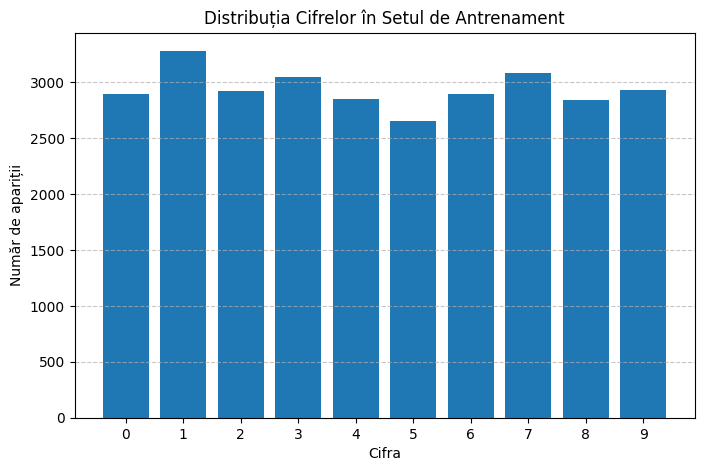

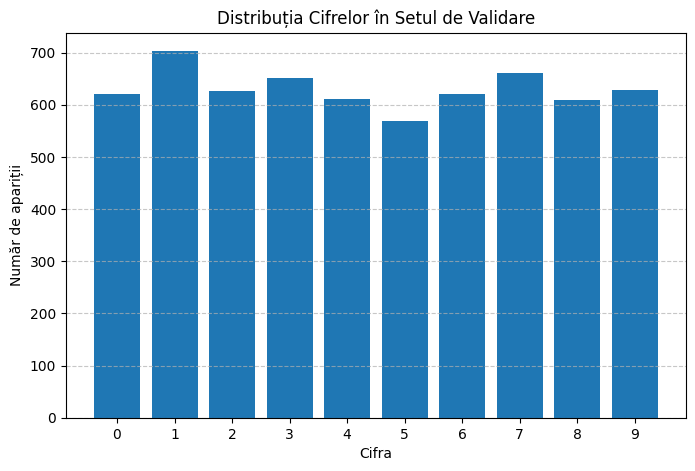

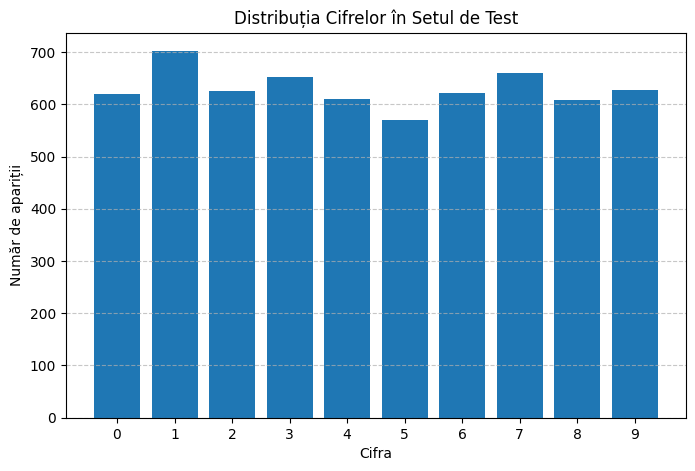

In [5]:
def plot_digit_distribution(labels, title):
    plt.figure(figsize=(8, 5))
    unique_digits, counts = np.unique(labels, return_counts=True)
    plt.bar(unique_digits, counts)
    plt.title(title)
    plt.xlabel('Cifra')
    plt.ylabel('Număr de apariții')
    plt.xticks(unique_digits)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

plot_digit_distribution(y_train_labels, 'Distribuția Cifrelor în Setul de Antrenament')
plot_digit_distribution(y_val_labels, 'Distribuția Cifrelor în Setul de Validare')
plot_digit_distribution(y_test_labels, 'Distribuția Cifrelor în Setul de Test')

In [6]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

In [7]:
def sigmoid_derivative(x):
    return sigmoid(x) * (1 - sigmoid(x))

In [8]:
def softmax(z):
    exp_z = np.exp(z - np.max( z, axis=1, keepdims=True))
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)
 

In [9]:
#keepdims pastreaza shape ul
#[
# [2,3,1,5],
# [1,7,4,2]
#]
#=>
#[
# [5],
# [7]
#]
#fara keepdims am avea [5,7] care nu are forma noastra

In [10]:
def softmax_deriv(z):
    return softmax(z) * (1 - softmax(z))


In [11]:
def cross_entropy(predicted, actual):
    m = actual.shape[0]  # nr samples
    #log(0)=inf => invatarea se blocheaza
    #=> clip ca sa avem un interval de numere 0.0001 and so on ca sa nu avem log de 0
    predicted = np.clip(predicted, 1e-10, 1 - 1e-10)
    log_likelihood = -np.log(predicted[range(m), actual])
    loss = np.sum(log_likelihood) / m
    return loss

In [12]:
class VanillaMLP:
    def __init__(self, input_size, hidden_size, output_size, learning_rate):
        np.random.seed(42) # seed ca sa putem repeta cu aceleasi valori
        self.learning_rate = learning_rate
        self.W1, self.b1, self.W2, self.b2 = self.initialize_weights(input_size, hidden_size, output_size)

    def initialize_weights(self, input_size, hidden_size,  output_size):
        W1 = np.random.randn(input_size, hidden_size) * np.sqrt(1 / input_size)
        b1 = np.zeros((1, hidden_size))
        W2 = np.random.randn(hidden_size, output_size) * np.sqrt(1 / hidden_size)
        b2 = np.zeros((1, output_size))
        return W1, b1, W2, b2

    def forward(self, X):
        Z1 = np.dot(X, self.W1) + self.b1 #Z1 = XW1+b1
        A1 = sigmoid(Z1)
        Z2 = np.dot(A1,self.W2) + self.b2
        A2 = softmax(Z2)
        cache = {
            "Z1": Z1,
            "A1": A1,
            "Z2": Z2,
            "A2": A2
        }
        return A2, cache

    def predict(self, X):
        A2, _ = self.forward(X)
        predictions = np.argmax(A2,axis=1)
        return predictions

    def evaluate(self, X, y):
        predictions = self.predict(X)
        accuracy = np.mean(predictions == y)
        return accuracy


    def backward(self, X, y_true, cache):
        m = X.shape[0]
        A1 = cache["A1"]
        A2 = cache["A2"]
        dZ2 = A2 - y_true
        dW2 = np.dot(A1.T, dZ2) / m
        db2 = np.sum(dZ2, axis=0, keepdims=True) / m
        dA1 = np.dot(dZ2, self.W2.T)
        dZ1 = (dA1 * sigmoid_derivative(cache["Z1"]))
        dW1 = np.dot(X.T, dZ1) / m
        db1 = np.sum(dZ1, axis=0, keepdims=True) / m
        gradients = {
            "dW1": dW1,
            "db1": db1,
            "dW2": dW2,
            "db2": db2
        }
        return gradients

    #batch gradient
    def update_parameters(self, gradients):
        self.W1 -= (self.learning_rate * gradients["dW1"])
        self.b1 -= (self.learning_rate * gradients["db1"])
        self.W2 -= (self.learning_rate * gradients["dW2"])
        self.b2 -= (self.learning_rate * gradients["db2"])

    def train(self, X, y, epochs):
        for epoch in range(epochs):
            A2, cache = self.forward(X)
            gradients = self.backward( X, y, cache)
            self.update_parameters(gradients)

    def train_with_history(self, X_train, y_train_one_hot, y_train_labels, X_val, y_val_one_hot, y_val_labels, X_test, y_test_one_hot, y_test_labels, epochs, patience=10, min_delta=0.0001):
        train_acc_history = []
        val_acc_history = []
        test_acc_history = []

        train_loss_history = []
        val_loss_history = []
        test_loss_history = []

        best_val_loss = float('inf')
        patience_counter = 0

        # Initial evaluation (Epoch 0)
        train_acc_0 = self.evaluate(X_train, y_train_labels)
        val_acc_0 = self.evaluate(X_val, y_val_labels)
        test_acc_0 = self.evaluate(X_test, y_test_labels)

        A2_train_0, _ = self.forward(X_train)
        A2_val_0, _ = self.forward(X_val)
        A2_test_0, _ = self.forward(X_test)

        train_loss_0 = cross_entropy(A2_train_0, y_train_labels)
        val_loss_0 = cross_entropy(A2_val_0, y_val_labels)
        test_loss_0 = cross_entropy(A2_test_0, y_test_labels)

        train_acc_history.append(train_acc_0)
        val_acc_history.append(val_acc_0)
        test_acc_history.append(test_acc_0)
        train_loss_history.append(train_loss_0)
        val_loss_history.append(val_loss_0)
        test_loss_history.append(test_loss_0)

        print(
            f"Initial (Epoch 0) Acc: {train_acc_0*100:.2f}% | "
            f"Val Acc: {val_acc_0*100:.2f}% | "
            f"Test Acc: {test_acc_0*100:.2f}% | "
            f"Train Loss: {train_loss_0:.4f} | "
            f"Val Loss: {val_loss_0:.4f} | "
            f"Test Loss: {test_loss_0:.4f}"
        )

        for epoch in range(epochs):
            print(f"\nEpoch {epoch+1}/{epochs}")
            self.train(X_train, y_train_one_hot, epochs=1)
            train_acc = self.evaluate(X_train, y_train_labels)
            val_acc = self.evaluate(X_val, y_val_labels)
            test_acc = self.evaluate(X_test, y_test_labels)

            A2_train, _ = self.forward(X_train)
            A2_val, _ = self.forward(X_val)
            A2_test, _ = self.forward(X_test)

            train_loss = cross_entropy(A2_train, y_train_labels)
            val_loss = cross_entropy(A2_val, y_val_labels)
            test_loss = cross_entropy(A2_test, y_test_labels)

            train_acc_history.append(train_acc)
            val_acc_history.append(val_acc)
            test_acc_history.append(test_acc)

            train_loss_history.append(train_loss)
            val_loss_history.append(val_loss)
            test_loss_history.append(test_loss)

            print(
                f"Train Acc: {train_acc*100:.2f}% | "
                f"Val Acc: {val_acc*100:.2f}% | "
                f"Test Acc: {test_acc*100:.2f}% | "
                f"Train Loss: {train_loss:.4f} | "
                f"Val Loss: {val_loss:.4f} | "
                f"Test Loss: {test_loss:.4f}"
            )

            # Early stopping check
            if val_loss < best_val_loss - min_delta:
                best_val_loss = val_loss
                patience_counter = 0
            else:
                patience_counter += 1
                if patience_counter >= patience:
                    print(f"Early stopping at epoch {epoch+1} as validation loss did not improve for {patience} epochs.")
                    break # Break the epoch loop

        return (train_acc_history, val_acc_history, test_acc_history, train_loss_history, val_loss_history, test_loss_history)

In [13]:
mlp = VanillaMLP(input_size=784, hidden_size=100, output_size=10, learning_rate=0.5)

train_acc_history,\
val_acc_history,\
test_acc_history,\
train_loss_history,\
val_loss_history,\
test_loss_history = mlp.train_with_history(x_train, y_train_one_hot, y_train_labels, x_val, y_val_one_hot, y_val_labels, x_test, y_test_one_hot, y_test_labels, epochs=200, patience=10, min_delta=0.0001)

Initial (Epoch 0) Acc: 9.98% | Val Acc: 9.97% | Test Acc: 9.97% | Train Loss: 2.4041 | Val Loss: 2.4042 | Test Loss: 2.4033

Epoch 1/200
Train Acc: 17.55% | Val Acc: 17.75% | Test Acc: 17.13% | Train Loss: 2.2951 | Val Loss: 2.2951 | Test Loss: 2.2946

Epoch 2/200
Train Acc: 32.20% | Val Acc: 31.86% | Test Acc: 32.11% | Train Loss: 2.2373 | Val Loss: 2.2371 | Test Loss: 2.2368

Epoch 3/200
Train Acc: 39.62% | Val Acc: 39.44% | Test Acc: 39.22% | Train Loss: 2.1996 | Val Loss: 2.1994 | Test Loss: 2.1992

Epoch 4/200
Train Acc: 49.45% | Val Acc: 49.40% | Test Acc: 49.08% | Train Loss: 2.1629 | Val Loss: 2.1626 | Test Loss: 2.1626

Epoch 5/200
Train Acc: 53.30% | Val Acc: 52.97% | Test Acc: 52.79% | Train Loss: 2.1264 | Val Loss: 2.1261 | Test Loss: 2.1262

Epoch 6/200
Train Acc: 56.69% | Val Acc: 56.67% | Test Acc: 56.51% | Train Loss: 2.0898 | Val Loss: 2.0894 | Test Loss: 2.0897

Epoch 7/200
Train Acc: 59.18% | Val Acc: 59.37% | Test Acc: 59.14% | Train Loss: 2.0529 | Val Loss: 2.0524 

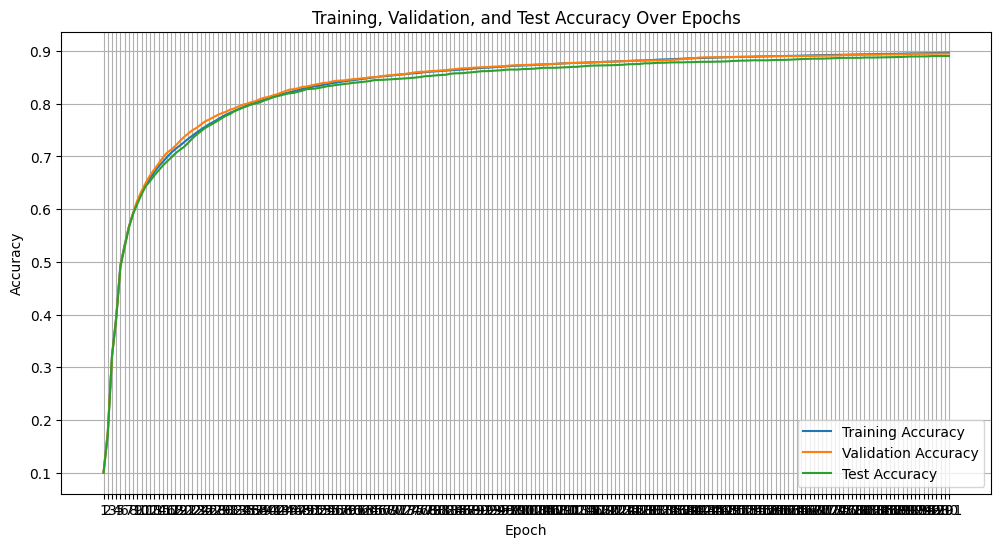

In [14]:
epochs_range = range(1, len(train_acc_history) + 1)

plt.figure(figsize=(12, 6))
plt.plot(epochs_range, train_acc_history, label='Training Accuracy')
plt.plot(epochs_range, val_acc_history, label='Validation Accuracy')
plt.plot(epochs_range, test_acc_history, label='Test Accuracy')
plt.title('Training, Validation, and Test Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.xticks(np.arange(min(epochs_range), max(epochs_range) + 1, 1))
plt.show()


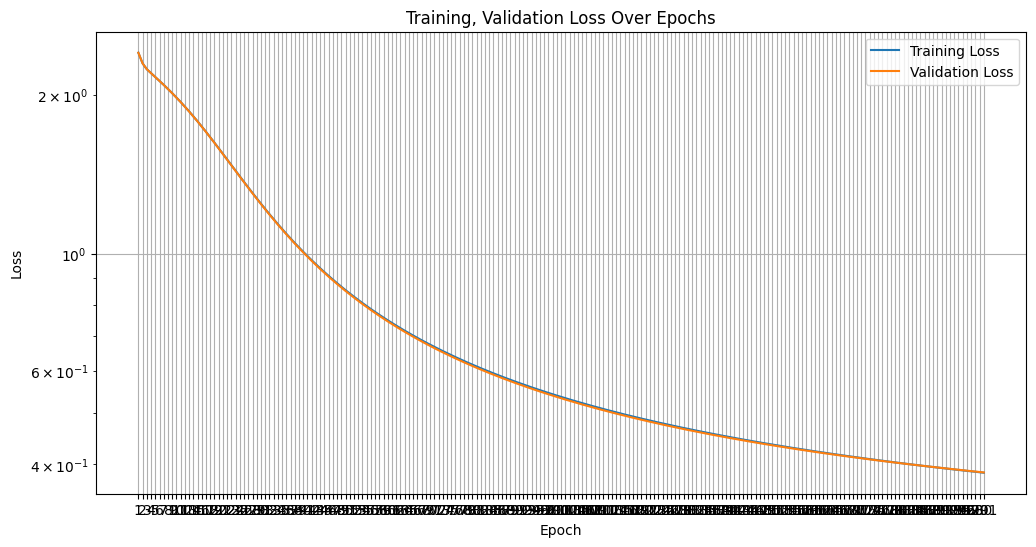

In [15]:
plt.figure(figsize=(12, 6))
plt.plot(epochs_range, train_loss_history, label='Training Loss')
plt.plot(epochs_range, val_loss_history, label='Validation Loss')
plt.title('Training, Validation Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.yscale('log')
plt.xticks(np.arange(min(epochs_range), max(epochs_range) + 1, 1))
plt.show()


In [16]:
class MiniBatchVanillaMLP(VanillaMLP):
    def __init__(self, input_size, hidden_size, output_size, learning_rate, batch_size):
        super().__init__(input_size, hidden_size, output_size, learning_rate)
        self.batch_size = batch_size

    def train(self, X, y):
        m = X.shape[0]
        num_batches = m // self.batch_size
        indices = np.arange(m)
        np.random.shuffle(indices)

        for i in range(num_batches):
            start_idx = i * self.batch_size
            end_idx = start_idx + self.batch_size

            batch_X = X[indices[start_idx:end_idx]]
            batch_y = y[indices[start_idx:end_idx]]

            A2, cache = self.forward(batch_X)
            gradients = self.backward(batch_X, batch_y, cache)
            self.update_parameters(gradients)

    def train_with_history(self, X_train, y_train_one_hot, y_train_labels, X_val, y_val_one_hot, y_val_labels, X_test, y_test_one_hot, y_test_labels, epochs, patience=10, min_delta=0.0001):
        train_acc_history = []
        val_acc_history = []
        test_acc_history = []

        train_loss_history = []
        val_loss_history = []
        test_loss_history = []

        best_val_loss = float('inf')
        patience_counter = 0

        train_acc_0 = self.evaluate(X_train, y_train_labels)
        val_acc_0 = self.evaluate(X_val, y_val_labels)
        test_acc_0 = self.evaluate(X_test, y_test_labels)

        A2_train_0, _ = self.forward(X_train)
        A2_val_0, _ = self.forward(X_val)
        A2_test_0, _ = self.forward(X_test)

        train_loss_0 = cross_entropy(A2_train_0, y_train_labels)
        val_loss_0 = cross_entropy(A2_val_0, y_val_labels)
        test_loss_0 = cross_entropy(A2_test_0, y_test_labels)

        train_acc_history.append(train_acc_0)
        val_acc_history.append(val_acc_0)
        test_acc_history.append(test_acc_0)
        train_loss_history.append(train_loss_0)
        val_loss_history.append(val_loss_0)
        test_loss_history.append(test_loss_0)

        print(
            f"Initial (Epoch 0) Acc: {train_acc_0*100:.2f}% | "
            f"Val Acc: {val_acc_0*100:.2f}% | "
            f"Test Acc: {test_acc_0*100:.2f}% | "
            f"Train Loss: {train_loss_0:.4f} | "
            f"Val Loss: {val_loss_0:.4f} | "
            f"Test Loss: {test_loss_0:.4f}"
        )

        for epoch in range(epochs):
            print(f"\nEpoch {epoch+1}/{epochs}")
            self.train(X_train, y_train_one_hot)

            train_acc = self.evaluate(X_train, y_train_labels)
            val_acc = self.evaluate(X_val, y_val_labels)
            test_acc = self.evaluate(X_test, y_test_labels)

            A2_train, _ = self.forward(X_train)
            A2_val, _ = self.forward(X_val)
            A2_test, _ = self.forward(X_test)

            train_loss = cross_entropy(A2_train, y_train_labels)
            val_loss = cross_entropy(A2_val, y_val_labels)
            test_loss = cross_entropy(A2_test, y_test_labels)

            train_acc_history.append(train_acc)
            val_acc_history.append(val_acc)
            test_acc_history.append(test_acc)

            train_loss_history.append(train_loss)
            val_loss_history.append(val_loss)
            test_loss_history.append(test_loss)

            print(
                f"Train Acc: {train_acc*100:.2f}% | "
                f"Val Acc: {val_acc*100:.2f}% | "
                f"Test Acc: {test_acc*100:.2f}% | "
                f"Train Loss: {train_loss:.4f} | "
                f"Val Loss: {val_loss:.4f} | "
                f"Test Loss: {test_loss:.4f}"
            )

            if val_loss < best_val_loss - min_delta:
                best_val_loss = val_loss
                patience_counter = 0
            else:
                patience_counter += 1
                if patience_counter >= patience:
                    print(f"Early stopping at epoch {epoch+1} as validation loss did not improve for {patience} epochs.")
                    break 

        return (train_acc_history, val_acc_history, test_acc_history, train_loss_history, val_loss_history, test_loss_history)

In [17]:
minibatch_mlp = MiniBatchVanillaMLP(input_size=784, hidden_size=100, output_size=10, learning_rate=0.5, batch_size = 64)


minibatch_train_acc_history, \
minibatch_val_acc_history, \
minibatch_test_acc_history, \
minibatch_train_loss_history, \
minibatch_val_loss_history, \
minibatch_test_loss_history = minibatch_mlp.train_with_history(
    x_train, y_train_one_hot, y_train_labels,
    x_val, y_val_one_hot, y_val_labels,
    x_test, y_test_one_hot, y_test_labels,
    epochs=20, patience=10, min_delta=0.0001
)

Initial (Epoch 0) Acc: 9.98% | Val Acc: 9.97% | Test Acc: 9.97% | Train Loss: 2.4041 | Val Loss: 2.4042 | Test Loss: 2.4033

Epoch 1/20
Train Acc: 91.03% | Val Acc: 90.65% | Test Acc: 90.27% | Train Loss: 0.3074 | Val Loss: 0.3166 | Test Loss: 0.3359

Epoch 2/20
Train Acc: 92.87% | Val Acc: 92.29% | Test Acc: 92.24% | Train Loss: 0.2408 | Val Loss: 0.2614 | Test Loss: 0.2734

Epoch 3/20
Train Acc: 94.33% | Val Acc: 93.62% | Test Acc: 93.16% | Train Loss: 0.1969 | Val Loss: 0.2219 | Test Loss: 0.2363

Epoch 4/20
Train Acc: 94.92% | Val Acc: 94.02% | Test Acc: 93.70% | Train Loss: 0.1739 | Val Loss: 0.2046 | Test Loss: 0.2165

Epoch 5/20
Train Acc: 95.66% | Val Acc: 94.54% | Test Acc: 94.25% | Train Loss: 0.1499 | Val Loss: 0.1865 | Test Loss: 0.1976

Epoch 6/20
Train Acc: 96.21% | Val Acc: 94.83% | Test Acc: 94.54% | Train Loss: 0.1346 | Val Loss: 0.1721 | Test Loss: 0.1855

Epoch 7/20
Train Acc: 96.58% | Val Acc: 95.22% | Test Acc: 94.92% | Train Loss: 0.1179 | Val Loss: 0.1610 | Test 

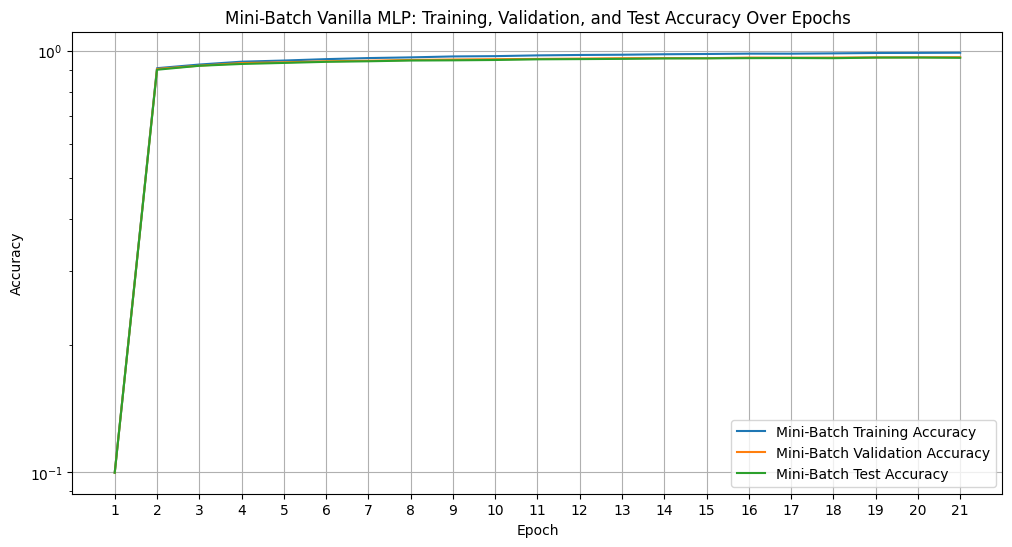

In [18]:
epochs_range_minibatch = range(1, len(minibatch_train_acc_history) + 1)

plt.figure(figsize=(12, 6))
plt.plot(epochs_range_minibatch, minibatch_train_acc_history, label='Mini-Batch Training Accuracy')
plt.plot(epochs_range_minibatch, minibatch_val_acc_history, label='Mini-Batch Validation Accuracy')
plt.plot(epochs_range_minibatch, minibatch_test_acc_history, label='Mini-Batch Test Accuracy')
plt.title('Mini-Batch Vanilla MLP: Training, Validation, and Test Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.yscale('log')
plt.xticks(np.arange(min(epochs_range_minibatch), max(epochs_range_minibatch) + 1, 1))
plt.show()

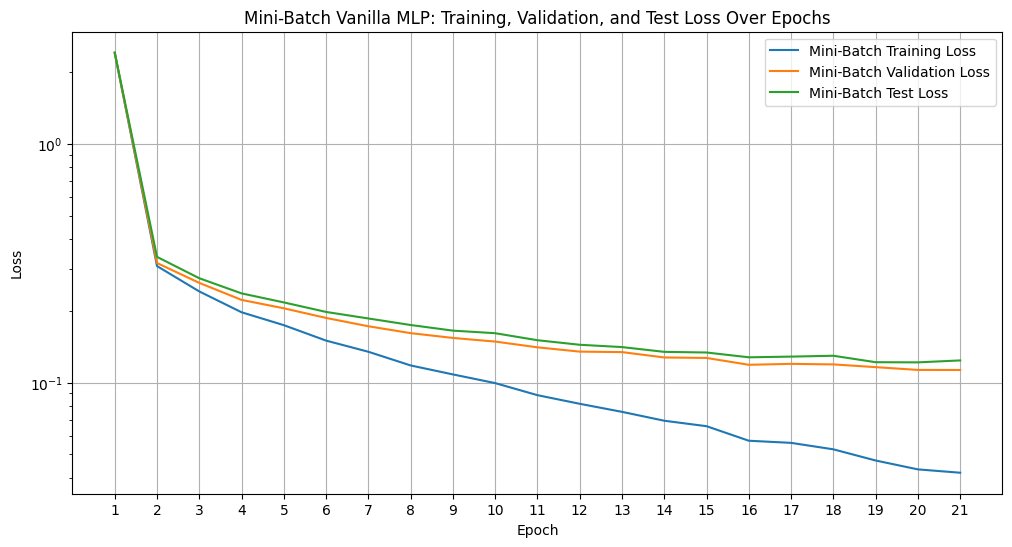

In [19]:
plt.figure(figsize=(12, 6))
plt.plot(epochs_range_minibatch, minibatch_train_loss_history, label='Mini-Batch Training Loss')
plt.plot(epochs_range_minibatch, minibatch_val_loss_history, label='Mini-Batch Validation Loss')
plt.plot(epochs_range_minibatch, minibatch_test_loss_history, label='Mini-Batch Test Loss')
plt.title('Mini-Batch Vanilla MLP: Training, Validation, and Test Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.yscale('log')
plt.xticks(np.arange(min(epochs_range_minibatch), max(epochs_range_minibatch) + 1, 1))
plt.show()

In [20]:
class GridSearch:
    def __init__(self, model_class, param_grid):
        self.model_class = model_class
        self.param_grid = param_grid
        self.results = []
        self.best_model_instance = None
        self.best_params = None
        self.best_val_acc = -1.0

    def run(self, X_train, y_train_one_hot, y_train_labels, X_val, y_val_one_hot, y_val_labels, X_test, y_test_one_hot, y_test_labels):
        keys = self.param_grid.keys()
        values = self.param_grid.values()

        for params_tuple in itertools.product(*values):
            params = dict(zip(keys, params_tuple))
            print(f"--- Training {self.model_class.__name__} with params: {params} ---")

            model_init_args = {
                'input_size': X_train.shape[1],
                'hidden_size': 100,
                'output_size': 10,
                'learning_rate': params['learning_rate']
            }
            if 'batch_size' in params:
                model_init_args['batch_size'] = params['batch_size']
            if 'l2_lambda' in params:
                model_init_args['l2_lambda'] = params['l2_lambda']

            model = self.model_class(**model_init_args)

            epochs = params.get('epochs', 100)
            patience = params.get('patience', 10)
            min_delta = params.get('min_delta', 0.0001)

            train_acc_hist, val_acc_hist, test_acc_hist, train_loss_hist, val_loss_hist, test_loss_hist = \
                model.train_with_history(X_train, y_train_one_hot, y_train_labels,
                                         X_val, y_val_one_hot, y_val_labels,
                                         X_test, y_test_one_hot, y_test_labels,
                                         epochs=epochs, patience=patience, min_delta=min_delta)

            final_val_acc = val_acc_hist[-1]

            self.results.append({
                'params': params,
                'train_acc_hist': train_acc_hist,
                'val_acc_hist': val_acc_hist,
                'test_acc_hist': test_acc_hist,
                'train_loss_hist': train_loss_hist,
                'val_loss_hist': val_loss_hist,
                'test_loss_hist': test_loss_hist
            })

            if final_val_acc > self.best_val_acc:
                self.best_val_acc = final_val_acc
                self.best_params = params
                self.best_model_instance = model# keep the actual model instance

        print(f"--- Best parameters for {self.model_class.__name__}: {self.best_params} with Validation Accuracy: {self.best_val_acc*100:.2f}% ---")


    def plot_results(self, title_prefix=""):
        # accuracy
        plt.figure(figsize=(15, 8))
        max_epochs_across_runs = 0
        for result in self.results:
            label = ', '.join(f"{k}={v}" for k, v in result['params'].items())
            epochs_range = range(1, len(result['val_acc_hist']) + 1)
            plt.plot(epochs_range, result['train_acc_hist'], label=f"Train Acc: {label}")
            plt.plot(epochs_range, result['val_acc_hist'], label=f"Val Acc: {label}")
            plt.plot(epochs_range, result['test_acc_hist'], label=f"Test Acc: {label}")
            max_epochs_across_runs = max(max_epochs_across_runs, max(epochs_range))

        plt.title(f"{title_prefix} Accuracy")
        plt.xlabel('Epoch')
        plt.ylabel('Accuracy')
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.grid(True)
        if max_epochs_across_runs > 0: # Ensure there are epochs to plot
            plt.xticks(np.arange(1, max_epochs_across_runs + 1, 1))
        plt.tight_layout()
        plt.show()

        # loss
        plt.figure(figsize=(15, 8))
        max_epochs_across_runs = 0
        for result in self.results:
            label = ', '.join(f"{k}={v}" for k, v in result['params'].items())
            epochs_range = range(1, len(result['val_loss_hist']) + 1)
            plt.plot(epochs_range, result['train_loss_hist'], label=f"Train Loss: {label}")
            plt.plot(epochs_range, result['val_loss_hist'], label=f"Val Loss: {label}")
            plt.plot(epochs_range, result['test_loss_hist'], label=f"Test Loss: {label}")
            max_epochs_across_runs = max(max_epochs_across_runs, max(epochs_range))

        plt.title(f"{title_prefix} Loss")
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.grid(True)
        if max_epochs_across_runs > 0: 
            plt.xticks(np.arange(1, max_epochs_across_runs + 1, 1))
        plt.tight_layout()
        plt.show()

In [21]:
vanilla_param_grid = {
    'learning_rate': [1.0, 1.5],
    'epochs': [50, 100],
    'patience': [10],
    'min_delta': [0.001]
}

vanilla_grid_search = GridSearch(model_class=VanillaMLP, param_grid=vanilla_param_grid)
vanilla_grid_search.run(x_train, y_train_one_hot, y_train_labels, x_val, y_val_one_hot, y_val_labels, x_test, y_test_one_hot, y_test_labels)

--- Training VanillaMLP with params: {'learning_rate': 1.0, 'epochs': 50, 'patience': 10, 'min_delta': 0.001} ---
Initial (Epoch 0) Acc: 9.98% | Val Acc: 9.97% | Test Acc: 9.97% | Train Loss: 2.4041 | Val Loss: 2.4042 | Test Loss: 2.4033

Epoch 1/50
Train Acc: 11.15% | Val Acc: 11.16% | Test Acc: 11.14% | Train Loss: 2.4953 | Val Loss: 2.4952 | Test Loss: 2.4951

Epoch 2/50
Train Acc: 17.37% | Val Acc: 17.43% | Test Acc: 17.29% | Train Loss: 2.4861 | Val Loss: 2.4860 | Test Loss: 2.4853

Epoch 3/50
Train Acc: 30.70% | Val Acc: 31.22% | Test Acc: 31.11% | Train Loss: 2.3618 | Val Loss: 2.3613 | Test Loss: 2.3616

Epoch 4/50
Train Acc: 29.94% | Val Acc: 30.65% | Test Acc: 30.44% | Train Loss: 2.1412 | Val Loss: 2.1407 | Test Loss: 2.1415

Epoch 5/50
Train Acc: 41.82% | Val Acc: 41.79% | Test Acc: 41.40% | Train Loss: 2.0704 | Val Loss: 2.0697 | Test Loss: 2.0706

Epoch 6/50
Train Acc: 45.80% | Val Acc: 45.95% | Test Acc: 46.05% | Train Loss: 1.9508 | Val Loss: 1.9497 | Test Loss: 1.9513


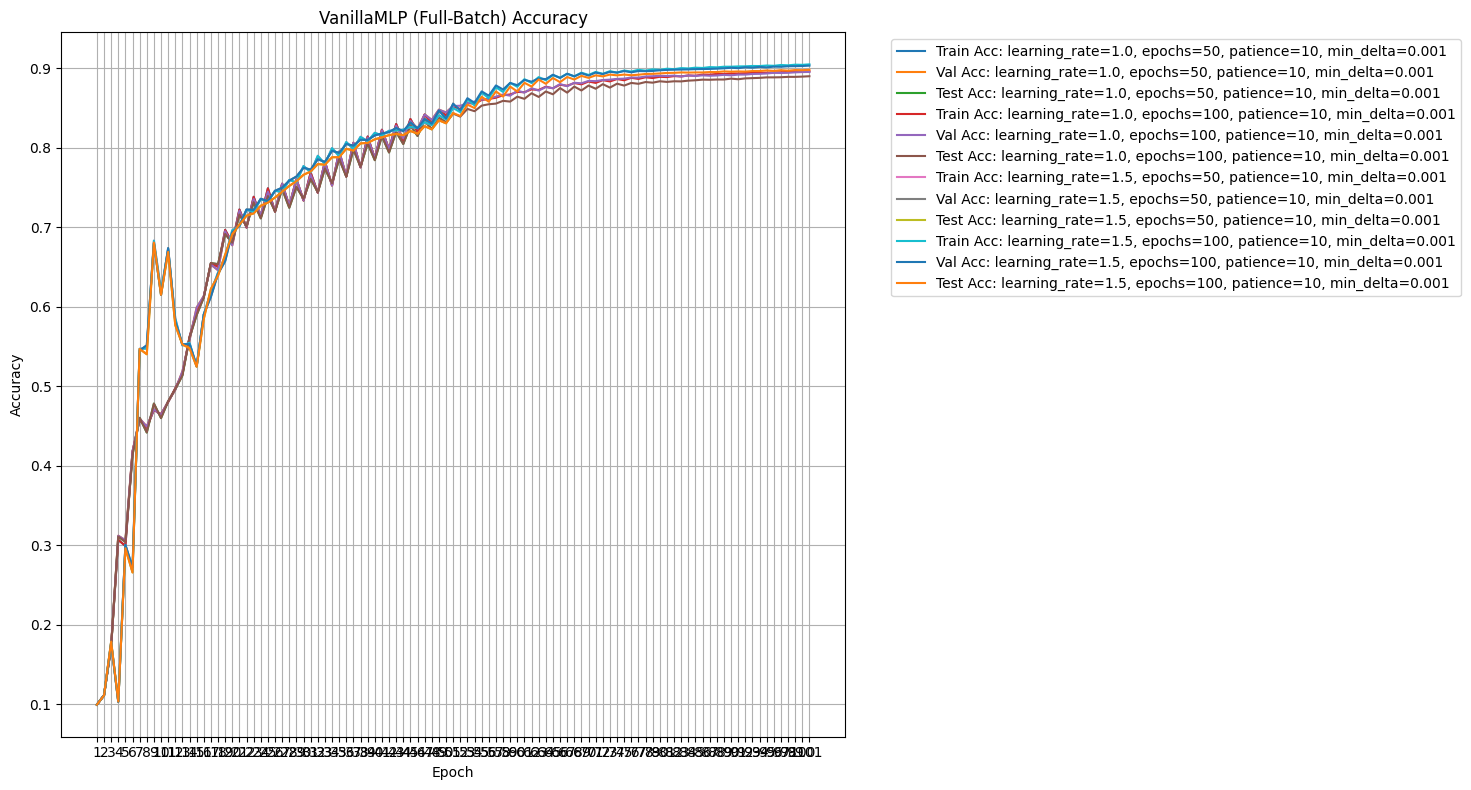

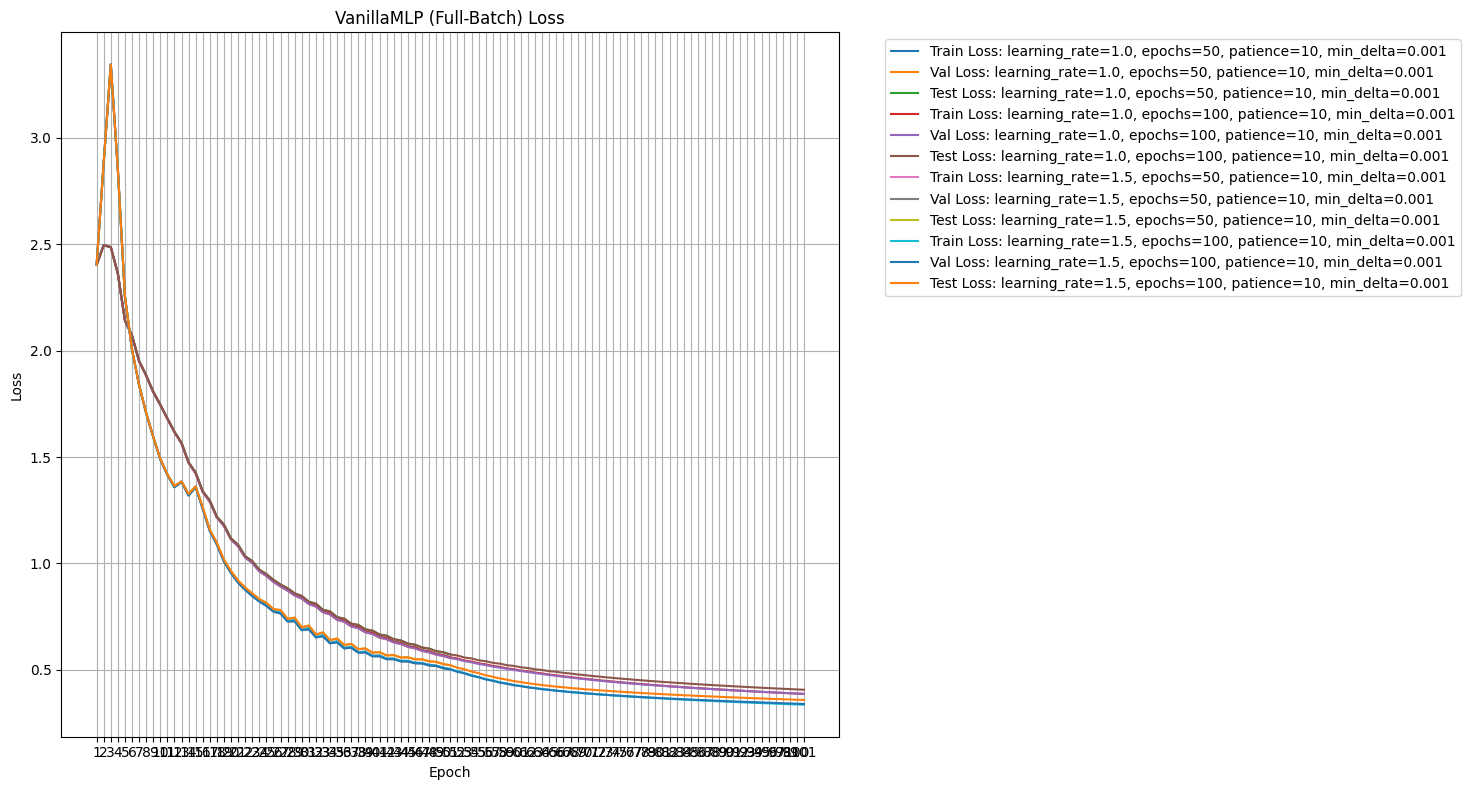

In [22]:
vanilla_grid_search.plot_results(title_prefix="VanillaMLP (Full-Batch)")

In [23]:
minibatch_param_grid = {
    'learning_rate': [0.05, 0.1],
    'batch_size': [64, 128],
    'epochs': [20, 30],
    'patience': [5],
    'min_delta': [0.01]
}

minibatch_grid_search = GridSearch(model_class=MiniBatchVanillaMLP, param_grid=minibatch_param_grid)
minibatch_grid_search.run(x_train, y_train_one_hot, y_train_labels, x_val, y_val_one_hot, y_val_labels, x_test, y_test_one_hot, y_test_labels)

--- Training MiniBatchVanillaMLP with params: {'learning_rate': 0.05, 'batch_size': 64, 'epochs': 20, 'patience': 5, 'min_delta': 0.01} ---
Initial (Epoch 0) Acc: 9.98% | Val Acc: 9.97% | Test Acc: 9.97% | Train Loss: 2.4041 | Val Loss: 2.4042 | Test Loss: 2.4033

Epoch 1/20
Train Acc: 81.86% | Val Acc: 82.03% | Test Acc: 81.38% | Train Loss: 0.8976 | Val Loss: 0.8949 | Test Loss: 0.9038

Epoch 2/20
Train Acc: 87.01% | Val Acc: 87.29% | Test Acc: 86.57% | Train Loss: 0.5660 | Val Loss: 0.5626 | Test Loss: 0.5786

Epoch 3/20
Train Acc: 88.45% | Val Acc: 88.65% | Test Acc: 87.83% | Train Loss: 0.4551 | Val Loss: 0.4535 | Test Loss: 0.4721

Epoch 4/20
Train Acc: 89.45% | Val Acc: 89.43% | Test Acc: 88.86% | Train Loss: 0.4003 | Val Loss: 0.4001 | Test Loss: 0.4196

Epoch 5/20
Train Acc: 90.04% | Val Acc: 89.89% | Test Acc: 89.40% | Train Loss: 0.3663 | Val Loss: 0.3678 | Test Loss: 0.3875

Epoch 6/20
Train Acc: 90.43% | Val Acc: 90.27% | Test Acc: 89.81% | Train Loss: 0.3446 | Val Loss: 0

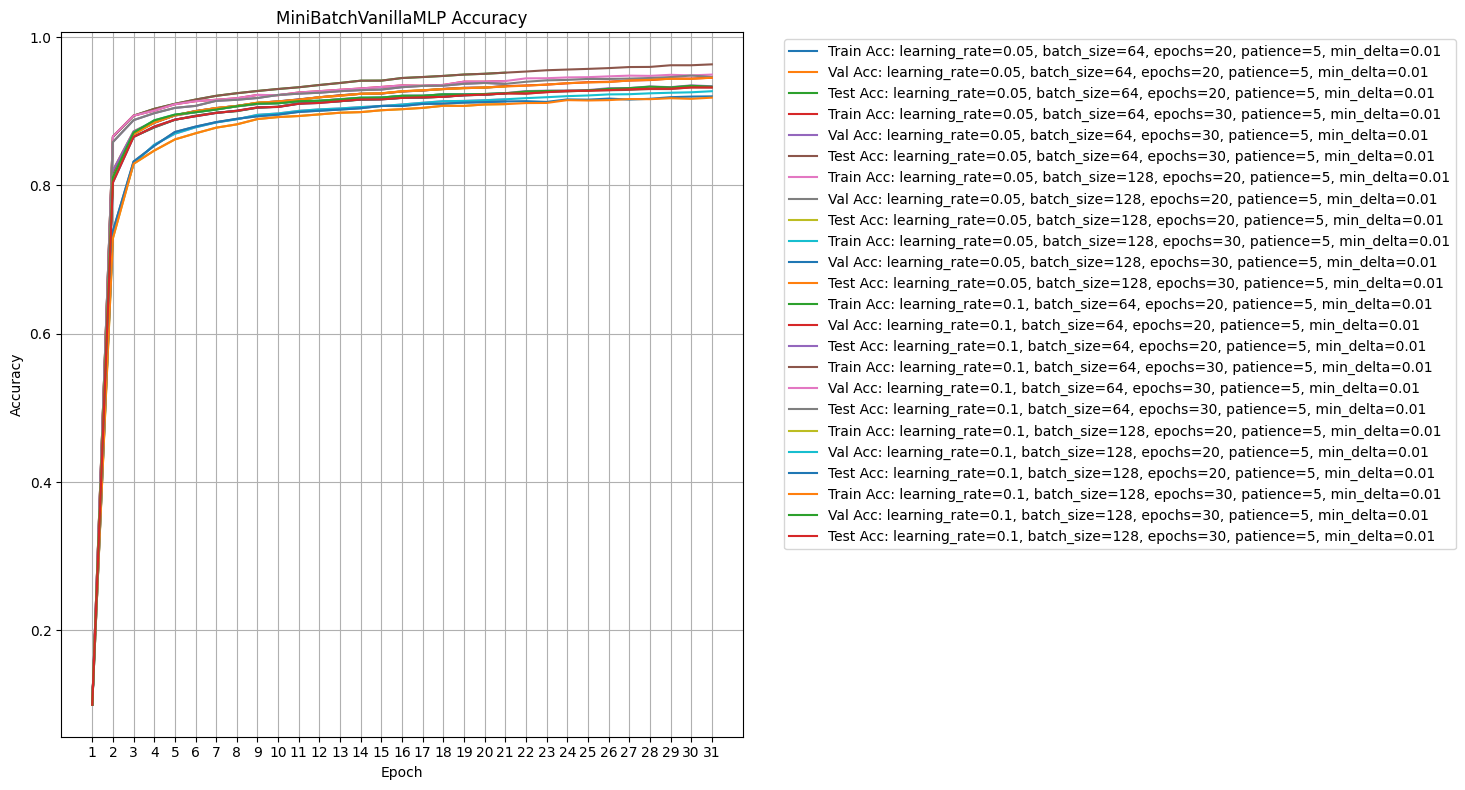

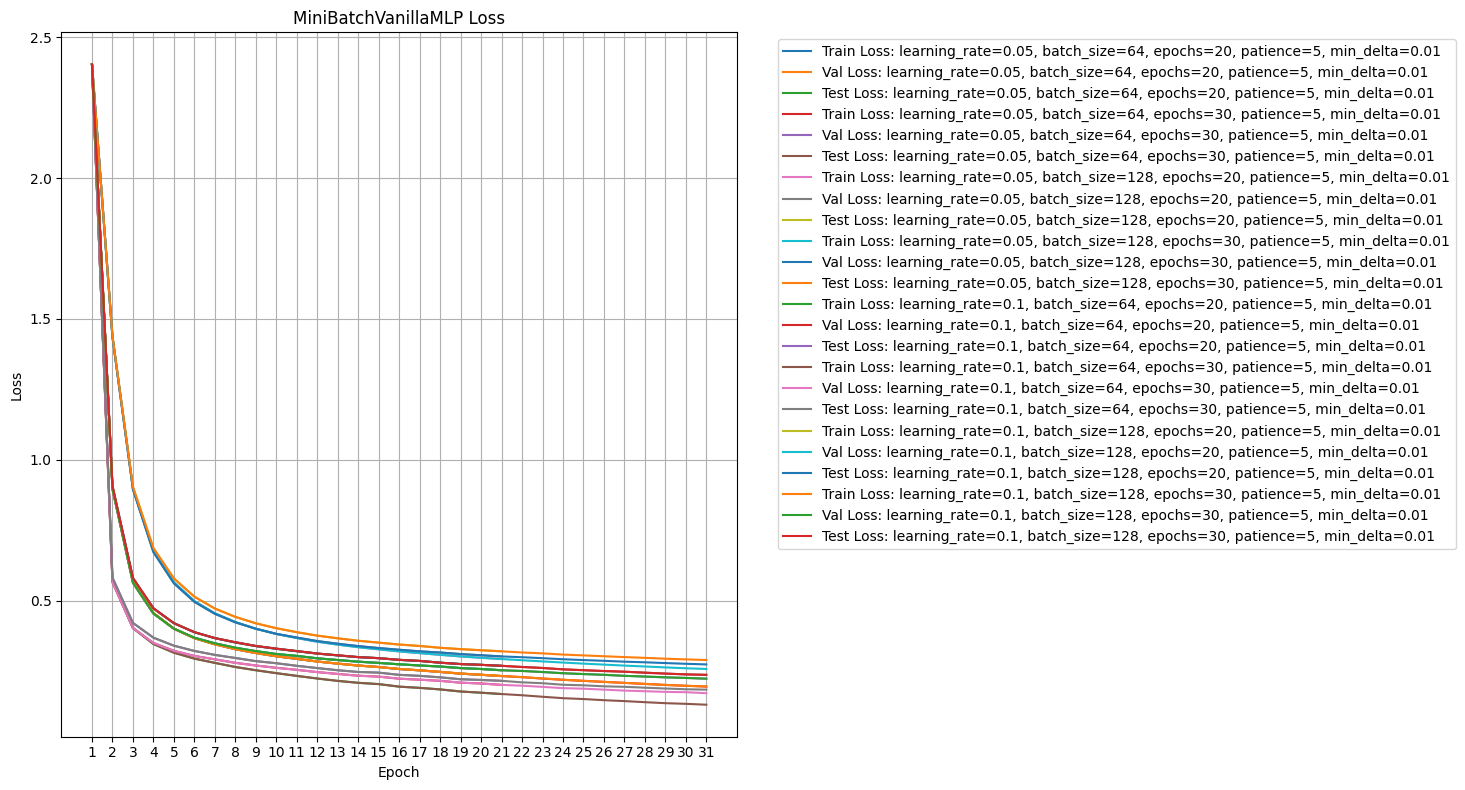

In [24]:
minibatch_grid_search.plot_results(title_prefix="MiniBatchVanillaMLP")

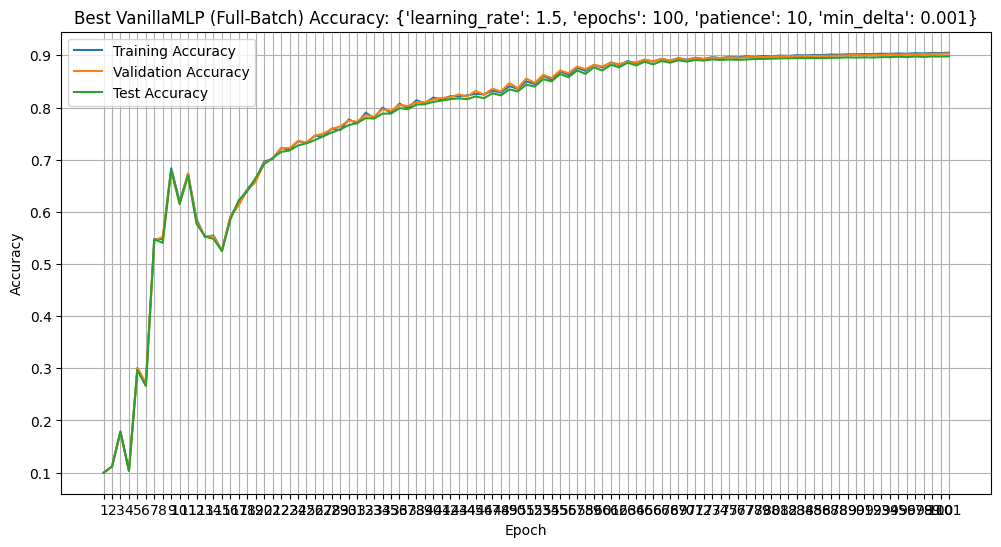

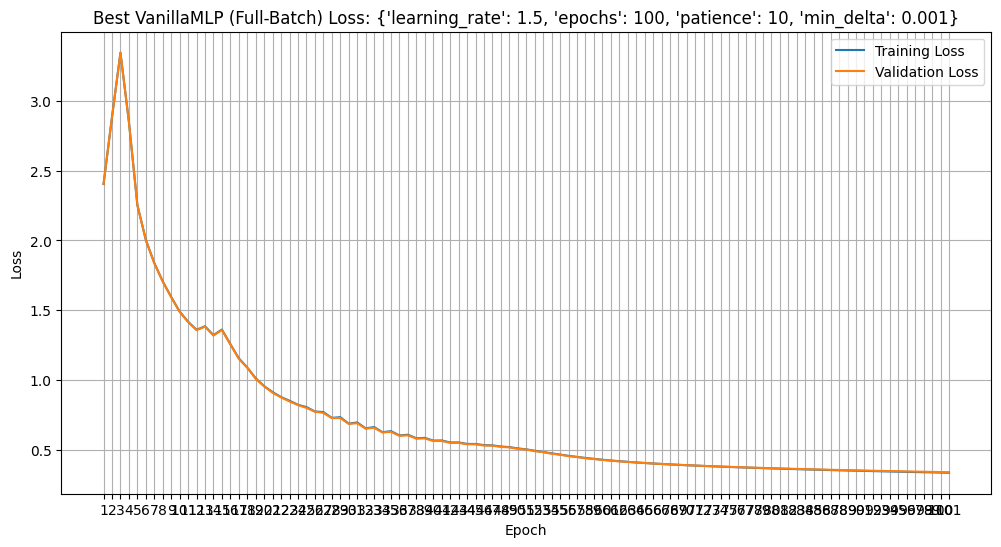

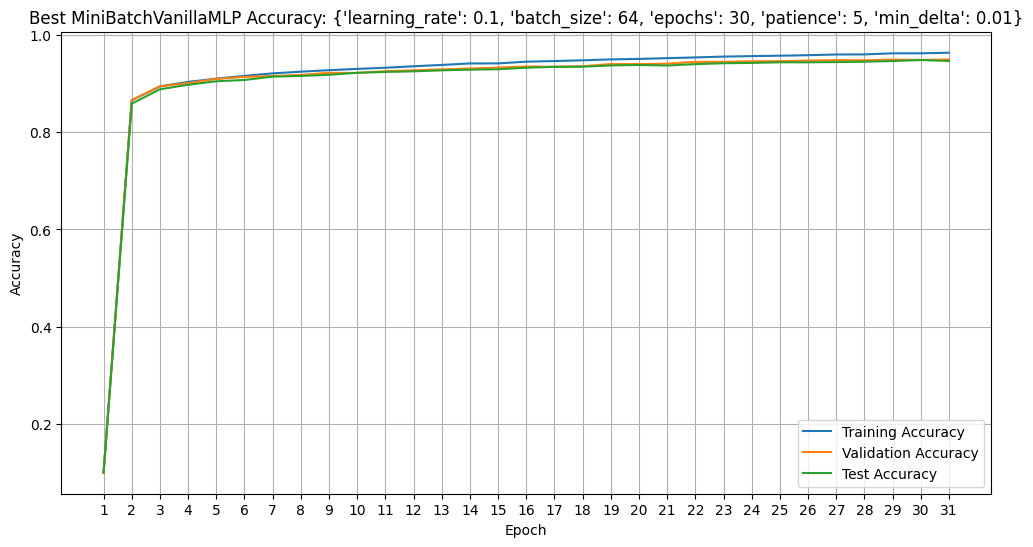

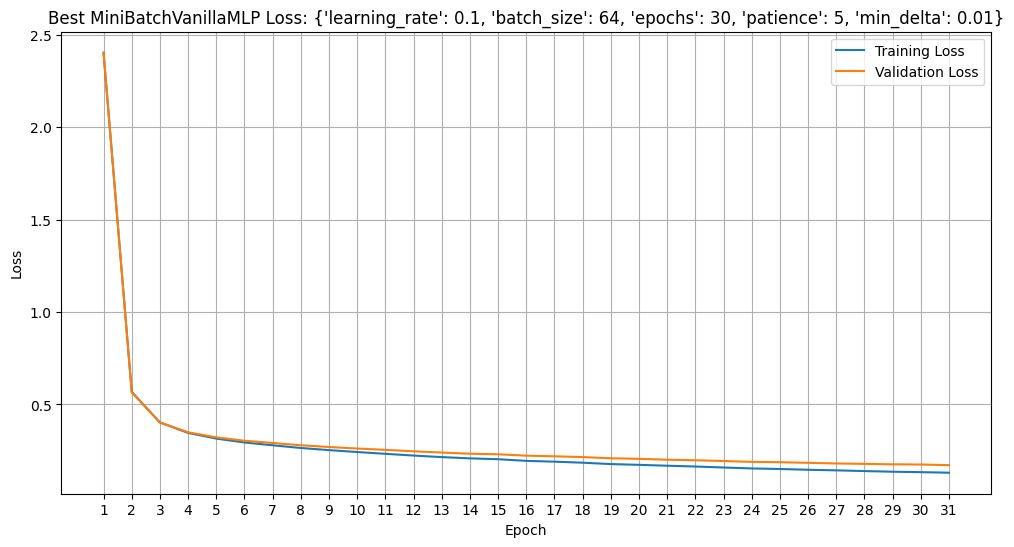

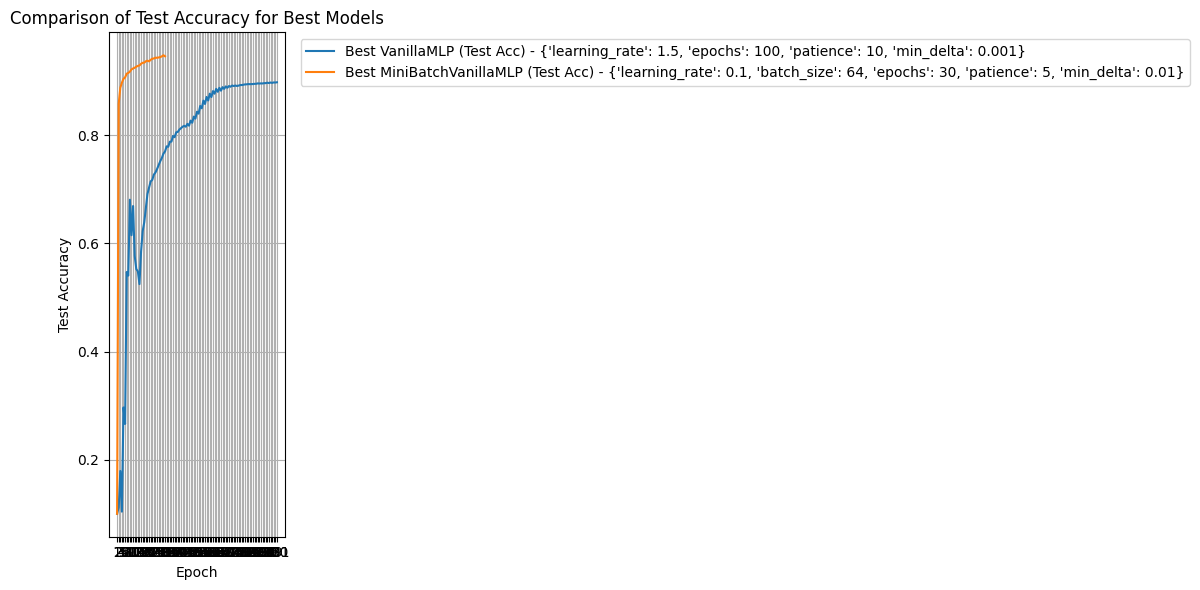

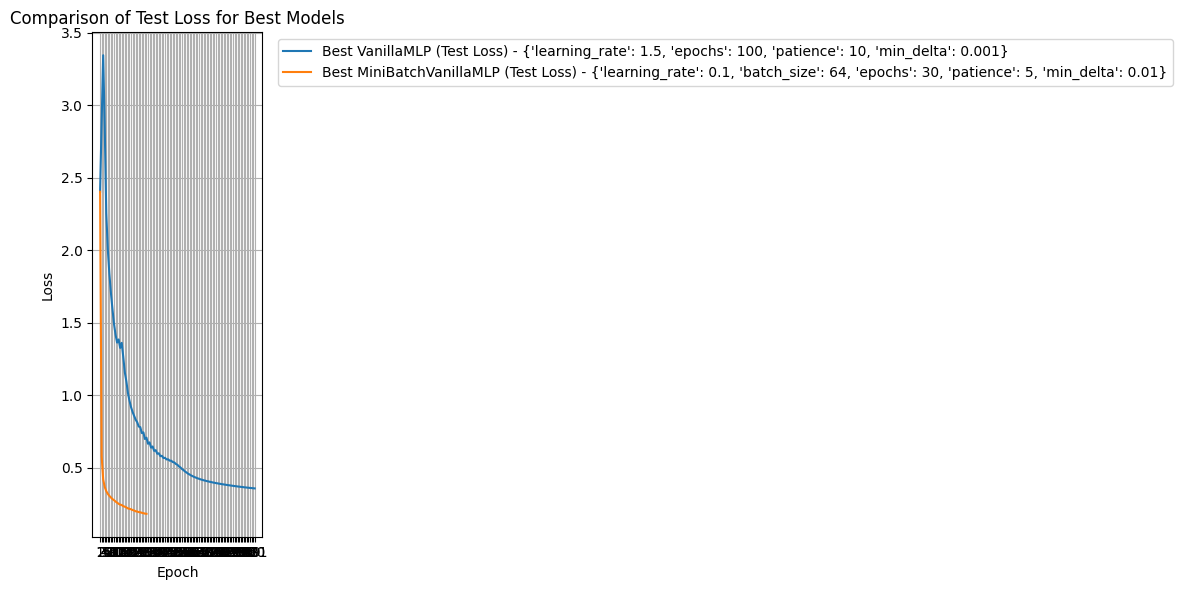

In [25]:
best_vanilla_results = None
for result in vanilla_grid_search.results:
    if result['params'] == vanilla_grid_search.best_params:
        best_vanilla_results = result
        break

best_minibatch_results = None
for result in minibatch_grid_search.results:
    if result['params'] == minibatch_grid_search.best_params:
        best_minibatch_results = result
        break

epochs_range_vanilla = range(1, len(best_vanilla_results['train_acc_hist']) + 1)
plt.figure(figsize=(12, 6))
plt.plot(epochs_range_vanilla, best_vanilla_results['train_acc_hist'], label='Training Accuracy')
plt.plot(epochs_range_vanilla, best_vanilla_results['val_acc_hist'], label='Validation Accuracy')
plt.plot(epochs_range_vanilla, best_vanilla_results['test_acc_hist'], label='Test Accuracy')
plt.title(f"Best VanillaMLP (Full-Batch) Accuracy: {best_vanilla_results['params']}")
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.xticks(np.arange(min(epochs_range_vanilla), max(epochs_range_vanilla) + 1, 1))
plt.show()


plt.figure(figsize=(12, 6))
plt.plot(epochs_range_vanilla, best_vanilla_results['train_loss_hist'], label='Training Loss')
plt.plot(epochs_range_vanilla, best_vanilla_results['val_loss_hist'], label='Validation Loss')
plt.title(f"Best VanillaMLP (Full-Batch) Loss: {best_vanilla_results['params']}")
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.xticks(np.arange(min(epochs_range_vanilla), max(epochs_range_vanilla) + 1, 1))
plt.show()

epochs_range_minibatch = range(1, len(best_minibatch_results['train_acc_hist']) + 1)
plt.figure(figsize=(12, 6))
plt.plot(epochs_range_minibatch, best_minibatch_results['train_acc_hist'], label='Training Accuracy')
plt.plot(epochs_range_minibatch, best_minibatch_results['val_acc_hist'], label='Validation Accuracy')
plt.plot(epochs_range_minibatch, best_minibatch_results['test_acc_hist'], label='Test Accuracy')
plt.title(f"Best MiniBatchVanillaMLP Accuracy: {best_minibatch_results['params']}")
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.xticks(np.arange(min(epochs_range_minibatch), max(epochs_range_minibatch) + 1, 1))
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(epochs_range_minibatch, best_minibatch_results['train_loss_hist'], label='Training Loss')
plt.plot(epochs_range_minibatch, best_minibatch_results['val_loss_hist'], label='Validation Loss')
plt.title(f"Best MiniBatchVanillaMLP Loss: {best_minibatch_results['params']}")
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.xticks(np.arange(min(epochs_range_minibatch), max(epochs_range_minibatch) + 1, 1))
plt.show()


plt.figure(figsize=(12, 6))
epochs_range_vanilla = range(1, len(best_vanilla_results['test_acc_hist']) + 1)
plt.plot(epochs_range_vanilla, best_vanilla_results['test_acc_hist'], label=f"Best VanillaMLP (Test Acc) - {best_vanilla_results['params']}")
epochs_range_minibatch = range(1, len(best_minibatch_results['test_acc_hist']) + 1)
plt.plot(epochs_range_minibatch, best_minibatch_results['test_acc_hist'], label=f"Best MiniBatchVanillaMLP (Test Acc) - {best_minibatch_results['params']}")
plt.title('Comparison of Test Accuracy for Best Models')
plt.xlabel('Epoch')
plt.ylabel('Test Accuracy')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
max_comp_epochs_acc = max(max(epochs_range_vanilla), max(epochs_range_minibatch))
plt.xticks(np.arange(1, max_comp_epochs_acc + 1, 1))
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(epochs_range_vanilla, best_vanilla_results['test_loss_hist'], label=f"Best VanillaMLP (Test Loss) - {best_vanilla_results['params']}")
plt.plot(epochs_range_minibatch, best_minibatch_results['test_loss_hist'], label=f"Best MiniBatchVanillaMLP (Test Loss) - {best_minibatch_results['params']}")

plt.title('Comparison of Test Loss for Best Models')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
max_comp_epochs_loss = max(max(epochs_range_vanilla), max(epochs_range_minibatch))
plt.xticks(np.arange(1, max_comp_epochs_loss + 1, 1))
plt.tight_layout()
plt.show()

Best VanillaMLP Model with parameters: {'learning_rate': 1.5, 'epochs': 100, 'patience': 10, 'min_delta': 0.001}


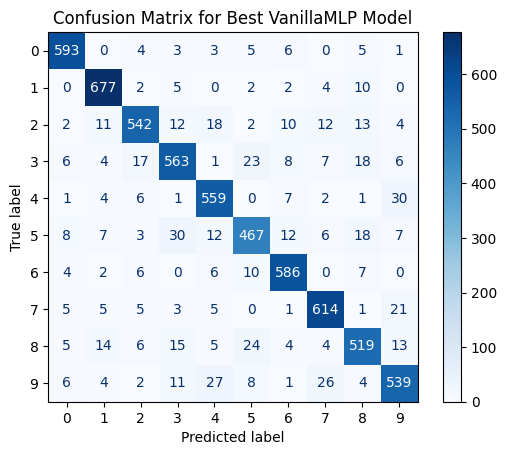

Number of misclassified images by Best VanillaMLP: 641


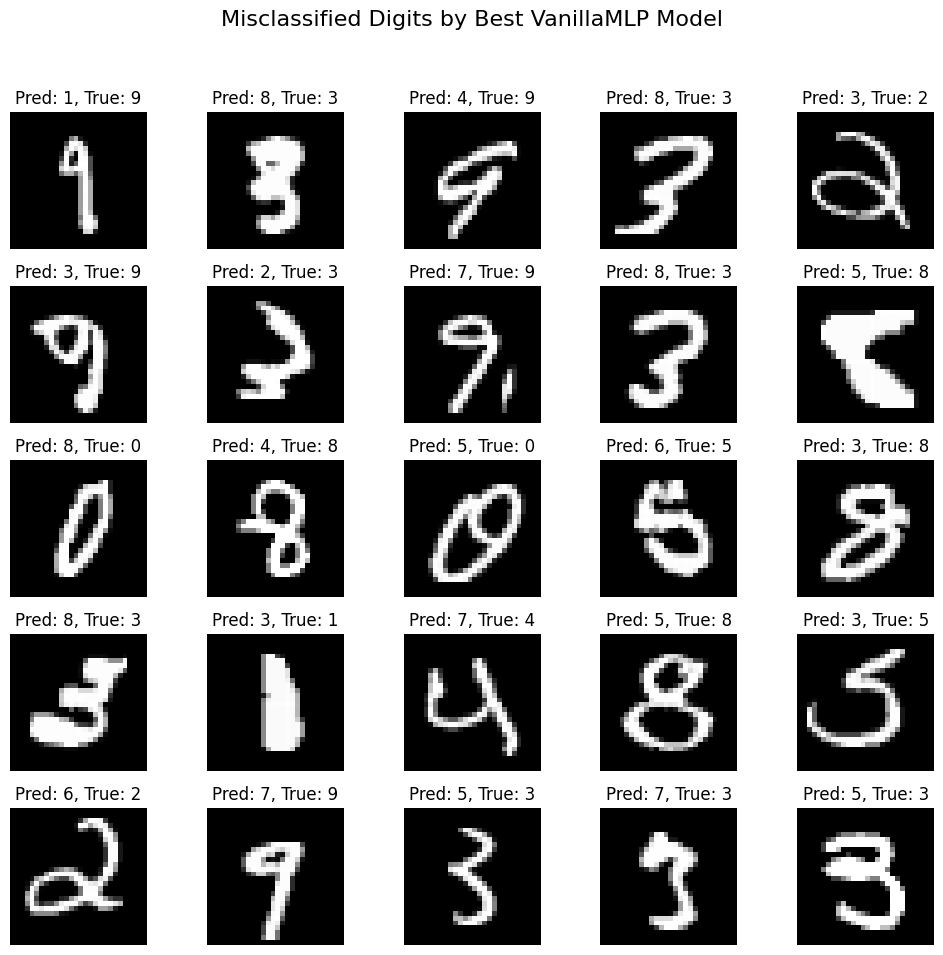

In [26]:
print(f"Best VanillaMLP Model with parameters: {vanilla_grid_search.best_params}")

vanilla_predictions = vanilla_grid_search.best_model_instance.predict(x_test)

cm_vanilla = confusion_matrix(y_test_labels, vanilla_predictions)
disp_vanilla = ConfusionMatrixDisplay(confusion_matrix=cm_vanilla)
disp_vanilla.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix for Best VanillaMLP Model')
plt.show()

misclassified_indices_vanilla = np.where(vanilla_predictions != y_test_labels)[0]
print(f"Number of misclassified images by Best VanillaMLP: {len(misclassified_indices_vanilla)}")

plt.figure(figsize=(10, 10))
for i, bad_index in enumerate(misclassified_indices_vanilla[:25]): 
    plt.subplot(5, 5, i + 1)
    plt.imshow(x_test[bad_index].reshape(28, 28), cmap='gray')
    plt.title(f"Pred: {vanilla_predictions[bad_index]}, True: {y_test_labels[bad_index]}")
    plt.axis('off')
plt.suptitle('Misclassified Digits by Best VanillaMLP Model', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


Best MiniBatchVanillaMLP Model with parameters: {'learning_rate': 0.1, 'batch_size': 64, 'epochs': 30, 'patience': 5, 'min_delta': 0.01}


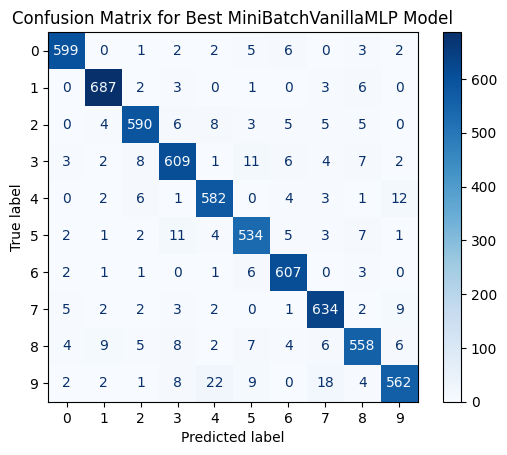

Number of misclassified images by Best MiniBatchVanillaMLP: 338


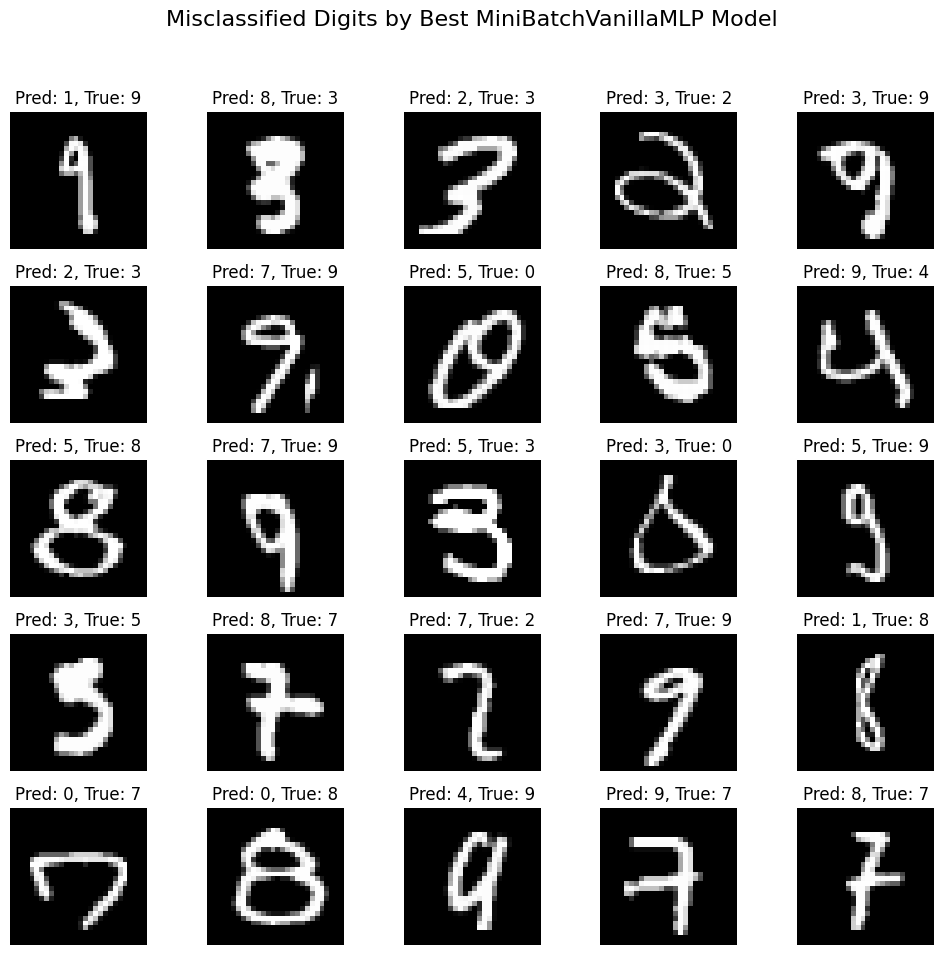

In [27]:
print(f"Best MiniBatchVanillaMLP Model with parameters: {minibatch_grid_search.best_params}")

minibatch_predictions = minibatch_grid_search.best_model_instance.predict(x_test)

cm_minibatch = confusion_matrix(y_test_labels, minibatch_predictions)
disp_minibatch = ConfusionMatrixDisplay(confusion_matrix=cm_minibatch)
disp_minibatch.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix for Best MiniBatchVanillaMLP Model')
plt.show()

misclassified_indices_minibatch = np.where(minibatch_predictions != y_test_labels)[0]
print(f"Number of misclassified images by Best MiniBatchVanillaMLP: {len(misclassified_indices_minibatch)}")

plt.figure(figsize=(10, 10))
for i, bad_index in enumerate(misclassified_indices_minibatch[:25]): 
    plt.subplot(5, 5, i + 1)
    plt.imshow(x_test[bad_index].reshape(28, 28), cmap='gray')
    plt.title(f"Pred: {minibatch_predictions[bad_index]}, True: {y_test_labels[bad_index]}")
    plt.axis('off')
plt.suptitle('Misclassified Digits by Best MiniBatchVanillaMLP Model', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [28]:
class MiniBatchL2RegularizedMLP(MiniBatchVanillaMLP):
    def __init__(self, input_size, hidden_size, output_size, learning_rate, batch_size, l2_lambda=0.01):
        super().__init__(input_size, hidden_size, output_size, learning_rate, batch_size)
        self.l2_lambda = l2_lambda

    def calculate_regularized_loss(self, predicted, actual_labels):
        m = actual_labels.shape[0]
        ce_loss = cross_entropy(predicted, actual_labels)
        l2_reg_term = (np.sum(np.square(self.W1)) + np.sum(np.square(self.W2))) * (self.l2_lambda / (2 * m))
        return ce_loss + l2_reg_term

    def backward(self, X, y_true, cache):
        m = X.shape[0]
        A1 = cache["A1"]
        A2 = cache["A2"]

        dZ2 = A2 - y_true
        dW2 = np.dot(A1.T, dZ2) / m + (self.l2_lambda / m) * self.W2 # L2 gradient
        db2 = np.sum(dZ2, axis=0, keepdims=True) / m

        dA1 = np.dot(dZ2, self.W2.T)
        dZ1 = (dA1 * sigmoid_derivative(cache["Z1"]))
        dW1 = np.dot(X.T, dZ1) / m + (self.l2_lambda / m) * self.W1
        db1 = np.sum(dZ1, axis=0, keepdims=True) / m

        gradients = {
            "dW1": dW1,
            "db1": db1,
            "dW2": dW2,
            "db2": db2
        }
        return gradients

    def train_with_history(self, X_train, y_train_one_hot, y_train_labels, X_val, y_val_one_hot, y_val_labels, X_test, y_test_one_hot, y_test_labels, epochs, patience=10, min_delta=0.0001):
        train_acc_history = []
        val_acc_history = []
        test_acc_history = []

        train_loss_history = []
        val_loss_history = []
        test_loss_history = []

        best_val_loss = float('inf')
        patience_counter = 0

        train_acc_0 = self.evaluate(X_train, y_train_labels)
        val_acc_0 = self.evaluate(X_val, y_val_labels)
        test_acc_0 = self.evaluate(X_test, y_test_labels)

        A2_train_0, _ = self.forward(X_train)
        A2_val_0, _ = self.forward(X_val)
        A2_test_0, _ = self.forward(X_test)

        train_loss_0 = self.calculate_regularized_loss(A2_train_0, y_train_labels)
        val_loss_0 = self.calculate_regularized_loss(A2_val_0, y_val_labels)
        test_loss_0 = self.calculate_regularized_loss(A2_test_0, y_test_labels)

        train_acc_history.append(train_acc_0)
        val_acc_history.append(val_acc_0)
        test_acc_history.append(test_acc_0)
        train_loss_history.append(train_loss_0)
        val_loss_history.append(val_loss_0)
        test_loss_history.append(test_loss_0)

        print(
            f"Initial (Epoch 0) Acc: {train_acc_0*100:.2f}% | "
            f"Val Acc: {val_acc_0*100:.2f}% | "
            f"Test Acc: {test_acc_0*100:.2f}% | "
            f"Train Loss: {train_loss_0:.4f} | "
            f"Val Loss: {val_loss_0:.4f} | "
            f"Test Loss: {test_loss_0:.4f}"
        )
        

        for epoch in range(epochs):
            print(f"\nEpoch {epoch+1}/{epochs}")
            self.train(X_train, y_train_one_hot) # calls the MiniBatchVanillaMLP's train method

            train_acc = self.evaluate(X_train, y_train_labels)
            val_acc = self.evaluate(X_val, y_val_labels)
            test_acc = self.evaluate(X_test, y_test_labels)

            A2_train, _ = self.forward(X_train)
            A2_val, _ = self.forward(X_val)
            A2_test, _ = self.forward(X_test)

            # new loss function
            train_loss = self.calculate_regularized_loss(A2_train, y_train_labels)
            val_loss = self.calculate_regularized_loss(A2_val, y_val_labels)
            test_loss = self.calculate_regularized_loss(A2_test, y_test_labels)

            train_acc_history.append(train_acc)
            val_acc_history.append(val_acc)
            test_acc_history.append(test_acc)

            train_loss_history.append(train_loss)
            val_loss_history.append(val_loss)
            test_loss_history.append(test_loss)

            print(
                 f"Train Acc: {train_acc*100:.2f}% | "
                 f"Val Acc: {val_acc*100:.2f}% | "
                 f"Test Acc: {test_acc*100:.2f}% | "
                 f"Train Loss: {train_loss:.4f} | "
                 f"Val Loss: {val_loss:.4f} | "
                 f"Test Loss: {test_loss:.4f}"
            )

            # early stopping check
            if val_loss < best_val_loss - min_delta:
                best_val_loss = val_loss
                patience_counter = 0
            else:
                patience_counter += 1
                if patience_counter >= patience:
                    print(f"Early stopping at epoch {epoch+1} as validation loss did not improve for {patience} epochs.")
                    break 

        return (train_acc_history, val_acc_history, test_acc_history, train_loss_history, val_loss_history, test_loss_history)

In [29]:
l2_param_grid = {
    'learning_rate': [ 0.1],
    'batch_size': [64],
    'epochs': [ 20],
    'l2_lambda': [0.01, 0.1],
    'patience': [3],
    'min_delta': [0.001]
}

l2_grid_search = GridSearch(model_class=MiniBatchL2RegularizedMLP, param_grid=l2_param_grid)
l2_grid_search.run(x_train, y_train_one_hot, y_train_labels, x_val, y_val_one_hot, y_val_labels, x_test, y_test_one_hot, y_test_labels)

--- Training MiniBatchL2RegularizedMLP with params: {'learning_rate': 0.1, 'batch_size': 64, 'epochs': 20, 'l2_lambda': 0.01, 'patience': 3, 'min_delta': 0.001} ---
Initial (Epoch 0) Acc: 9.98% | Val Acc: 9.97% | Test Acc: 9.97% | Train Loss: 2.4041 | Val Loss: 2.4042 | Test Loss: 2.4033

Epoch 1/20
Train Acc: 86.52% | Val Acc: 86.59% | Test Acc: 85.86% | Train Loss: 0.5701 | Val Loss: 0.5673 | Test Loss: 0.5838

Epoch 2/20
Train Acc: 89.38% | Val Acc: 89.37% | Test Acc: 88.76% | Train Loss: 0.4048 | Val Loss: 0.4050 | Test Loss: 0.4231

Epoch 3/20
Train Acc: 90.31% | Val Acc: 90.10% | Test Acc: 89.70% | Train Loss: 0.3485 | Val Loss: 0.3520 | Test Loss: 0.3709

Epoch 4/20
Train Acc: 90.98% | Val Acc: 90.90% | Test Acc: 90.46% | Train Loss: 0.3180 | Val Loss: 0.3246 | Test Loss: 0.3427

Epoch 5/20
Train Acc: 91.52% | Val Acc: 91.30% | Test Acc: 90.68% | Train Loss: 0.2972 | Val Loss: 0.3065 | Test Loss: 0.3242

Epoch 6/20
Train Acc: 92.03% | Val Acc: 91.49% | Test Acc: 91.33% | Train L

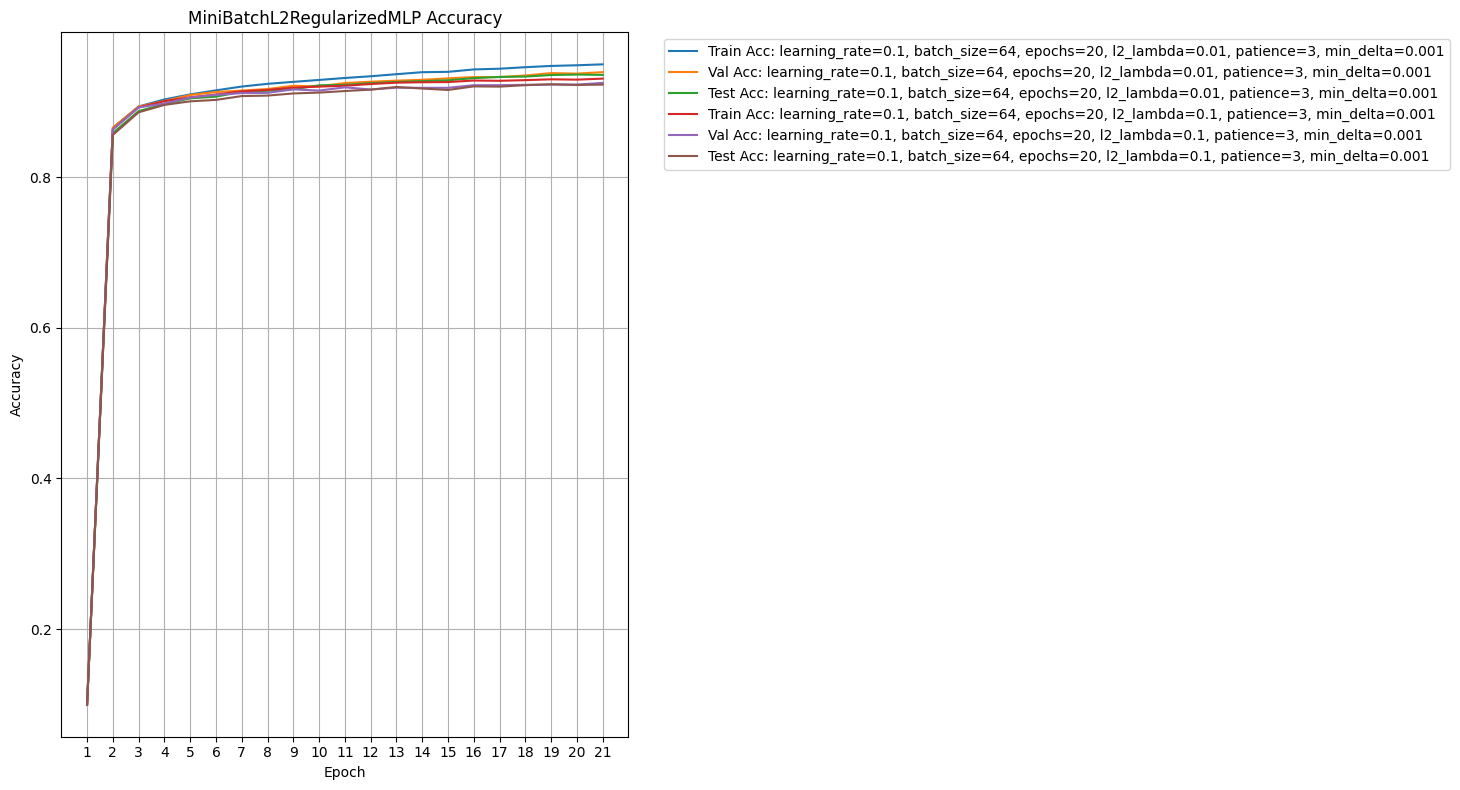

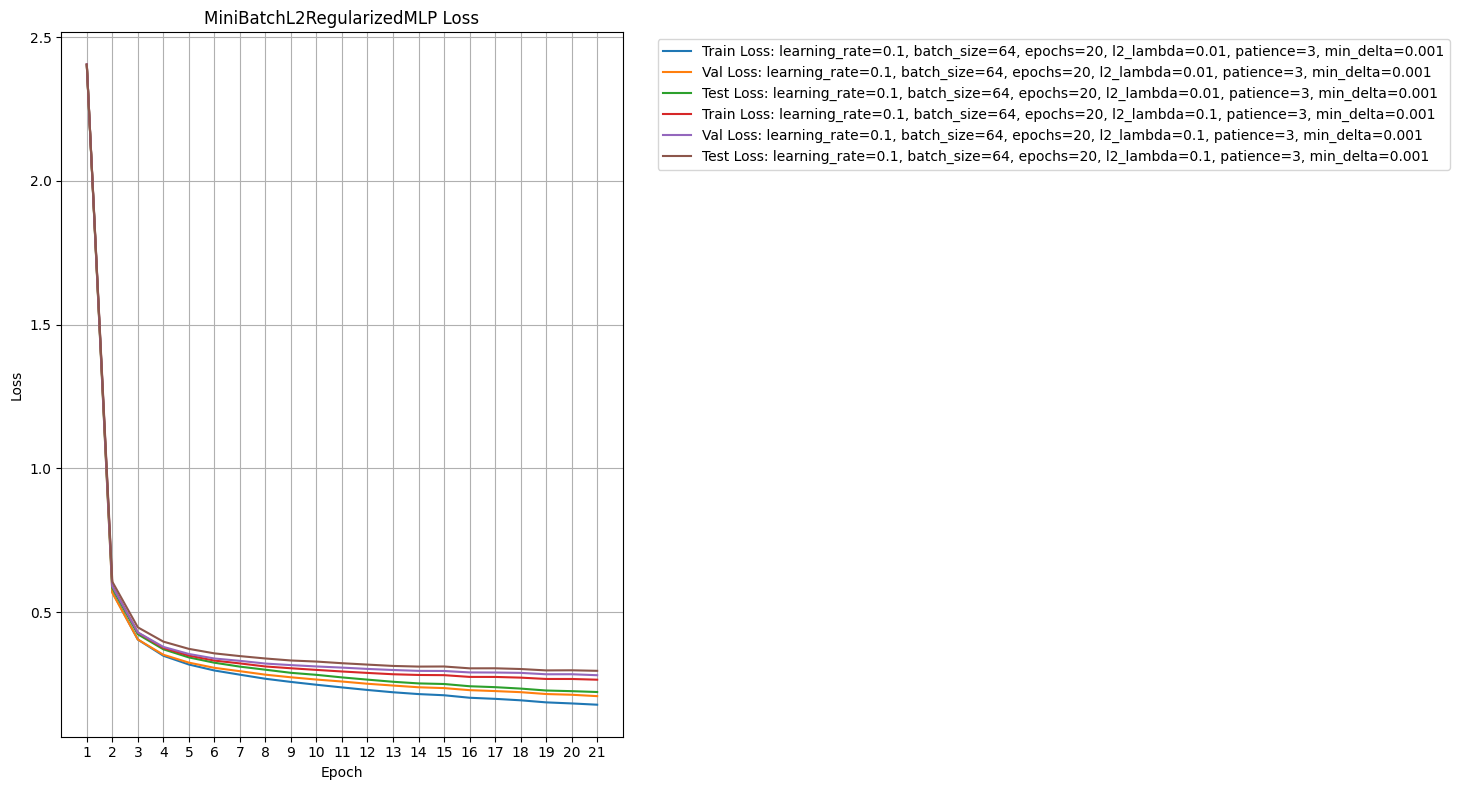

In [30]:
l2_grid_search.plot_results(title_prefix="MiniBatchL2RegularizedMLP")

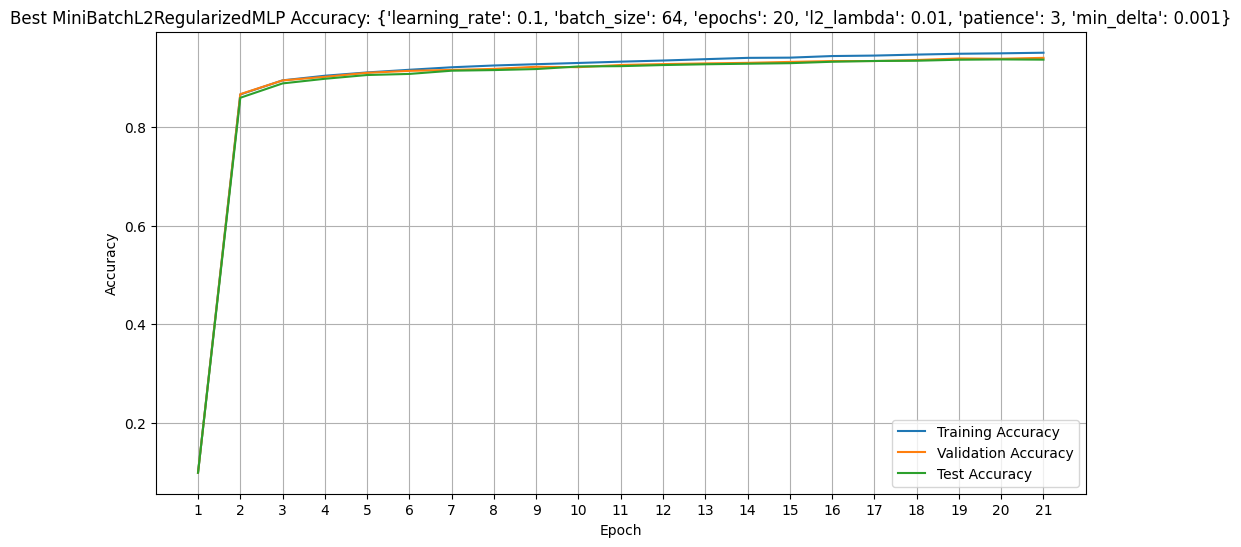

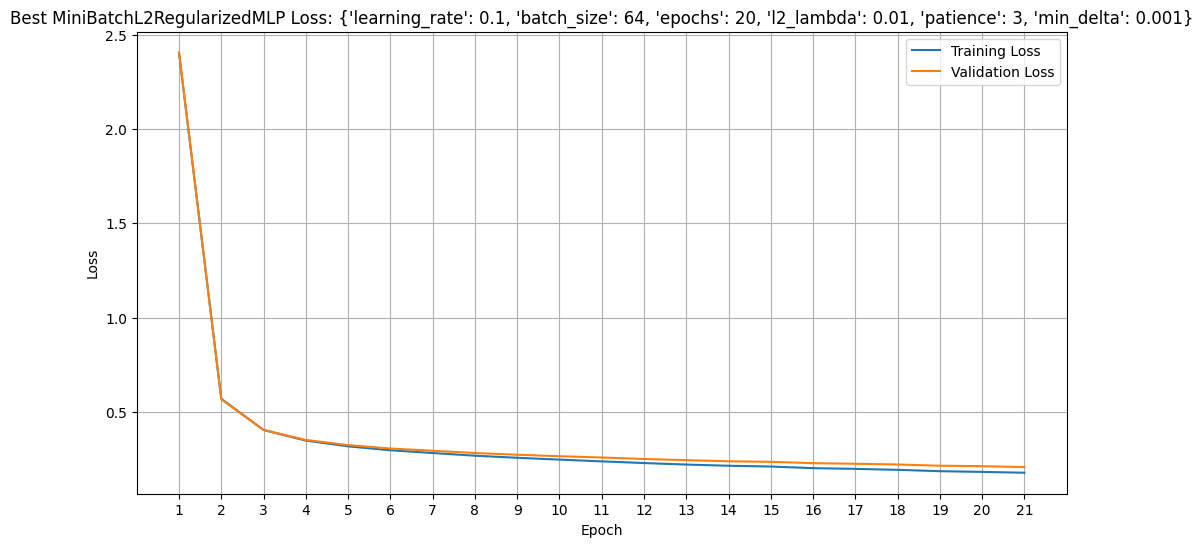

In [31]:
best_l2_results = None
for result in l2_grid_search.results:
    if result['params'] == l2_grid_search.best_params:
        best_l2_results = result
        break
epochs_range_l2 = range(1, len(best_l2_results['train_acc_hist']) + 1)
plt.figure(figsize=(12, 6))
plt.plot(epochs_range_l2, best_l2_results['train_acc_hist'], label='Training Accuracy')
plt.plot(epochs_range_l2, best_l2_results['val_acc_hist'], label='Validation Accuracy')
plt.plot(epochs_range_l2, best_l2_results['test_acc_hist'], label='Test Accuracy')
plt.title(f"Best MiniBatchL2RegularizedMLP Accuracy: {best_l2_results['params']}")
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.xticks(np.arange(min(epochs_range_l2), max(epochs_range_l2) + 1, 1))
plt.show()


plt.figure(figsize=(12, 6))
plt.plot(epochs_range_l2, best_l2_results['train_loss_hist'], label='Training Loss')
plt.plot(epochs_range_l2, best_l2_results['val_loss_hist'], label='Validation Loss')
plt.title(f"Best MiniBatchL2RegularizedMLP Loss: {best_l2_results['params']}")
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.xticks(np.arange(min(epochs_range_l2), max(epochs_range_l2) + 1, 1))
plt.show()

Analyzing Best MiniBatchL2RegularizedMLP Model with parameters: {'learning_rate': 0.1, 'batch_size': 64, 'epochs': 20, 'l2_lambda': 0.01, 'patience': 3, 'min_delta': 0.001}


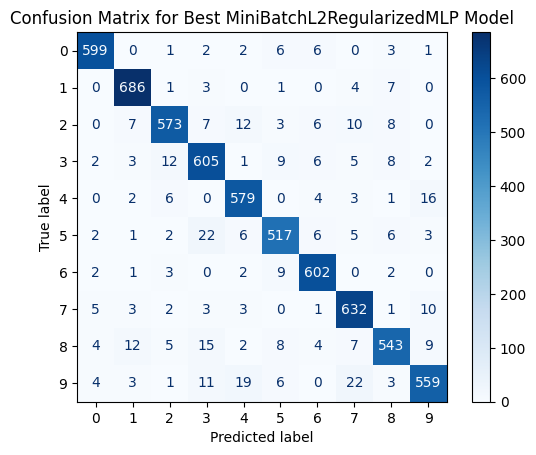

Number of misclassified images by Best MiniBatchL2RegularizedMLP: 405


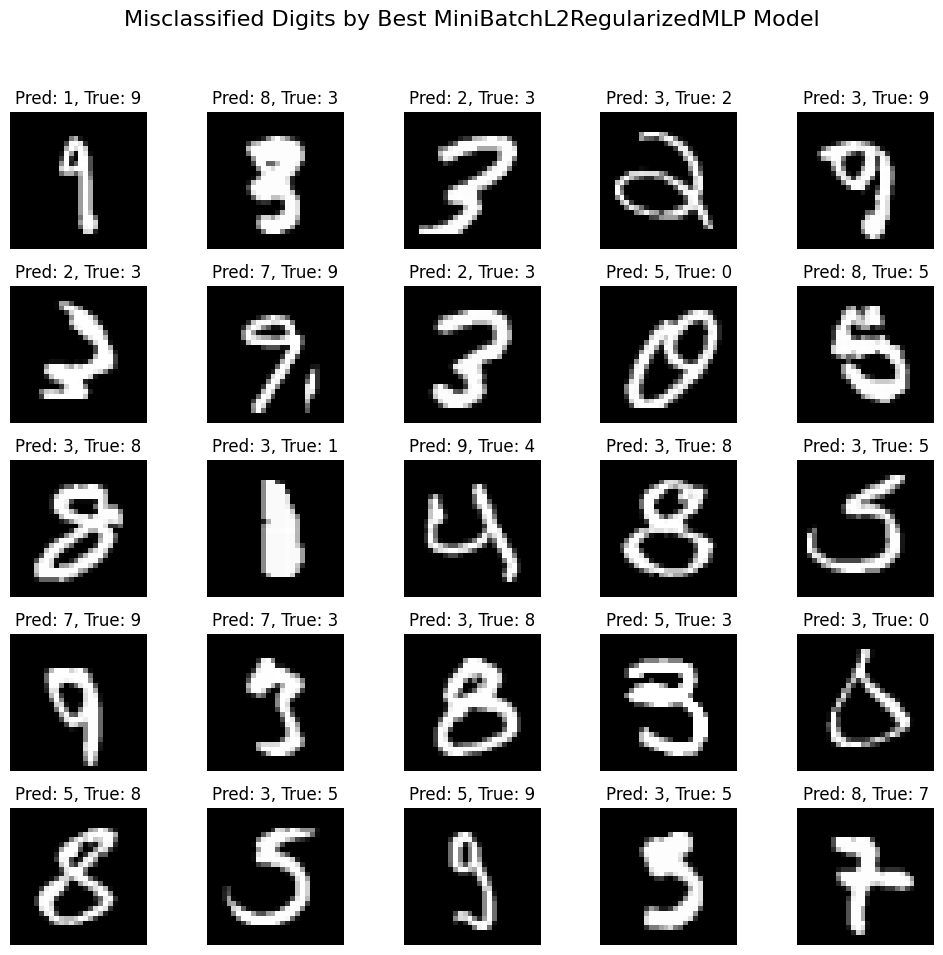

In [32]:
print(f"Analyzing Best MiniBatchL2RegularizedMLP Model with parameters: {l2_grid_search.best_params}")
l2_predictions = l2_grid_search.best_model_instance.predict(x_test)

cm_l2 = confusion_matrix(y_test_labels, l2_predictions)
disp_l2 = ConfusionMatrixDisplay(confusion_matrix=cm_l2)
disp_l2.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix for Best MiniBatchL2RegularizedMLP Model')
plt.show()

misclassified_indices_l2 = np.where(l2_predictions != y_test_labels)[0]
print(f"Number of misclassified images by Best MiniBatchL2RegularizedMLP: {len(misclassified_indices_l2)}")

plt.figure(figsize=(10, 10))
for i, bad_index in enumerate(misclassified_indices_l2[:25]): 
    plt.subplot(5, 5, i + 1)
    plt.imshow(x_test[bad_index].reshape(28, 28), cmap='gray')
    plt.title(f"Pred: {l2_predictions[bad_index]}, True: {y_test_labels[bad_index]}")
    plt.axis('off')
plt.suptitle('Misclassified Digits by Best MiniBatchL2RegularizedMLP Model', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


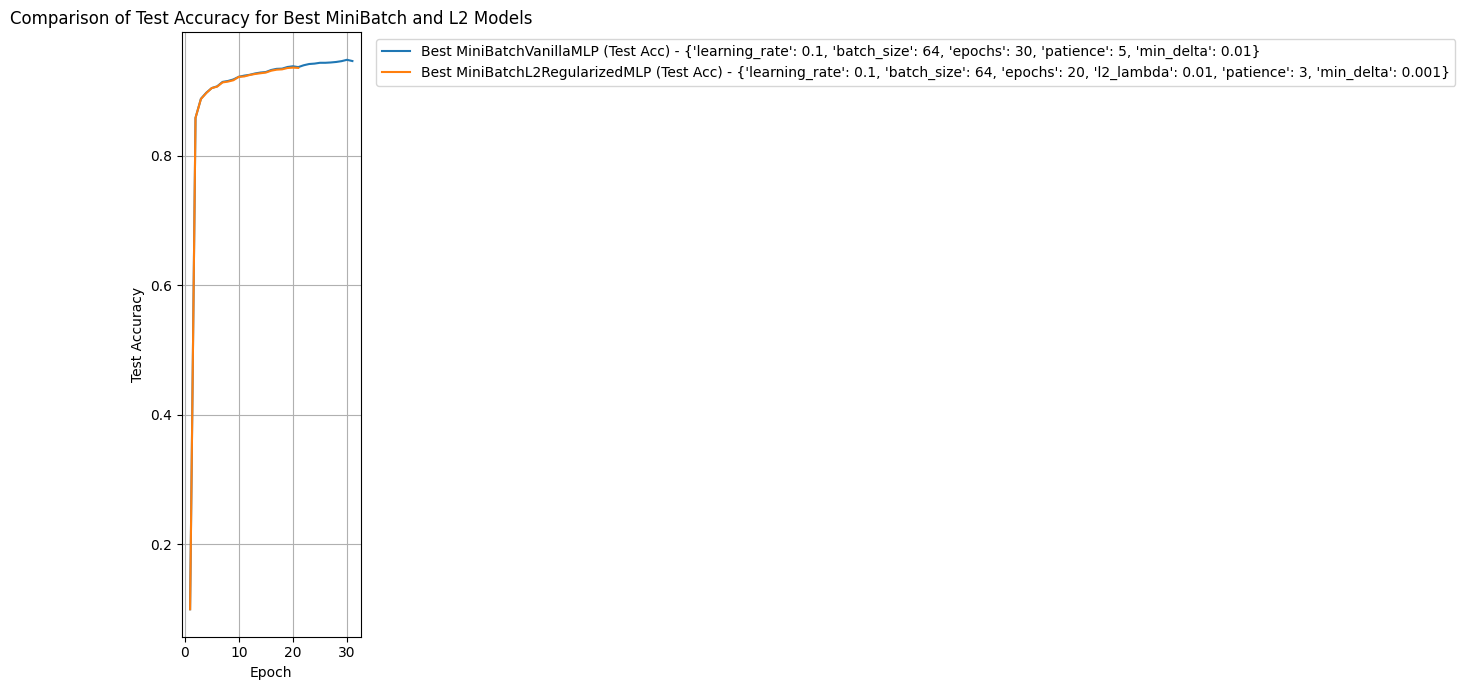

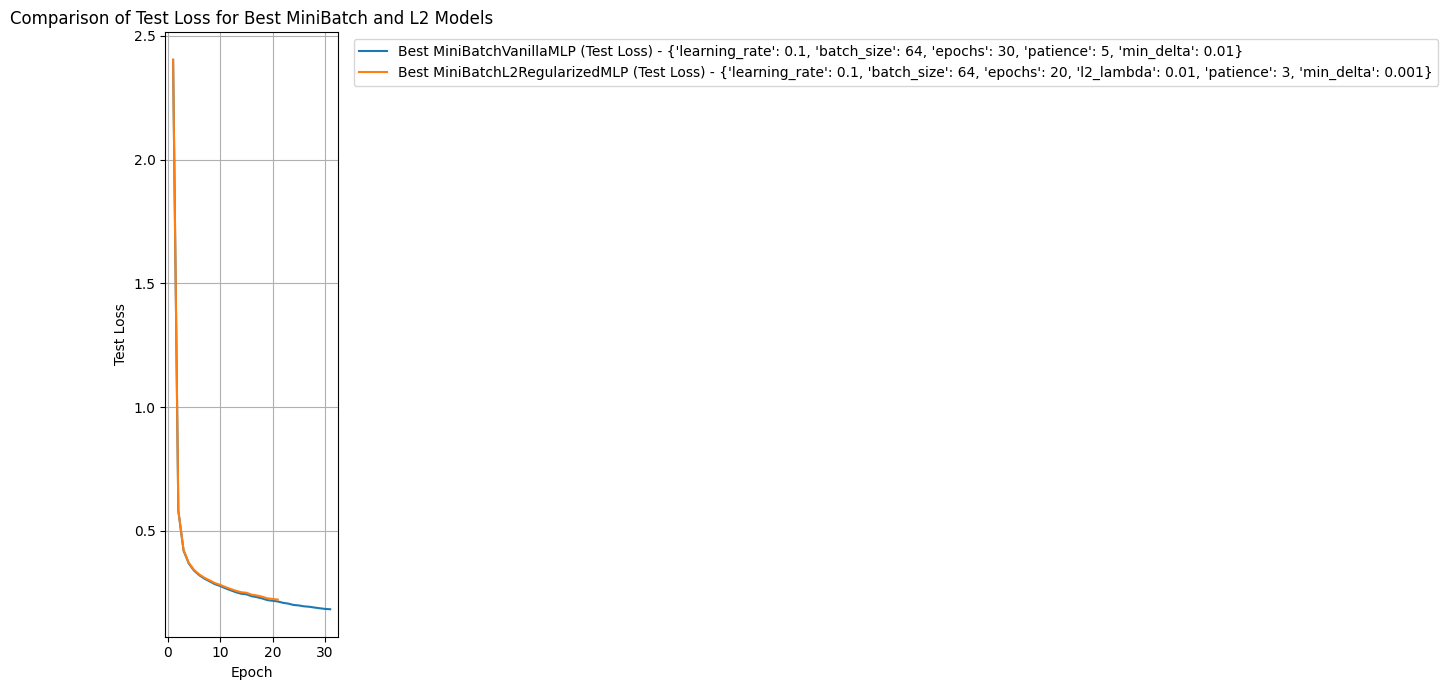

In [33]:
plt.figure(figsize=(14, 7))
epochs_range_minibatch = range(1, len(best_minibatch_results['test_acc_hist']) + 1)
plt.plot(epochs_range_minibatch, best_minibatch_results['test_acc_hist'], label=f"Best MiniBatchVanillaMLP (Test Acc) - {best_minibatch_results['params']}")

epochs_range_l2 = range(1, len(best_l2_results['test_acc_hist']) + 1)
plt.plot(epochs_range_l2, best_l2_results['test_acc_hist'], label=f"Best MiniBatchL2RegularizedMLP (Test Acc) - {best_l2_results['params']}")

plt.title('Comparison of Test Accuracy for Best MiniBatch and L2 Models')
plt.xlabel('Epoch')
plt.ylabel('Test Accuracy')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 7))
plt.plot(epochs_range_minibatch, best_minibatch_results['test_loss_hist'], label=f"Best MiniBatchVanillaMLP (Test Loss) - {best_minibatch_results['params']}")
plt.plot(epochs_range_l2, best_l2_results['test_loss_hist'], label=f"Best MiniBatchL2RegularizedMLP (Test Loss) - {best_l2_results['params']}")

plt.title('Comparison of Test Loss for Best MiniBatch and L2 Models')
plt.xlabel('Epoch')
plt.ylabel('Test Loss')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

In [34]:
print(f"Best MiniBatchVanillaMLP Test Accuracy: {best_minibatch_results['test_acc_hist'][-1]*100:.2f}%")
print(f"Best MiniBatchVanillaMLP Test Loss: {best_minibatch_results['test_loss_hist'][-1]:.4f}")

print(f"\nBest MiniBatchL2RegularizedMLP Test Accuracy: {best_l2_results['test_acc_hist'][-1]*100:.2f}%")
print(f"Best MiniBatchL2RegularizedMLP Test Loss: {best_l2_results['test_loss_hist'][-1]:.4f}")

Best MiniBatchVanillaMLP Test Accuracy: 94.63%
Best MiniBatchVanillaMLP Test Loss: 0.1836

Best MiniBatchL2RegularizedMLP Test Accuracy: 93.57%
Best MiniBatchL2RegularizedMLP Test Loss: 0.2224


In [35]:
class MiniBatchDropoutMLP(MiniBatchVanillaMLP):
    def __init__(self, input_size, hidden_size, output_size, learning_rate, batch_size, dropout_rate=0.5):
        super().__init__(input_size, hidden_size, output_size, learning_rate, batch_size)
        self.dropout_rate = dropout_rate

    def forward(self, X, training=True):
        Z1 = np.dot(X, self.W1) + self.b1
        A1 = sigmoid(Z1)

        # dropout to the hidden layer output during training
        if training:
            D1 = np.random.rand(*A1.shape) > self.dropout_rate
            A1 *= D1
            A1 /= (1 - self.dropout_rate) # scale up activations
        else:
            D1 = None # not needed during inference

        Z2 = np.dot(A1, self.W2) + self.b2
        A2 = softmax(Z2)

        cache = {
            "Z1": Z1,
            "A1": A1,
            "Z2": Z2,
            "A2": A2,
            "D1": D1 # store dropout mask for backward pass
        }
        return A2, cache

    def predict(self, X):
        # for prediction, dropout is not applied, and activations are already scaled during training
        A2, _ = self.forward(X, training=False)
        predictions = np.argmax(A2, axis=1)
        return predictions

    def backward(self, X, y_true, cache):
        m = X.shape[0]
        A1 = cache["A1"]
        D1 = cache["D1"]
        A2 = cache["A2"]

        # output layer gradients
        dZ2 = A2 - y_true
        dW2 = np.dot(A1.T, dZ2) / m
        db2 = np.sum(dZ2, axis=0, keepdims=True) / m

        # hidden layer gradients
        dA1 = np.dot(dZ2, self.W2.T)
        # re-apply dropout mask and scaling to dA1 during backward pass
        if D1 is not None:
            dA1 *= D1
            dA1 /= (1 - self.dropout_rate)

        dZ1 = (dA1 * sigmoid_derivative(cache["Z1"])) 
        dW1 = np.dot(X.T, dZ1) / m
        db1 = np.sum(dZ1, axis=0, keepdims=True) / m

        gradients = {
            "dW1": dW1,
            "db1": db1,
            "dW2": dW2,
            "db2": db2
        }
        return gradients

    def train(self, X, y):
        m = X.shape[0]
        num_batches = m // self.batch_size
        indices = np.arange(m)
        np.random.shuffle(indices)

        for i in range(num_batches):
            start_idx = i * self.batch_size
            end_idx = start_idx + self.batch_size

            batch_X = X[indices[start_idx:end_idx]]
            batch_y = y[indices[start_idx:end_idx]]

            A2, cache = self.forward(batch_X, training=True)
            gradients = self.backward(batch_X, batch_y, cache)
            self.update_parameters(gradients)

    def train_with_history(self, X_train, y_train_one_hot, y_train_labels, X_val, y_val_one_hot, y_val_labels, X_test, y_test_one_hot, y_test_labels, epochs, patience=10, min_delta=0.0001):
        train_acc_history = []
        val_acc_history = []
        test_acc_history = []

        train_loss_history = []
        val_loss_history = []
        test_loss_history = []

        best_val_loss = float('inf')
        patience_counter = 0

            
        train_acc_0 = self.evaluate(X_train, y_train_labels)
        val_acc_0 = self.evaluate(X_val, y_val_labels)
        test_acc_0 = self.evaluate(X_test, y_test_labels)

        A2_train_0, _ = self.forward(X_train, training=False)
        A2_val_0, _ = self.forward(X_val, training=False)
        A2_test_0, _ = self.forward(X_test, training=False)

        train_loss_0 = cross_entropy(A2_train_0, y_train_labels)
        val_loss_0 = cross_entropy(A2_val_0, y_val_labels)
        test_loss_0 = cross_entropy(A2_test_0, y_test_labels)

        train_acc_history.append(train_acc_0)
        val_acc_history.append(val_acc_0)
        test_acc_history.append(test_acc_0)
        train_loss_history.append(train_loss_0)
        val_loss_history.append(val_loss_0)
        test_loss_history.append(test_loss_0)

        print(
            f"Initial (Epoch 0) Acc: {train_acc_0*100:.2f}% | "
            f"Val Acc: {val_acc_0*100:.2f}% | "
            f"Test Acc: {test_acc_0*100:.2f}% | "
            f"Train Loss: {train_loss_0:.4f} | "
            f"Val Loss: {val_loss_0:.4f} | "
            f"Test Loss: {test_loss_0:.4f}"
        )
        

        for epoch in range(epochs):
            print(f"\nEpoch {epoch+1}/{epochs}")
            self.train(X_train, y_train_one_hot)

            train_acc = self.evaluate(X_train, y_train_labels)
            val_acc = self.evaluate(X_val, y_val_labels)
            test_acc = self.evaluate(X_test, y_test_labels)

            A2_train, _ = self.forward(X_train, training=False)
            A2_val, _ = self.forward(X_val, training=False)
            A2_test, _ = self.forward(X_test, training=False)

            train_loss = cross_entropy(A2_train, y_train_labels)
            val_loss = cross_entropy(A2_val, y_val_labels)
            test_loss = cross_entropy(A2_test, y_test_labels)

            train_acc_history.append(train_acc)
            val_acc_history.append(val_acc)
            test_acc_history.append(test_acc)

            train_loss_history.append(train_loss)
            val_loss_history.append(val_loss)
            test_loss_history.append(test_loss)

            print(
                 f"Train Acc: {train_acc*100:.2f}% | "
                 f"Val Acc: {val_acc*100:.2f}% | "
                 f"Test Acc: {test_acc*100:.2f}% | "
                 f"Train Loss: {train_loss:.4f} | "
                 f"Val Loss: {val_loss:.4f} | "
                 f"Test Loss: {test_loss:.4f}"
            )

            if val_loss < best_val_loss - min_delta:
                best_val_loss = val_loss
                patience_counter = 0
            else:
                patience_counter += 1
                if patience_counter >= patience:
                    print(f"Early stopping at epoch {epoch+1} as validation loss did not improve for {patience} epochs.")
                    break 

        return (train_acc_history, val_acc_history, test_acc_history, train_loss_history, val_loss_history, test_loss_history)

In [36]:
learning_rate_dropout = 0.5
batch_size_dropout = 64
epochs_dropout = 20
dropout_rate_value = 0.3

dropout_mlp = MiniBatchDropoutMLP(input_size=x_train.shape[1], hidden_size=100, output_size=10,
                                  learning_rate=learning_rate_dropout, batch_size=batch_size_dropout,
                                  dropout_rate=dropout_rate_value)

print(f"--- Training MiniBatchDropoutMLP with params: learning_rate={learning_rate_dropout}, batch_size={batch_size_dropout}, dropout_rate={dropout_rate_value}, epochs={epochs_dropout} ---")

dropout_train_acc_history, dropout_val_acc_history, dropout_test_acc_history, \
dropout_train_loss_history, dropout_val_loss_history, dropout_test_loss_history = dropout_mlp.train_with_history(
    x_train, y_train_one_hot, y_train_labels,
    x_val, y_val_one_hot, y_val_labels,
    x_test, y_test_one_hot, y_test_labels,
    epochs=epochs_dropout, patience=5, min_delta=0.0001
)


best_dropout_results = {
    'params': {'learning_rate': learning_rate_dropout, 'batch_size': batch_size_dropout, 'epochs': epochs_dropout, 'dropout_rate': dropout_rate_value},
    'train_acc_hist': dropout_train_acc_history,
    'val_acc_hist': dropout_val_acc_history,
    'test_acc_hist': dropout_test_acc_history,
    'train_loss_hist': dropout_train_loss_history,
    'val_loss_hist': dropout_val_loss_history,
    'test_loss_hist': dropout_test_loss_history
}

--- Training MiniBatchDropoutMLP with params: learning_rate=0.5, batch_size=64, dropout_rate=0.3, epochs=20 ---
Initial (Epoch 0) Acc: 9.98% | Val Acc: 9.97% | Test Acc: 9.97% | Train Loss: 2.4041 | Val Loss: 2.4042 | Test Loss: 2.4033

Epoch 1/20
Train Acc: 90.54% | Val Acc: 90.44% | Test Acc: 89.84% | Train Loss: 0.3260 | Val Loss: 0.3327 | Test Loss: 0.3498

Epoch 2/20
Train Acc: 92.60% | Val Acc: 92.11% | Test Acc: 91.76% | Train Loss: 0.2498 | Val Loss: 0.2640 | Test Loss: 0.2791

Epoch 3/20
Train Acc: 93.83% | Val Acc: 93.22% | Test Acc: 92.76% | Train Loss: 0.2096 | Val Loss: 0.2281 | Test Loss: 0.2436

Epoch 4/20
Train Acc: 94.76% | Val Acc: 94.05% | Test Acc: 93.65% | Train Loss: 0.1796 | Val Loss: 0.2013 | Test Loss: 0.2154

Epoch 5/20
Train Acc: 95.21% | Val Acc: 94.33% | Test Acc: 93.95% | Train Loss: 0.1615 | Val Loss: 0.1881 | Test Loss: 0.2008

Epoch 6/20
Train Acc: 95.65% | Val Acc: 94.94% | Test Acc: 94.48% | Train Loss: 0.1459 | Val Loss: 0.1755 | Test Loss: 0.1916

E

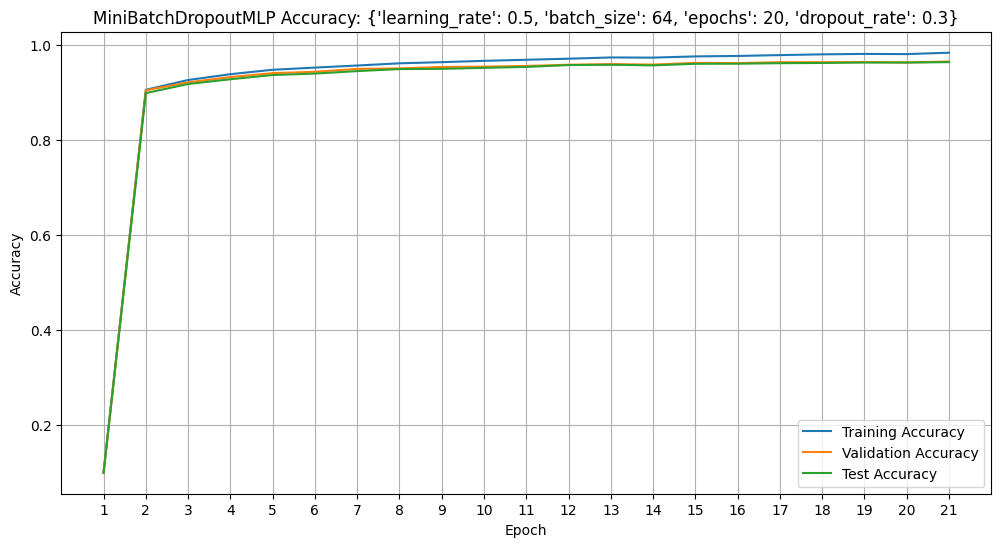

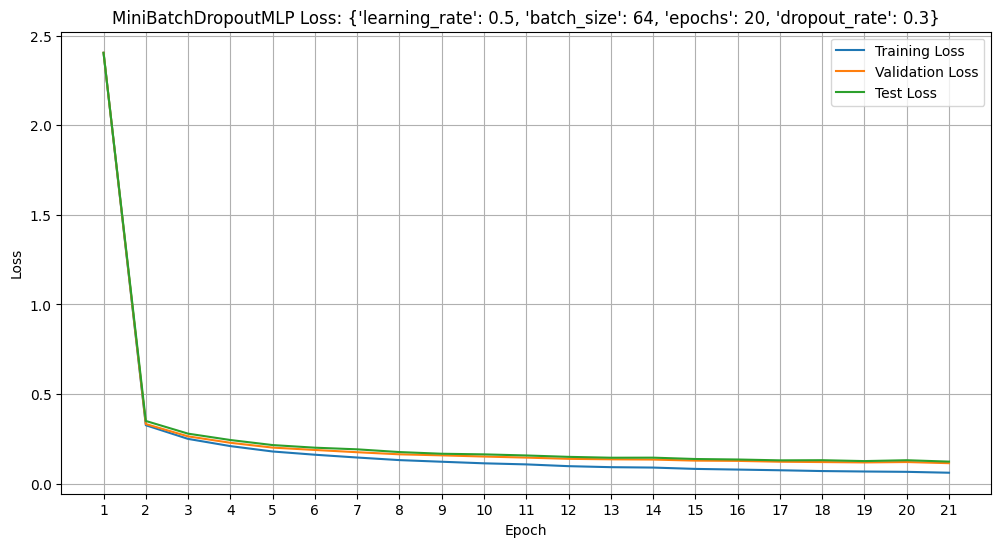

In [37]:
epochs_range_dropout = range(1, len(best_dropout_results['train_acc_hist']) + 1)
plt.figure(figsize=(12, 6))
plt.plot(epochs_range_dropout, best_dropout_results['train_acc_hist'], label='Training Accuracy')
plt.plot(epochs_range_dropout, best_dropout_results['val_acc_hist'], label='Validation Accuracy')
plt.plot(epochs_range_dropout, best_dropout_results['test_acc_hist'], label='Test Accuracy')
plt.title(f"MiniBatchDropoutMLP Accuracy: {best_dropout_results['params']}")
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.xticks(np.arange(min(epochs_range_dropout), max(epochs_range_dropout) + 1, 1))
plt.show()


plt.figure(figsize=(12, 6))
plt.plot(epochs_range_dropout, best_dropout_results['train_loss_hist'], label='Training Loss')
plt.plot(epochs_range_dropout, best_dropout_results['val_loss_hist'], label='Validation Loss')
plt.plot(epochs_range_dropout, best_dropout_results['test_loss_hist'], label='Test Loss')
plt.title(f"MiniBatchDropoutMLP Loss: {best_dropout_results['params']}")
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.xticks(np.arange(min(epochs_range_dropout), max(epochs_range_dropout) + 1, 1))
plt.show()

Analyzing MiniBatchDropoutMLP Model with parameters: {'learning_rate': 0.5, 'batch_size': 64, 'epochs': 20, 'dropout_rate': 0.3}


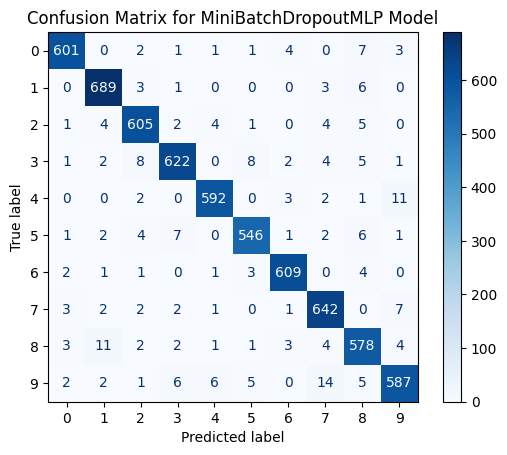

Number of misclassified images by MiniBatchDropoutMLP: 229


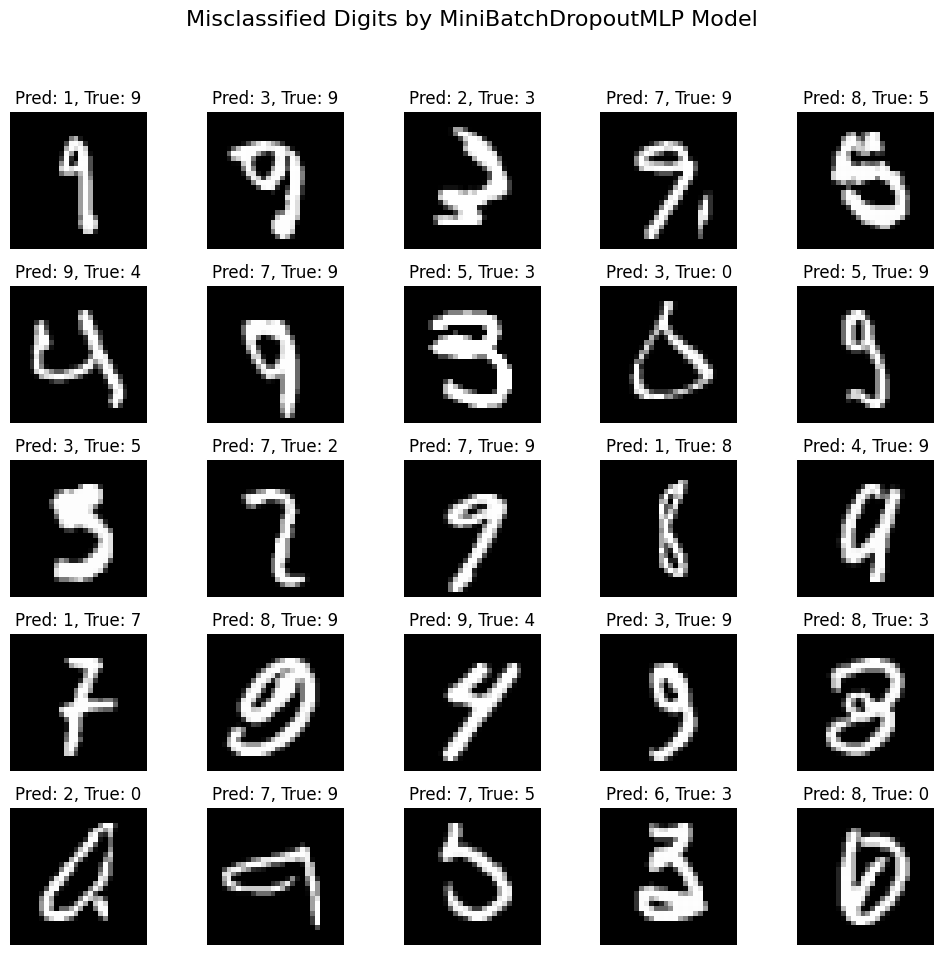

In [38]:
print(f"Analyzing MiniBatchDropoutMLP Model with parameters: {best_dropout_results['params']}")
dropout_predictions = dropout_mlp.predict(x_test)

cm_dropout = confusion_matrix(y_test_labels, dropout_predictions)
disp_dropout = ConfusionMatrixDisplay(confusion_matrix=cm_dropout)
disp_dropout.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix for MiniBatchDropoutMLP Model')
plt.show()

misclassified_indices_dropout = np.where(dropout_predictions != y_test_labels)[0]
print(f"Number of misclassified images by MiniBatchDropoutMLP: {len(misclassified_indices_dropout)}")

plt.figure(figsize=(10, 10))
for i, bad_index in enumerate(misclassified_indices_dropout[:25]): # Display first 25 misclassified
    plt.subplot(5, 5, i + 1)
    plt.imshow(x_test[bad_index].reshape(28, 28), cmap='gray')
    plt.title(f"Pred: {dropout_predictions[bad_index]}, True: {y_test_labels[bad_index]}")
    plt.axis('off')
plt.suptitle('Misclassified Digits by MiniBatchDropoutMLP Model', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [39]:
class MiniBatchMomentumMLP(MiniBatchVanillaMLP):
    def __init__(self, input_size, hidden_size, output_size, learning_rate, batch_size, momentum_beta=0.9):
        super().__init__(input_size, hidden_size, output_size, learning_rate, batch_size)
        self.momentum_beta = momentum_beta

        self.v_W1 = np.zeros_like(self.W1)
        self.v_b1 = np.zeros_like(self.b1)
        self.v_W2 = np.zeros_like(self.W2)
        self.v_b2 = np.zeros_like(self.b2)

    def update_parameters(self, gradients):
        self.v_W1 = self.momentum_beta * self.v_W1 + (1 - self.momentum_beta) * gradients["dW1"]
        self.v_b1 = self.momentum_beta * self.v_b1 + (1 - self.momentum_beta) * gradients["db1"]
        self.v_W2 = self.momentum_beta * self.v_W2 + (1 - self.momentum_beta) * gradients["dW2"]
        self.v_b2 = self.momentum_beta * self.v_b2 + (1 - self.momentum_beta) * gradients["db2"]

        self.W1 -= self.learning_rate * self.v_W1
        self.b1 -= self.learning_rate * self.v_b1
        self.W2 -= self.learning_rate * self.v_W2
        self.b2 -= self.learning_rate * self.v_b2

In [40]:
learning_rate_momentum = 0.1
batch_size_momentum = 64
epochs_momentum = 20
momentum_beta_value = 0.9 

momentum_mlp = MiniBatchMomentumMLP(input_size=x_train.shape[1], hidden_size=100, output_size=10,
                                  learning_rate=learning_rate_momentum, batch_size=batch_size_momentum,
                                  momentum_beta=momentum_beta_value)

print(f"--- Training MiniBatchMomentumMLP with params: learning_rate={learning_rate_momentum}, batch_size={batch_size_momentum}, momentum_beta={momentum_beta_value}, epochs={epochs_momentum} ---")

momentum_train_acc_history, momentum_val_acc_history, momentum_test_acc_history, \
momentum_train_loss_history, momentum_val_loss_history, momentum_test_loss_history = momentum_mlp.train_with_history(
    x_train, y_train_one_hot, y_train_labels,
    x_val, y_val_one_hot, y_val_labels,
    x_test, y_test_one_hot, y_test_labels,
    epochs=epochs_momentum, patience=5, min_delta=0.0001
)

best_momentum_results = {
    'params': {'learning_rate': learning_rate_momentum, 'batch_size': batch_size_momentum, 'epochs': epochs_momentum, 'momentum_beta': momentum_beta_value},
    'train_acc_hist': momentum_train_acc_history,
    'val_acc_hist': momentum_val_acc_history,
    'test_acc_hist': momentum_test_acc_history,
    'train_loss_hist': momentum_train_loss_history,
    'val_loss_hist': momentum_val_loss_history,
    'test_loss_hist': momentum_test_loss_history
}

--- Training MiniBatchMomentumMLP with params: learning_rate=0.1, batch_size=64, momentum_beta=0.9, epochs=20 ---
Initial (Epoch 0) Acc: 9.98% | Val Acc: 9.97% | Test Acc: 9.97% | Train Loss: 2.4041 | Val Loss: 2.4042 | Test Loss: 2.4033

Epoch 1/20
Train Acc: 86.09% | Val Acc: 86.16% | Test Acc: 85.25% | Train Loss: 0.5742 | Val Loss: 0.5709 | Test Loss: 0.5873

Epoch 2/20
Train Acc: 89.43% | Val Acc: 89.30% | Test Acc: 89.06% | Train Loss: 0.4039 | Val Loss: 0.4035 | Test Loss: 0.4225

Epoch 3/20
Train Acc: 90.34% | Val Acc: 90.13% | Test Acc: 89.56% | Train Loss: 0.3459 | Val Loss: 0.3492 | Test Loss: 0.3685

Epoch 4/20
Train Acc: 91.12% | Val Acc: 91.02% | Test Acc: 90.33% | Train Loss: 0.3153 | Val Loss: 0.3221 | Test Loss: 0.3410

Epoch 5/20
Train Acc: 91.60% | Val Acc: 91.27% | Test Acc: 90.76% | Train Loss: 0.2932 | Val Loss: 0.3025 | Test Loss: 0.3213

Epoch 6/20
Train Acc: 92.08% | Val Acc: 91.44% | Test Acc: 91.30% | Train Loss: 0.2774 | Val Loss: 0.2898 | Test Loss: 0.3056


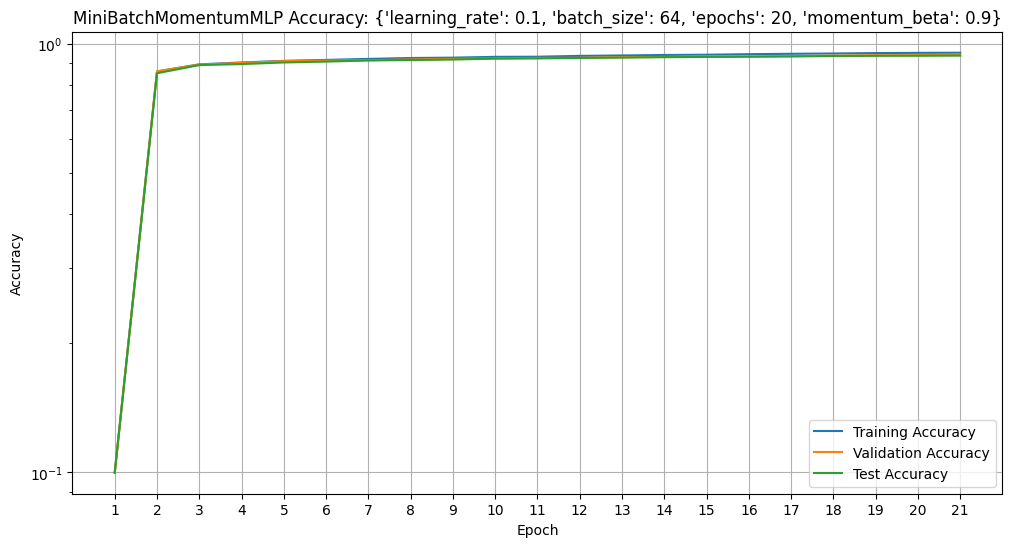

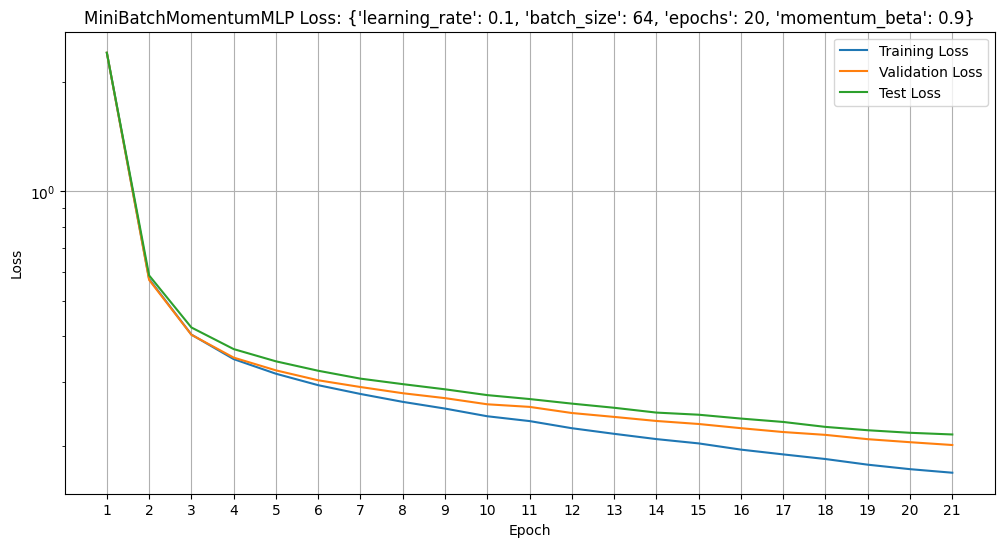

In [41]:
epochs_range_momentum = range(1, len(best_momentum_results['train_acc_hist']) + 1)
plt.figure(figsize=(12, 6))
plt.plot(epochs_range_momentum, best_momentum_results['train_acc_hist'], label='Training Accuracy')
plt.plot(epochs_range_momentum, best_momentum_results['val_acc_hist'], label='Validation Accuracy')
plt.plot(epochs_range_momentum, best_momentum_results['test_acc_hist'], label='Test Accuracy')
plt.title(f"MiniBatchMomentumMLP Accuracy: {best_momentum_results['params']}")
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.yscale('log')
plt.xticks(np.arange(min(epochs_range_momentum), max(epochs_range_momentum) + 1, 1))
plt.show()


plt.figure(figsize=(12, 6))
plt.plot(epochs_range_momentum, best_momentum_results['train_loss_hist'], label='Training Loss')
plt.plot(epochs_range_momentum, best_momentum_results['val_loss_hist'], label='Validation Loss')
plt.plot(epochs_range_momentum, best_momentum_results['test_loss_hist'], label='Test Loss')
plt.title(f"MiniBatchMomentumMLP Loss: {best_momentum_results['params']}")
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.yscale('log')
plt.xticks(np.arange(min(epochs_range_momentum), max(epochs_range_momentum) + 1, 1))
plt.show()

Analyzing MiniBatchMomentumMLP Model with parameters: {'learning_rate': 0.1, 'batch_size': 64, 'epochs': 20, 'momentum_beta': 0.9}


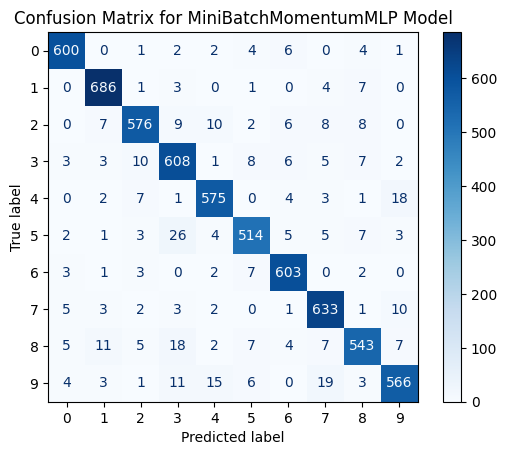

Number of misclassified images by MiniBatchMomentumMLP: 396


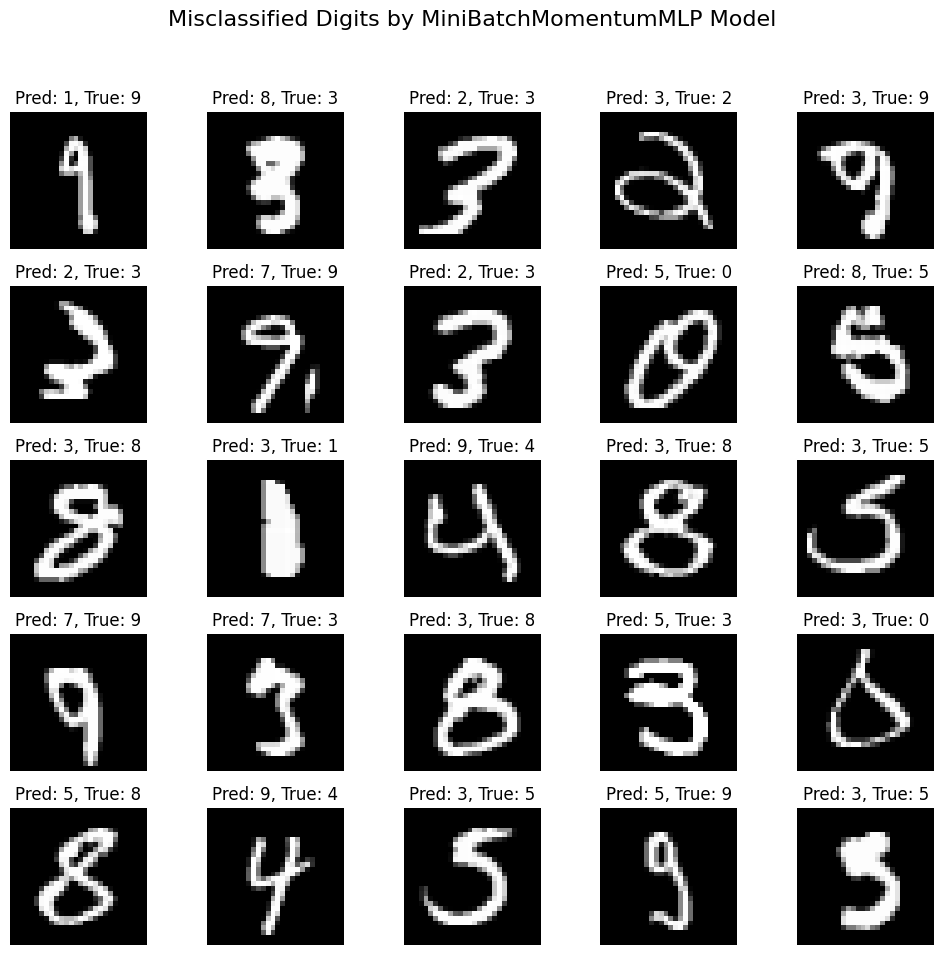

In [42]:
print(f"Analyzing MiniBatchMomentumMLP Model with parameters: {best_momentum_results['params']}")
momentum_predictions = momentum_mlp.predict(x_test)

cm_momentum = confusion_matrix(y_test_labels, momentum_predictions)
disp_momentum = ConfusionMatrixDisplay(confusion_matrix=cm_momentum)
disp_momentum.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix for MiniBatchMomentumMLP Model')
plt.show()

misclassified_indices_momentum = np.where(momentum_predictions != y_test_labels)[0]
print(f"Number of misclassified images by MiniBatchMomentumMLP: {len(misclassified_indices_momentum)}")

plt.figure(figsize=(10, 10))
for i, bad_index in enumerate(misclassified_indices_momentum[:25]): 
    plt.subplot(5, 5, i + 1)
    plt.imshow(x_test[bad_index].reshape(28, 28), cmap='gray')
    plt.title(f"Pred: {momentum_predictions[bad_index]}, True: {y_test_labels[bad_index]}")
    plt.axis('off')
plt.suptitle('Misclassified Digits by MiniBatchMomentumMLP Model', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [43]:
class MiniBatchRMSpropMLP(MiniBatchVanillaMLP):
    def __init__(self, input_size, hidden_size, output_size, learning_rate, batch_size, decay_rate=0.9, epsilon=1e-8):
        super().__init__(input_size, hidden_size, output_size, learning_rate, batch_size)
        self.decay_rate = decay_rate
        self.epsilon = epsilon
       
        self.s_W1 = np.zeros_like(self.W1)
        self.s_b1 = np.zeros_like(self.b1)
        self.s_W2 = np.zeros_like(self.W2)
        self.s_b2 = np.zeros_like(self.b2)

    def update_parameters(self, gradients):
       
        self.s_W1 = self.decay_rate * self.s_W1 + (1 - self.decay_rate) * (gradients["dW1"] ** 2)
        self.s_b1 = self.decay_rate * self.s_b1 + (1 - self.decay_rate) * (gradients["db1"] ** 2)
        self.s_W2 = self.decay_rate * self.s_W2 + (1 - self.decay_rate) * (gradients["dW2"] ** 2)
        self.s_b2 = self.decay_rate * self.s_b2 + (1 - self.decay_rate) * (gradients["db2"] ** 2)

        
        self.W1 -= self.learning_rate * gradients["dW1"] / (np.sqrt(self.s_W1) + self.epsilon)
        self.b1 -= self.learning_rate * gradients["db1"] / (np.sqrt(self.s_b1) + self.epsilon)
        self.W2 -= self.learning_rate * gradients["dW2"] / (np.sqrt(self.s_W2) + self.epsilon)
        self.b2 -= self.learning_rate * gradients["db2"] / (np.sqrt(self.s_b2) + self.epsilon)

In [44]:
learning_rate_rmsprop = 0.001 
batch_size_rmsprop = 64
epochs_rmsprop = 20
decay_rate_value = 0.9

rmsprop_mlp = MiniBatchRMSpropMLP(input_size=x_train.shape[1], hidden_size=100, output_size=10,
                                 learning_rate=learning_rate_rmsprop, batch_size=batch_size_rmsprop,
                                 decay_rate=decay_rate_value)

print(f"--- Training MiniBatchRMSpropMLP with params: learning_rate={learning_rate_rmsprop}, batch_size={batch_size_rmsprop}, decay_rate={decay_rate_value}, epochs={epochs_rmsprop} ---")

rmsprop_train_acc_history, rmsprop_val_acc_history, rmsprop_test_acc_history, \
rmsprop_train_loss_history, rmsprop_val_loss_history, rmsprop_test_loss_history = rmsprop_mlp.train_with_history(
    x_train, y_train_one_hot, y_train_labels,
    x_val, y_val_one_hot, y_val_labels,
    x_test, y_test_one_hot, y_test_labels,
    epochs=epochs_rmsprop, patience=5, min_delta=0.0001
)

best_rmsprop_results = {
    'params': {'learning_rate': learning_rate_rmsprop, 'batch_size': batch_size_rmsprop, 'epochs': epochs_rmsprop, 'decay_rate': decay_rate_value},
    'train_acc_hist': rmsprop_train_acc_history,
    'val_acc_hist': rmsprop_val_acc_history,
    'test_acc_hist': rmsprop_test_acc_history,
    'train_loss_hist': rmsprop_train_loss_history,
    'val_loss_hist': rmsprop_val_loss_history,
    'test_loss_hist': rmsprop_test_loss_history
}

--- Training MiniBatchRMSpropMLP with params: learning_rate=0.001, batch_size=64, decay_rate=0.9, epochs=20 ---
Initial (Epoch 0) Acc: 9.98% | Val Acc: 9.97% | Test Acc: 9.97% | Train Loss: 2.4041 | Val Loss: 2.4042 | Test Loss: 2.4033

Epoch 1/20
Train Acc: 90.97% | Val Acc: 90.51% | Test Acc: 90.22% | Train Loss: 0.3314 | Val Loss: 0.3375 | Test Loss: 0.3539

Epoch 2/20
Train Acc: 92.79% | Val Acc: 92.33% | Test Acc: 91.87% | Train Loss: 0.2495 | Val Loss: 0.2659 | Test Loss: 0.2792

Epoch 3/20
Train Acc: 94.17% | Val Acc: 93.51% | Test Acc: 92.94% | Train Loss: 0.2032 | Val Loss: 0.2252 | Test Loss: 0.2409

Epoch 4/20
Train Acc: 95.00% | Val Acc: 94.13% | Test Acc: 93.78% | Train Loss: 0.1767 | Val Loss: 0.2034 | Test Loss: 0.2185

Epoch 5/20
Train Acc: 95.46% | Val Acc: 94.44% | Test Acc: 94.19% | Train Loss: 0.1565 | Val Loss: 0.1897 | Test Loss: 0.2024

Epoch 6/20
Train Acc: 96.03% | Val Acc: 94.75% | Test Acc: 94.51% | Train Loss: 0.1388 | Val Loss: 0.1763 | Test Loss: 0.1889

E

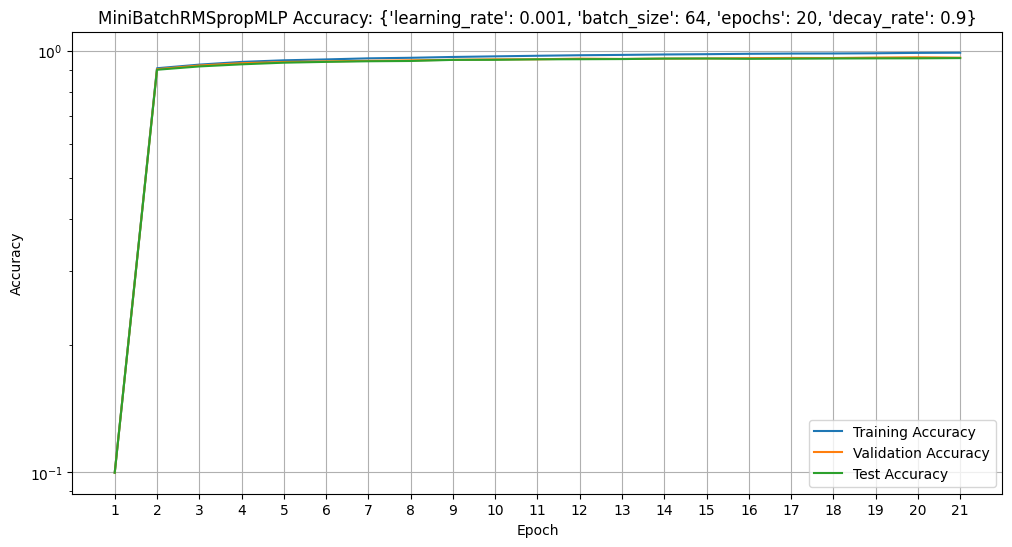

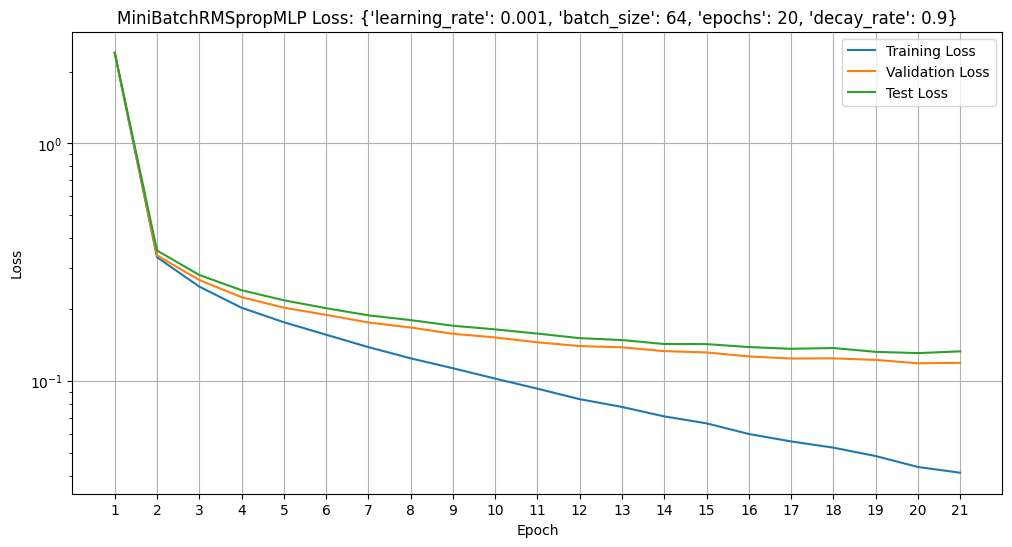

In [45]:
epochs_range_rmsprop = range(1, len(best_rmsprop_results['train_acc_hist']) + 1)
plt.figure(figsize=(12, 6))
plt.plot(epochs_range_rmsprop, best_rmsprop_results['train_acc_hist'], label='Training Accuracy')
plt.plot(epochs_range_rmsprop, best_rmsprop_results['val_acc_hist'], label='Validation Accuracy')
plt.plot(epochs_range_rmsprop, best_rmsprop_results['test_acc_hist'], label='Test Accuracy')
plt.title(f"MiniBatchRMSpropMLP Accuracy: {best_rmsprop_results['params']}")
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.yscale('log')
plt.xticks(np.arange(min(epochs_range_rmsprop), max(epochs_range_rmsprop) + 1, 1))
plt.show()


plt.figure(figsize=(12, 6))
plt.plot(epochs_range_rmsprop, best_rmsprop_results['train_loss_hist'], label='Training Loss')
plt.plot(epochs_range_rmsprop, best_rmsprop_results['val_loss_hist'], label='Validation Loss')
plt.plot(epochs_range_rmsprop, best_rmsprop_results['test_loss_hist'], label='Test Loss')
plt.title(f"MiniBatchRMSpropMLP Loss: {best_rmsprop_results['params']}")
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.yscale('log')
plt.xticks(np.arange(min(epochs_range_rmsprop), max(epochs_range_rmsprop) + 1, 1))
plt.show()

Analyzing MiniBatchRMSpropMLP Model with parameters: {'learning_rate': 0.001, 'batch_size': 64, 'epochs': 20, 'decay_rate': 0.9}


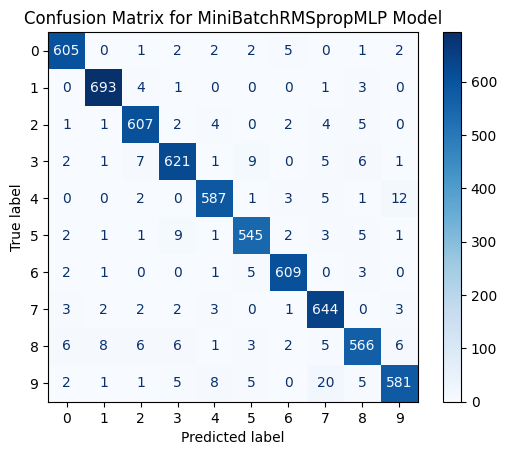

Number of misclassified images by MiniBatchRMSpropMLP: 242


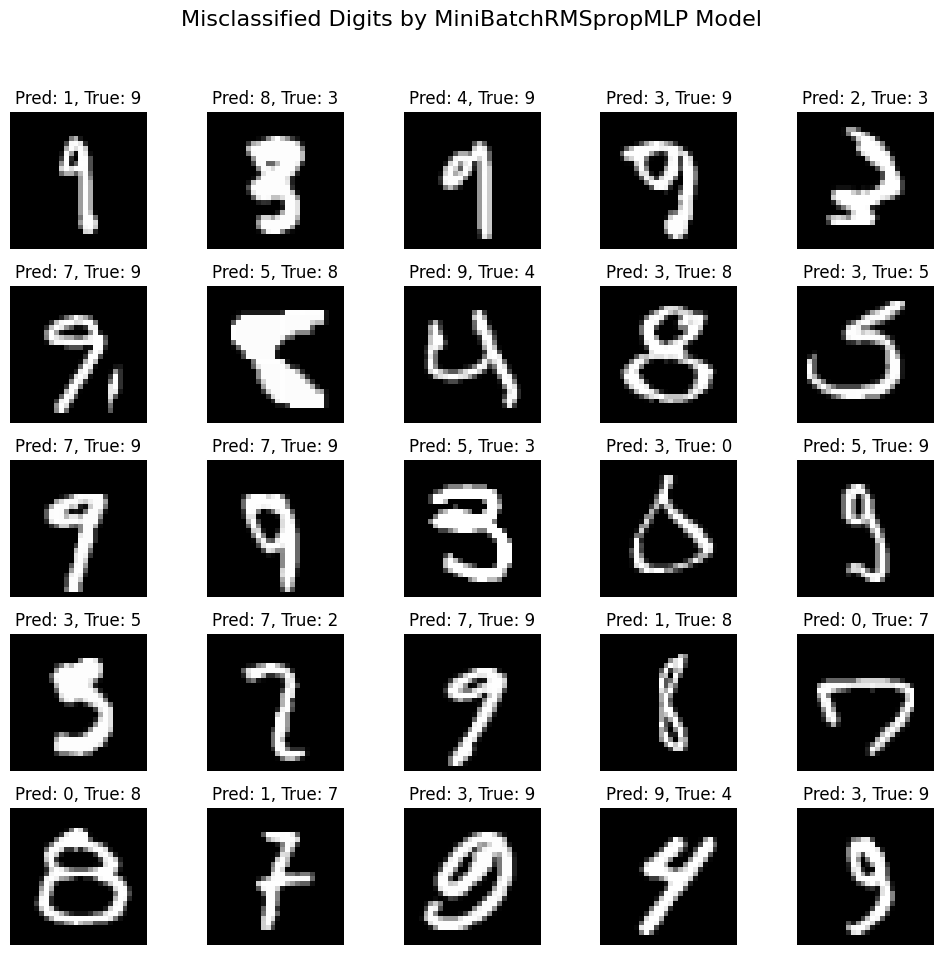

In [46]:
print(f"Analyzing MiniBatchRMSpropMLP Model with parameters: {best_rmsprop_results['params']}")
rmsprop_predictions = rmsprop_mlp.predict(x_test)

cm_rmsprop = confusion_matrix(y_test_labels, rmsprop_predictions)
disp_rmsprop = ConfusionMatrixDisplay(confusion_matrix=cm_rmsprop)
disp_rmsprop.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix for MiniBatchRMSpropMLP Model')
plt.show()

misclassified_indices_rmsprop = np.where(rmsprop_predictions != y_test_labels)[0]
print(f"Number of misclassified images by MiniBatchRMSpropMLP: {len(misclassified_indices_rmsprop)}")

plt.figure(figsize=(10, 10))
for i, bad_index in enumerate(misclassified_indices_rmsprop[:25]): # Display first 25 misclassified
    plt.subplot(5, 5, i + 1)
    plt.imshow(x_test[bad_index].reshape(28, 28), cmap='gray')
    plt.title(f"Pred: {rmsprop_predictions[bad_index]}, True: {y_test_labels[bad_index]}")
    plt.axis('off')
plt.suptitle('Misclassified Digits by MiniBatchRMSpropMLP Model', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [47]:
common_learning_rate = 0.01
common_epochs = 50
common_batch_size = 64

l2_lambda_compare = 0.01
dropout_rate_compare = 0.2
momentum_beta_compare = 0.9
rmsprop_decay_rate_compare = 0.9
rmsprop_epsilon_compare = 1e-8

all_models_results = {}


print("\n--- Retraining MiniBatchVanillaMLP ---")
minibatch_mlp_compare = MiniBatchVanillaMLP(input_size=x_train.shape[1], hidden_size=100, output_size=10, learning_rate=common_learning_rate, batch_size=common_batch_size)
minibatch_train_acc, minibatch_val_acc, minibatch_test_acc, minibatch_train_loss, minibatch_val_loss, minibatch_test_loss = minibatch_mlp_compare.train_with_history(
    x_train, y_train_one_hot, y_train_labels,
    x_val, y_val_one_hot, y_val_labels,
    x_test, y_test_one_hot, y_test_labels,
    epochs=common_epochs, patience=5, min_delta=0.0001
)
all_models_results['MiniBatchVanillaMLP'] = {
    'model': minibatch_mlp_compare,
    'params': {'learning_rate': common_learning_rate, 'batch_size': common_batch_size, 'epochs': common_epochs},
    'train_acc_hist': minibatch_train_acc,
    'val_acc_hist': minibatch_val_acc,
    'test_acc_hist': minibatch_test_acc,
    'train_loss_hist': minibatch_train_loss,
    'val_loss_hist': minibatch_val_loss,
    'test_loss_hist': minibatch_test_loss
}

print("\n--- Retraining MiniBatchL2RegularizedMLP ---")
l2_mlp_compare = MiniBatchL2RegularizedMLP(input_size=x_train.shape[1], hidden_size=100, output_size=10, learning_rate=common_learning_rate, batch_size=common_batch_size, l2_lambda=l2_lambda_compare)
l2_train_acc, l2_val_acc, l2_test_acc, l2_train_loss, l2_val_loss, l2_test_loss = l2_mlp_compare.train_with_history(
    x_train, y_train_one_hot, y_train_labels,
    x_val, y_val_one_hot, y_val_labels,
    x_test, y_test_one_hot, y_test_labels,
    epochs=common_epochs, patience=5, min_delta=0.0001
)
all_models_results['MiniBatchL2RegularizedMLP'] = {
    'model': l2_mlp_compare,
    'params': {'learning_rate': common_learning_rate, 'batch_size': common_batch_size, 'epochs': common_epochs, 'l2_lambda': l2_lambda_compare},
    'train_acc_hist': l2_train_acc,
    'val_acc_hist': l2_val_acc,
    'test_acc_hist': l2_test_acc,
    'train_loss_hist': l2_train_loss,
    'val_loss_hist': l2_val_loss,
    'test_loss_hist': l2_test_loss
}

print("\n--- Retraining MiniBatchDropoutMLP ---")
dropout_mlp_compare = MiniBatchDropoutMLP(input_size=x_train.shape[1], hidden_size=100, output_size=10, learning_rate=common_learning_rate, batch_size=common_batch_size, dropout_rate=dropout_rate_compare)
dropout_train_acc, dropout_val_acc, dropout_test_acc, dropout_train_loss, dropout_val_loss, dropout_test_loss = dropout_mlp_compare.train_with_history(
    x_train, y_train_one_hot, y_train_labels,
    x_val, y_val_one_hot, y_val_labels,
    x_test, y_test_one_hot, y_test_labels,
    epochs=common_epochs, patience=5, min_delta=0.0001
)
all_models_results['MiniBatchDropoutMLP'] = {
    'model': dropout_mlp_compare,
    'params': {'learning_rate': common_learning_rate, 'batch_size': common_batch_size, 'epochs': common_epochs, 'dropout_rate': dropout_rate_compare},
    'train_acc_hist': dropout_train_acc,
    'val_acc_hist': dropout_val_acc,
    'test_acc_hist': dropout_test_acc,
    'train_loss_hist': dropout_train_loss,
    'val_loss_hist': dropout_val_loss,
    'test_loss_hist': dropout_test_loss
}

print("\n--- Retraining MiniBatchMomentumMLP ---")
momentum_mlp_compare = MiniBatchMomentumMLP(input_size=x_train.shape[1], hidden_size=100, output_size=10, learning_rate=common_learning_rate, batch_size=common_batch_size, momentum_beta=momentum_beta_compare)
momentum_train_acc, momentum_val_acc, momentum_test_acc, momentum_train_loss, momentum_val_loss, momentum_test_loss = momentum_mlp_compare.train_with_history(
    x_train, y_train_one_hot, y_train_labels,
    x_val, y_val_one_hot, y_val_labels,
    x_test, y_test_one_hot, y_test_labels,
    epochs=common_epochs, patience=5, min_delta=0.0001
)
all_models_results['MiniBatchMomentumMLP'] = {
    'model': momentum_mlp_compare,
    'params': {'learning_rate': common_learning_rate, 'batch_size': common_batch_size, 'epochs': common_epochs, 'momentum_beta': momentum_beta_compare},
    'train_acc_hist': momentum_train_acc,
    'val_acc_hist': momentum_val_acc,
    'test_acc_hist': momentum_test_acc,
    'train_loss_hist': momentum_train_loss,
    'val_loss_hist': momentum_val_loss,
    'test_loss_hist': momentum_test_loss
}

print("\n--- Retraining MiniBatchRMSpropMLP ---")
rmsprop_mlp_compare = MiniBatchRMSpropMLP(input_size=x_train.shape[1], hidden_size=100, output_size=10, learning_rate=common_learning_rate, batch_size=common_batch_size, decay_rate=rmsprop_decay_rate_compare, epsilon=rmsprop_epsilon_compare)
rmsprop_train_acc, rmsprop_val_acc, rmsprop_test_acc, rmsprop_train_loss, rmsprop_val_loss, rmsprop_test_loss = rmsprop_mlp_compare.train_with_history(
    x_train, y_train_one_hot, y_train_labels,
    x_val, y_val_one_hot, y_val_labels,
    x_test, y_test_one_hot, y_test_labels,
    epochs=common_epochs, patience=10, min_delta=0.0001
)
all_models_results['MiniBatchRMSpropMLP'] = {
    'model': rmsprop_mlp_compare,
    'params': {'learning_rate': common_learning_rate, 'batch_size': common_batch_size, 'epochs': common_epochs, 'decay_rate': rmsprop_decay_rate_compare, 'epsilon': rmsprop_epsilon_compare},
    'train_acc_hist': rmsprop_train_acc,
    'val_acc_hist': rmsprop_val_acc,
    'test_acc_hist': rmsprop_test_acc,
    'train_loss_hist': rmsprop_train_loss,
    'val_loss_hist': rmsprop_val_loss,
    'test_loss_hist': rmsprop_test_loss
}


--- Retraining MiniBatchVanillaMLP ---
Initial (Epoch 0) Acc: 9.98% | Val Acc: 9.97% | Test Acc: 9.97% | Train Loss: 2.4041 | Val Loss: 2.4042 | Test Loss: 2.4033

Epoch 1/50
Train Acc: 63.11% | Val Acc: 63.43% | Test Acc: 63.10% | Train Loss: 1.9688 | Val Loss: 1.9681 | Test Loss: 1.9688

Epoch 2/50
Train Acc: 73.72% | Val Acc: 74.52% | Test Acc: 73.17% | Train Loss: 1.6042 | Val Loss: 1.6028 | Test Loss: 1.6050

Epoch 3/50
Train Acc: 78.01% | Val Acc: 78.49% | Test Acc: 78.03% | Train Loss: 1.2830 | Val Loss: 1.2809 | Test Loss: 1.2851

Epoch 4/50
Train Acc: 81.34% | Val Acc: 81.67% | Test Acc: 81.17% | Train Loss: 1.0522 | Val Loss: 1.0496 | Test Loss: 1.0564

Epoch 5/50
Train Acc: 82.93% | Val Acc: 83.27% | Test Acc: 82.46% | Train Loss: 0.8943 | Val Loss: 0.8914 | Test Loss: 0.9005

Epoch 6/50
Train Acc: 84.06% | Val Acc: 84.30% | Test Acc: 83.70% | Train Loss: 0.7851 | Val Loss: 0.7818 | Test Loss: 0.7932

Epoch 7/50
Train Acc: 84.81% | Val Acc: 85.00% | Test Acc: 84.33% | Train

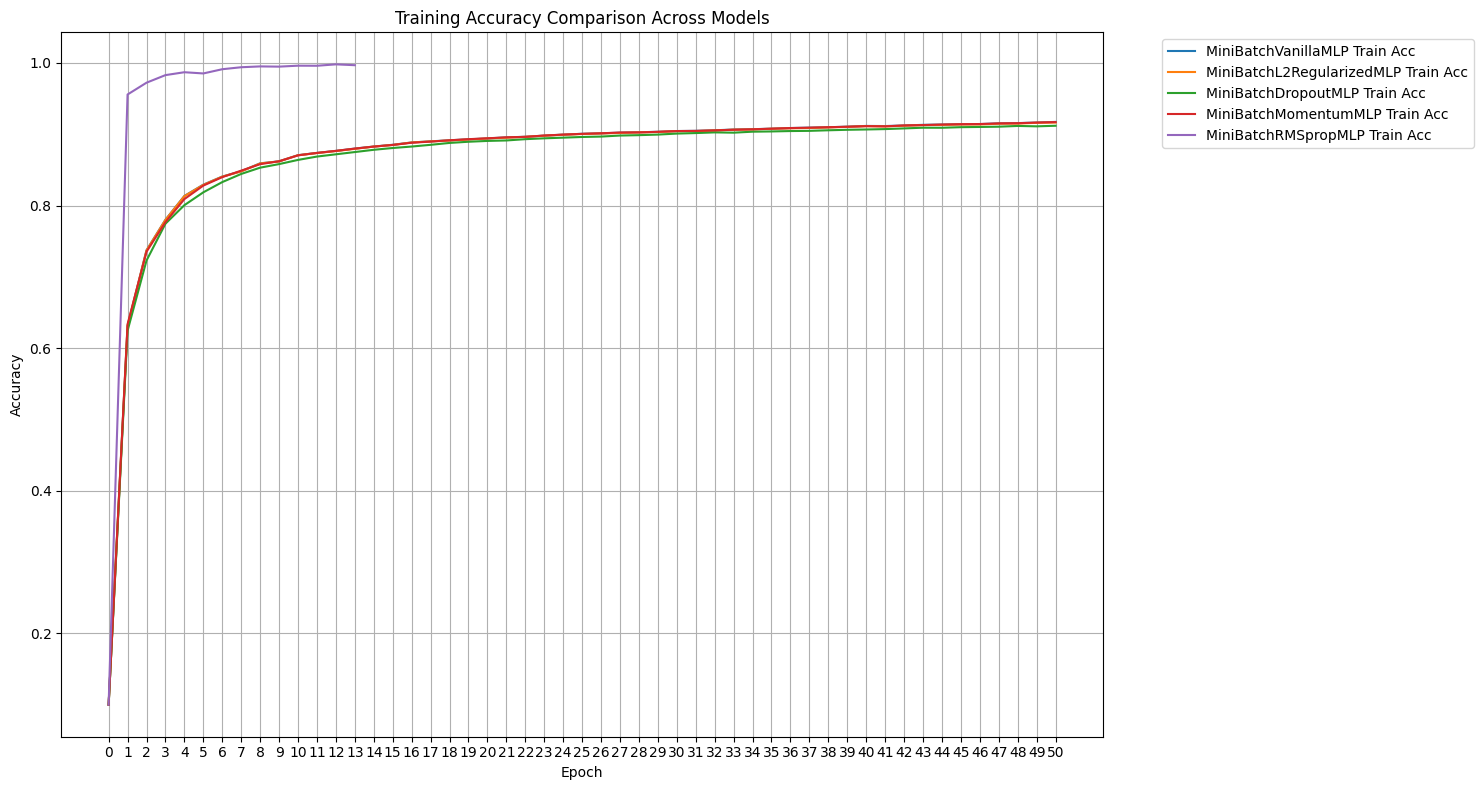

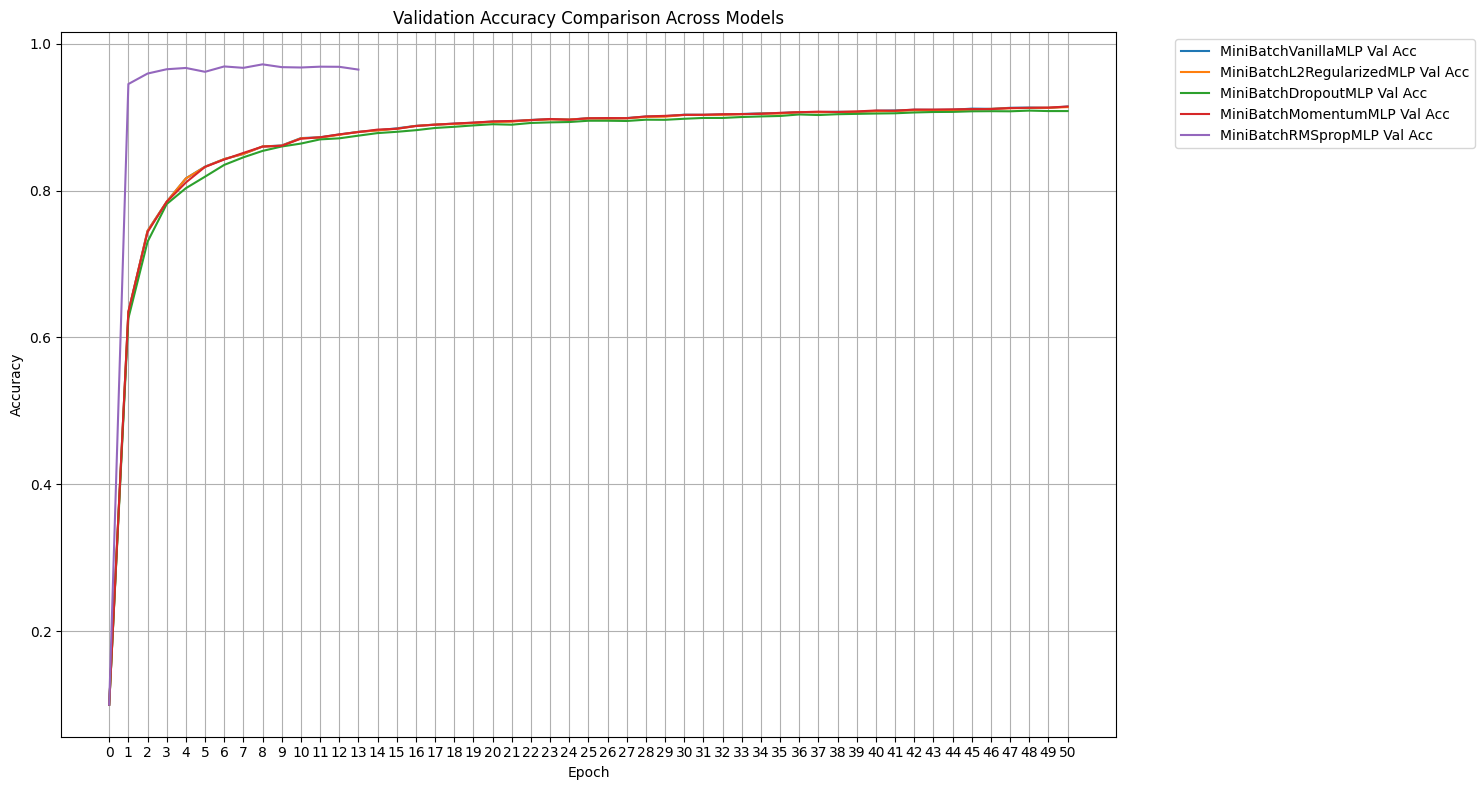

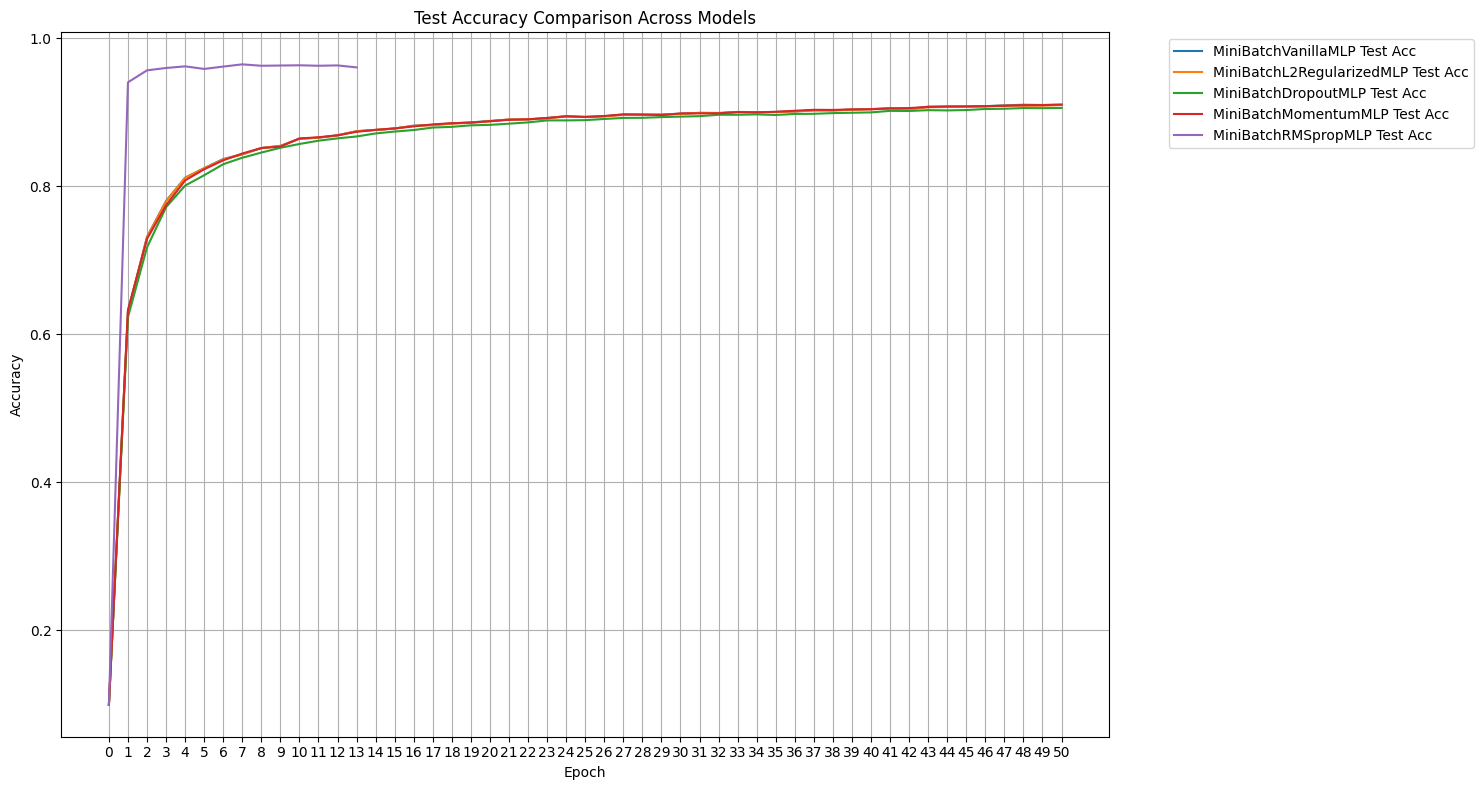

In [48]:
plt.figure(figsize=(15, 8))
for model_name, results in all_models_results.items():
    epochs_range = range(len(results['train_acc_hist']))
    plt.plot(epochs_range, results['train_acc_hist'], label=f'{model_name} Train Acc')
plt.title('Training Accuracy Comparison Across Models')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
#plt.yscale('log')
if common_epochs > 0:
    plt.xticks(np.arange(0, common_epochs + 1, 1))
plt.tight_layout()
plt.show()

plt.figure(figsize=(15, 8))
for model_name, results in all_models_results.items():
    epochs_range = range(len(results['val_acc_hist']))
    plt.plot(epochs_range, results['val_acc_hist'], label=f'{model_name} Val Acc')
plt.title('Validation Accuracy Comparison Across Models')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
#plt.yscale('log')
if common_epochs > 0:
    plt.xticks(np.arange(0, common_epochs + 1, 1))
plt.tight_layout()
plt.show()

plt.figure(figsize=(15, 8))
for model_name, results in all_models_results.items():
    epochs_range = range(len(results['test_acc_hist']))
    plt.plot(epochs_range, results['test_acc_hist'], label=f'{model_name} Test Acc')
plt.title('Test Accuracy Comparison Across Models')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
#plt.yscale('log')
if common_epochs > 0:
    plt.xticks(np.arange(0, common_epochs + 1, 1))
plt.tight_layout()
plt.show()

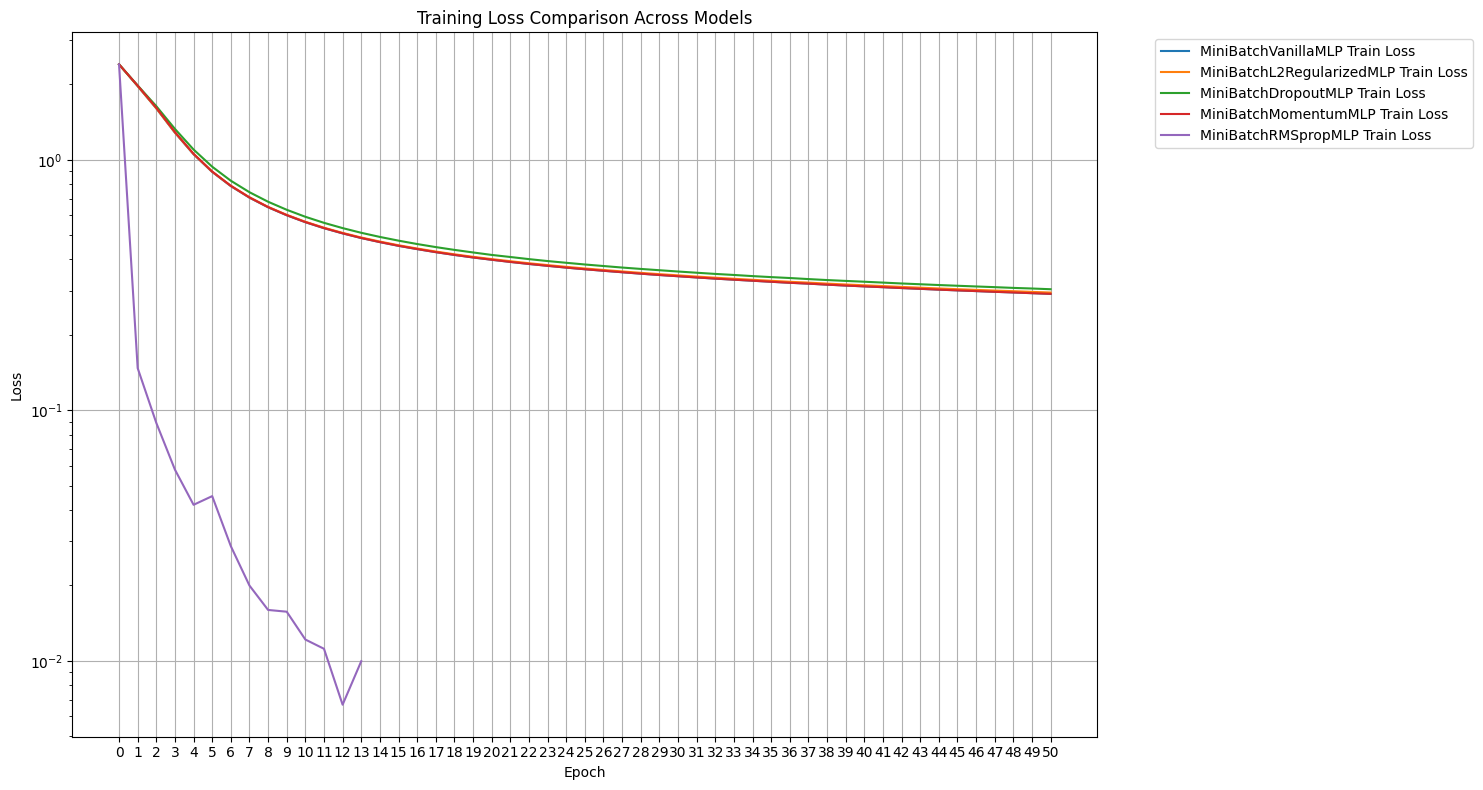

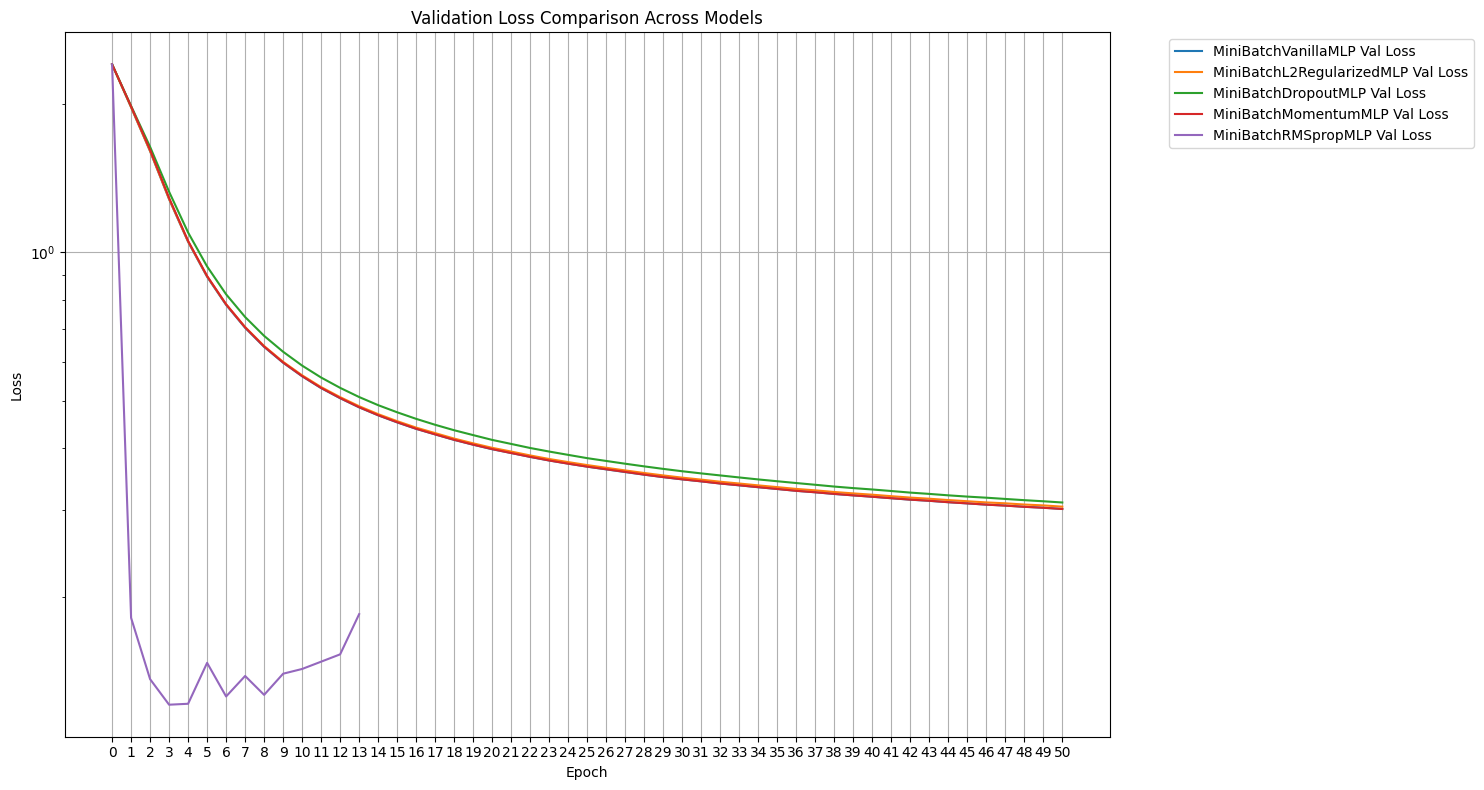

In [49]:
plt.figure(figsize=(15, 8))
for model_name, results in all_models_results.items():
    epochs_range = range(len(results['train_loss_hist']))
    plt.plot(epochs_range, results['train_loss_hist'], label=f'{model_name} Train Loss')
plt.title('Training Loss Comparison Across Models')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.yscale('log')
if common_epochs > 0:
    plt.xticks(np.arange(0, common_epochs + 1, 1))
plt.tight_layout()
plt.show()

plt.figure(figsize=(15, 8))
for model_name, results in all_models_results.items():
    epochs_range = range(len(results['val_loss_hist']))
    plt.plot(epochs_range, results['val_loss_hist'], label=f'{model_name} Val Loss')
plt.title('Validation Loss Comparison Across Models')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.yscale('log')
if common_epochs > 0:
    plt.xticks(np.arange(0, common_epochs + 1, 1))
plt.tight_layout()
plt.show()


--- Analyzing MiniBatchVanillaMLP Model ---


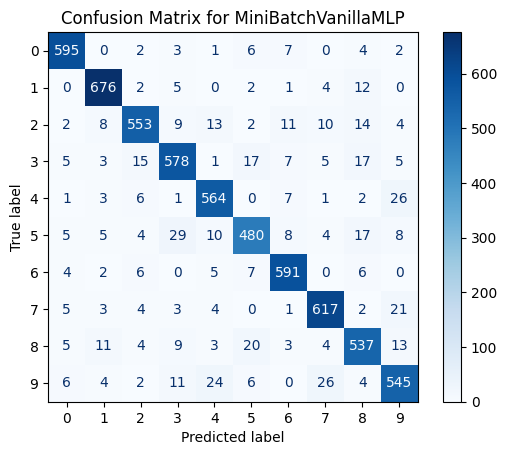

Number of misclassified images by MiniBatchVanillaMLP: 564


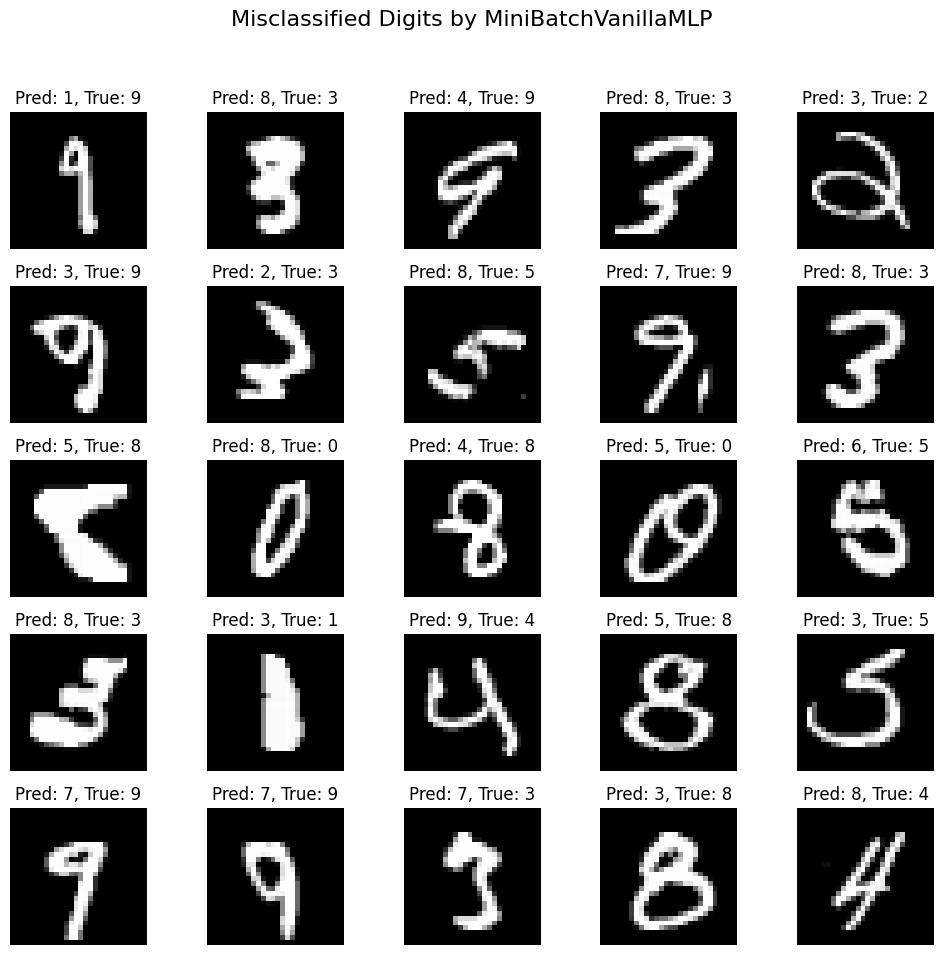


--- Analyzing MiniBatchL2RegularizedMLP Model ---


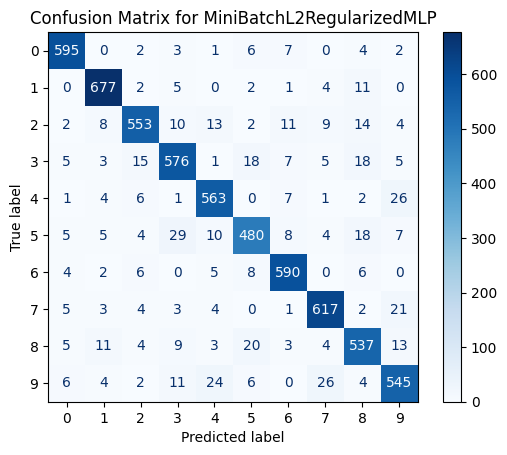

Number of misclassified images by MiniBatchL2RegularizedMLP: 567


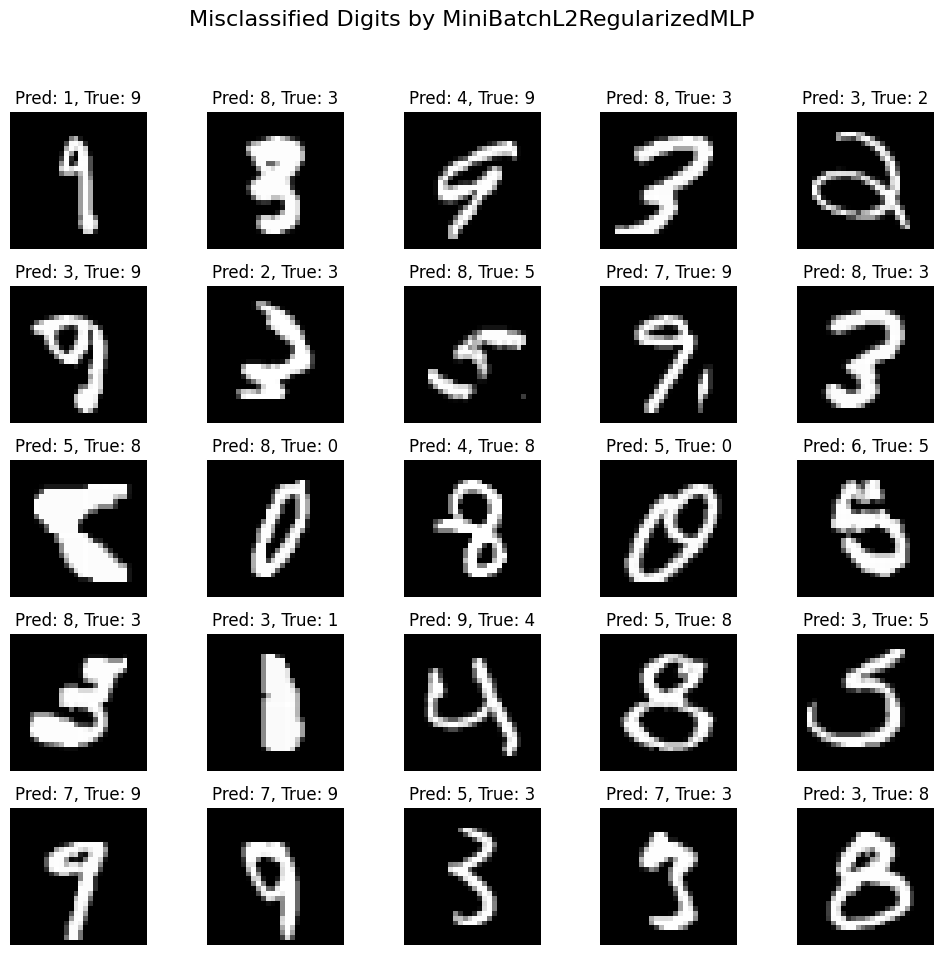


--- Analyzing MiniBatchDropoutMLP Model ---


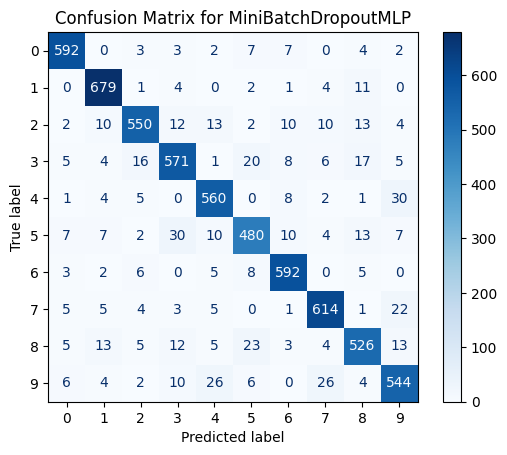

Number of misclassified images by MiniBatchDropoutMLP: 592


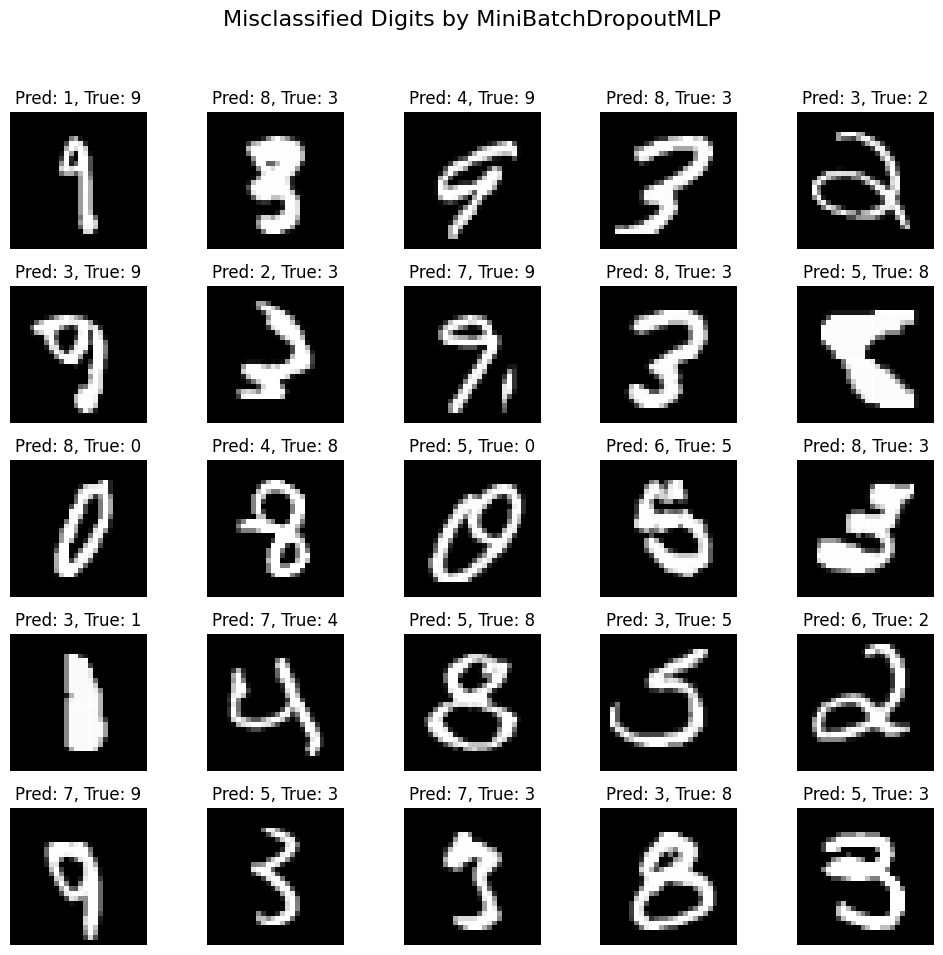


--- Analyzing MiniBatchMomentumMLP Model ---


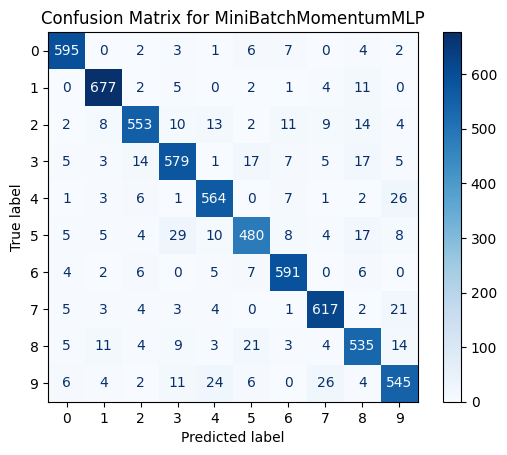

Number of misclassified images by MiniBatchMomentumMLP: 564


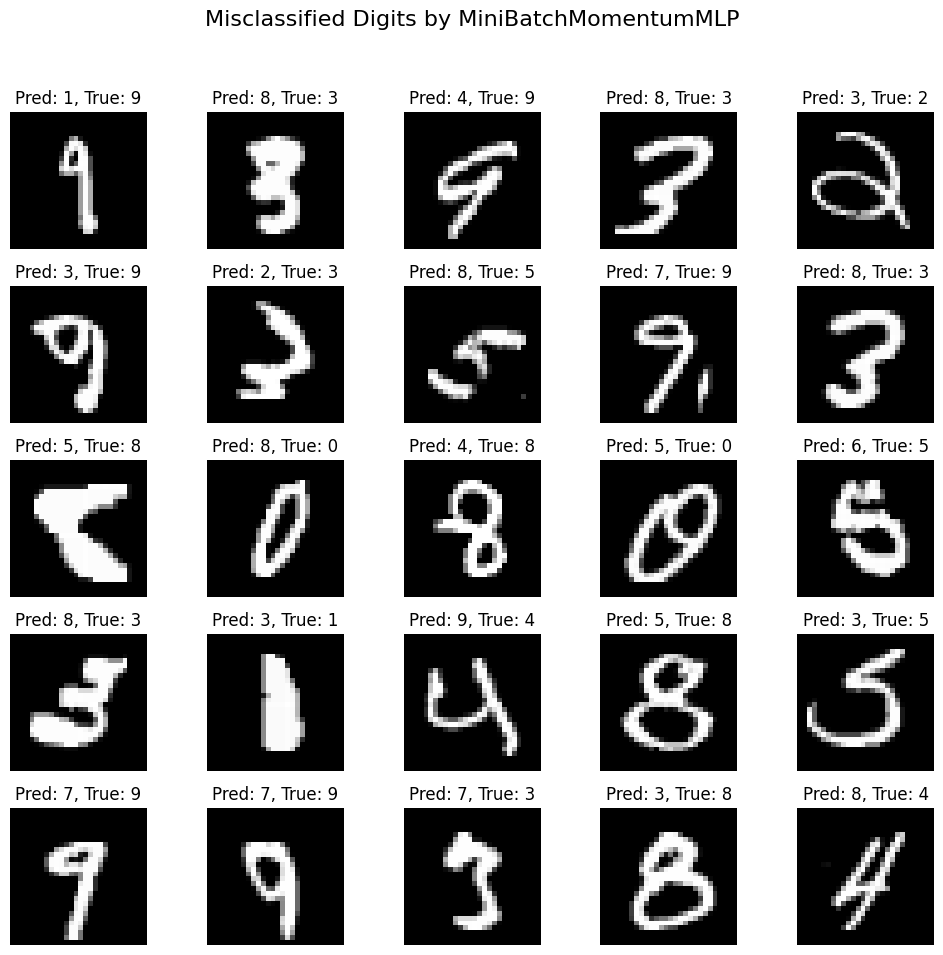


--- Analyzing MiniBatchRMSpropMLP Model ---


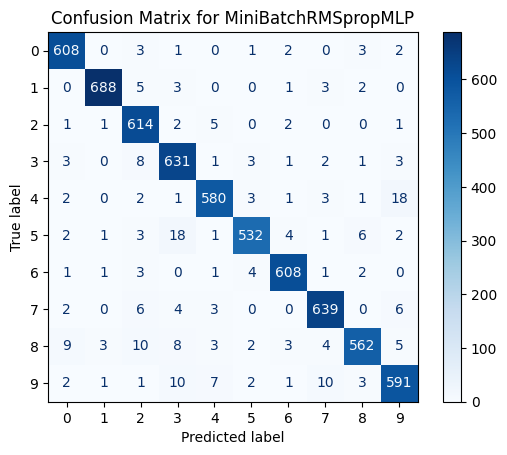

Number of misclassified images by MiniBatchRMSpropMLP: 247


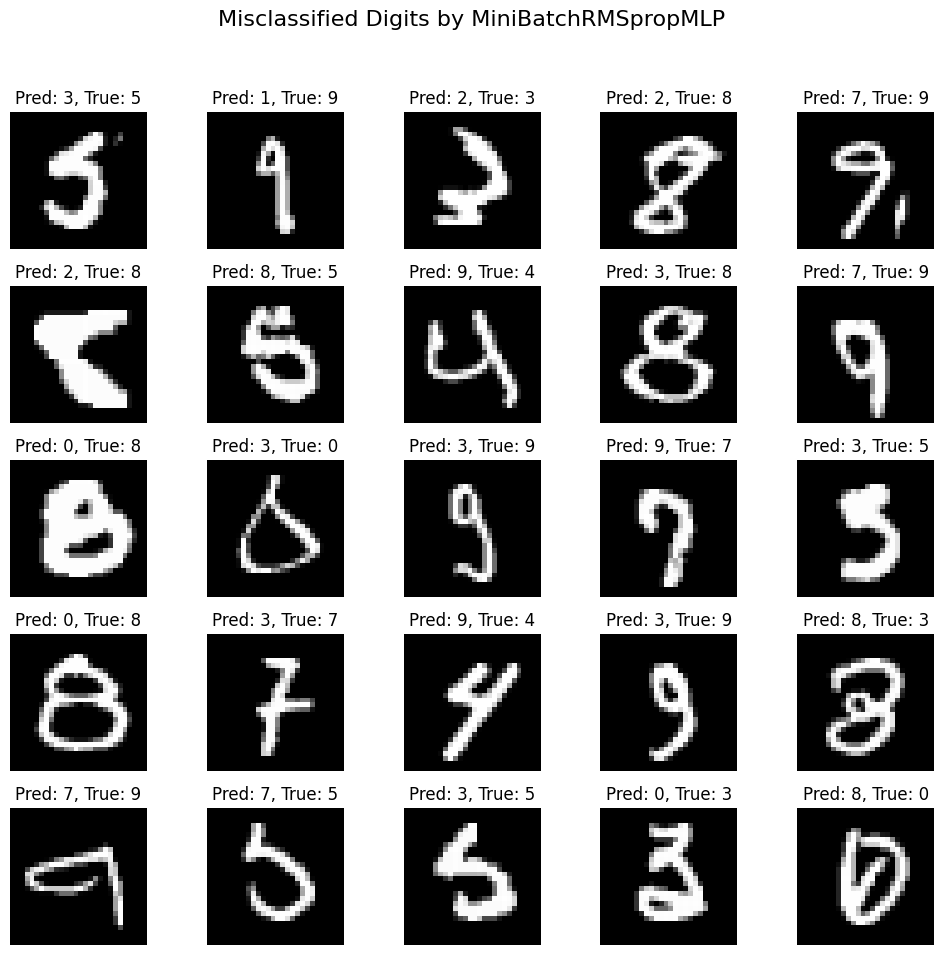

In [50]:
for model_name, results in all_models_results.items():
    print(f"\n--- Analyzing {model_name} Model ---")
    model_instance = results['model']
    predictions = model_instance.predict(x_test)

    cm = confusion_matrix(y_test_labels, predictions)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(f'Confusion Matrix for {model_name}')
    plt.show()

    misclassified_indices = np.where(predictions != y_test_labels)[0]
    print(f"Number of misclassified images by {model_name}: {len(misclassified_indices)}")

    plt.figure(figsize=(10, 10))
    for i, bad_index in enumerate(misclassified_indices[:25]): # Display first 25 misclassified
        plt.subplot(5, 5, i + 1)
        plt.imshow(x_test[bad_index].reshape(28, 28), cmap='gray')
        plt.title(f"Pred: {predictions[bad_index]}, True: {y_test_labels[bad_index]}")
        plt.axis('off')
    plt.suptitle(f'Misclassified Digits by {model_name}', fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

In [51]:
class MiniBatchDataAugmentationMLP(MiniBatchVanillaMLP):
    def __init__(self, input_size, hidden_size, output_size, learning_rate, batch_size, augmentation_params=None):
        super().__init__(input_size, hidden_size, output_size, learning_rate, batch_size)

        if augmentation_params is None:
            augmentation_params = {
                'rotation_range': 10,
                'width_shift_range': 0.1,
                'height_shift_range': 0.1,
                'zoom_range': 0.1,
                'horizontal_flip': False,
                'vertical_flip': False
            }
        self.datagen = ImageDataGenerator(**augmentation_params)

    def train(self, X, y):
        # X -> samples, height, width, channels for ImageDataGenerator
        X_reshaped = X.reshape(-1, 28, 28, 1)

        # flow method to generate augmented batches

        num_batches = X.shape[0] // self.batch_size
        data_generator = self.datagen.flow(
            X_reshaped,
            y,
            batch_size=self.batch_size,
            shuffle=True
        )

        for i, (batch_X_reshaped, batch_y_one_hot) in enumerate(data_generator):
            if i >= num_batches:
                break

            batch_X = batch_X_reshaped.reshape(batch_X_reshaped.shape[0], -1) # flatten augmented images

            A2, cache = self.forward(batch_X)
            gradients = self.backward(batch_X, batch_y_one_hot, cache) 
            self.update_parameters(gradients)


    def train_with_history(self, X_train, y_train_one_hot, y_train_labels, X_val, y_val_one_hot, y_val_labels, X_test, y_test_one_hot, y_test_labels, epochs, patience=10, min_delta=0.0001):
        train_acc_history = []
        val_acc_history = []
        test_acc_history = []

        train_loss_history = []
        val_loss_history = []
        test_loss_history = []

        best_val_loss = float('inf')
        patience_counter = 0

        train_acc_0 = self.evaluate(X_train, y_train_labels)
        val_acc_0 = self.evaluate(X_val, y_val_labels)
        test_acc_0 = self.evaluate(X_test, y_test_labels)

        A2_train_0, _ = self.forward(X_train)
        A2_val_0, _ = self.forward(X_val)
        A2_test_0, _ = self.forward(X_test)

        train_loss_0 = cross_entropy(A2_train_0, y_train_labels)
        val_loss_0 = cross_entropy(A2_val_0, y_val_labels)
        test_loss_0 = cross_entropy(A2_test_0, y_test_labels)

        train_acc_history.append(train_acc_0)
        val_acc_history.append(val_acc_0)
        test_acc_history.append(test_acc_0)
        train_loss_history.append(train_loss_0)
        val_loss_history.append(val_loss_0)
        test_loss_history.append(test_loss_0)

        print(
            f"Initial (Epoch 0) Acc: {train_acc_0*100:.2f}% | "
            f"Val Acc: {val_acc_0*100:.2f}% | "
            f"Test Acc: {test_acc_0*100:.2f}% | "
            f"Train Loss: {train_loss_0:.4f} | "
            f"Val Loss: {val_loss_0:.4f} | "
            f"Test Loss: {test_loss_0:.4f}"
        )

        for epoch in range(epochs):
            print(f"\nEpoch {epoch+1}/{epochs}")
            self.train(X_train, y_train_one_hot) 

            train_acc = self.evaluate(X_train, y_train_labels)
            val_acc = self.evaluate(X_val, y_val_labels)
            test_acc = self.evaluate(X_test, y_test_labels)

            A2_train, _ = self.forward(X_train)
            A2_val, _ = self.forward(X_val)
            A2_test, _ = self.forward(X_test)

            train_loss = cross_entropy(A2_train, y_train_labels)
            val_loss = cross_entropy(A2_val, y_val_labels)
            test_loss = cross_entropy(A2_test, y_test_labels)

            train_acc_history.append(train_acc)
            val_acc_history.append(val_acc)
            test_acc_history.append(test_loss)

            train_loss_history.append(train_loss)
            val_loss_history.append(val_loss)
            test_loss_history.append(test_loss)

            print(
                 f"Train Acc: {train_acc*100:.2f}% | "
                 f"Val Acc: {val_acc*100:.2f}% | "
                 f"Test Acc: {test_acc*100:.2f}% | "
                 f"Train Loss: {train_loss:.4f} | "
                 f"Val Loss: {val_loss:.4f} | "
                 f"Test Loss: {test_loss:.4f}"
            )

            if val_loss < best_val_loss - min_delta:
                best_val_loss = val_loss
                patience_counter = 0
            else:
                patience_counter += 1
                if patience_counter >= patience:
                    print(f"Early stopping at epoch {epoch+1} as validation loss did not improve for {patience} epochs.")
                    break 

        return (train_acc_history, val_acc_history, test_acc_history, train_loss_history, val_loss_history, test_loss_history)

In [52]:
def generate_augmented_dataset(X_data, y_data_one_hot, datagen, num_augmentations_per_sample=1):

    X_reshaped = X_data.reshape(-1, 28, 28, 1)

    augmented_images = []
    augmented_labels = []

    # generate augmented images for each original image
    for i in range(X_reshaped.shape[0]):
        # add original image and label
        augmented_images.append(X_data[i])
        augmented_labels.append(y_data_one_hot[i])

        # generate num_augmentations_per_sample for each original image
        img = X_reshaped[i:i+1] # Need to pass a batch of size 1
        label = y_data_one_hot[i:i+1]

        for _ in range(num_augmentations_per_sample):
            # flow() returns an iterator of augmented batches
            gen_iter = datagen.flow(img, label, batch_size=1, shuffle=False)
            aug_img_batch, aug_label_batch = next(gen_iter)

            # flatten the augmented image and append
            augmented_images.append(aug_img_batch[0].flatten())
            augmented_labels.append(aug_label_batch[0])

    return np.array(augmented_images), np.array(augmented_labels)

In [53]:
# define augmentation parameters
augmentation_params_preprocessing = {
    'rotation_range': 10,
    'width_shift_range': 0.1,
    'height_shift_range': 0.1,
    'zoom_range': 0.1,
    'horizontal_flip': False,
    'vertical_flip': False
}

datagen_preprocessing = ImageDataGenerator(**augmentation_params_preprocessing)

# 2 augment for each original 
num_augmentations = 2
x_train_aug, y_train_one_hot_aug = generate_augmented_dataset(x_train, y_train_one_hot, datagen_preprocessing, num_augmentations_per_sample=num_augmentations)

# create integer labels for the augmented set for cross_entropy calculation
y_train_labels_aug = np.argmax(y_train_one_hot_aug, axis=1)

print(f"Original training data shape: {x_train.shape}")
print(f"Augmented training data shape: {x_train_aug.shape}")
print(f"Original training labels shape: {y_train_one_hot.shape}")
print(f"Augmented training labels shape: {y_train_one_hot_aug.shape}")

Original training data shape: (29400, 784)
Augmented training data shape: (88200, 784)
Original training labels shape: (29400, 10)
Augmented training labels shape: (88200, 10)


In [54]:
learning_rate_preaug = 0.1
batch_size_preaug = 64
epochs_preaug = 20

preaug_mlp = MiniBatchVanillaMLP(input_size=x_train_aug.shape[1], hidden_size=100, output_size=10,
                                  learning_rate=learning_rate_preaug, batch_size=batch_size_preaug)

print(f"--- Training MiniBatchVanillaMLP with Pre-processed Data Augmentation (params: learning_rate={learning_rate_preaug}, batch_size={batch_size_preaug}, epochs={epochs_preaug}, num_augmentations_per_sample={num_augmentations}) ---")

preaug_train_acc_history, preaug_val_acc_history, preaug_test_acc_history, \
preaug_train_loss_history, preaug_val_loss_history, preaug_test_loss_history = preaug_mlp.train_with_history(
    x_train_aug, y_train_one_hot_aug, y_train_labels_aug, #use augum 
    x_val, y_val_one_hot, y_val_labels, # validation data original
    x_test, y_test_one_hot, y_test_labels, # test data original
    epochs=epochs_preaug, patience=5, min_delta=0.0001
)

best_preaug_results = {
    'params': {'learning_rate': learning_rate_preaug, 'batch_size': batch_size_preaug, 'epochs': epochs_preaug, 'num_augmentations_per_sample': num_augmentations},
    'train_acc_hist': preaug_train_acc_history,
    'val_acc_hist': preaug_val_acc_history,
    'test_acc_hist': preaug_test_acc_history,
    'train_loss_hist': preaug_train_loss_history,
    'val_loss_hist': preaug_val_loss_history,
    'test_loss_hist': preaug_test_loss_history
}

--- Training MiniBatchVanillaMLP with Pre-processed Data Augmentation (params: learning_rate=0.1, batch_size=64, epochs=20, num_augmentations_per_sample=2) ---
Initial (Epoch 0) Acc: 9.98% | Val Acc: 9.97% | Test Acc: 9.97% | Train Loss: 2.4002 | Val Loss: 2.4042 | Test Loss: 2.4033

Epoch 1/20
Train Acc: 72.76% | Val Acc: 87.27% | Test Acc: 86.27% | Train Loss: 0.8852 | Val Loss: 0.4914 | Test Loss: 0.5083

Epoch 2/20
Train Acc: 77.42% | Val Acc: 89.89% | Test Acc: 88.98% | Train Loss: 0.7408 | Val Loss: 0.3906 | Test Loss: 0.4084

Epoch 3/20
Train Acc: 81.92% | Val Acc: 91.97% | Test Acc: 91.56% | Train Loss: 0.6071 | Val Loss: 0.3190 | Test Loss: 0.3333

Epoch 4/20
Train Acc: 85.33% | Val Acc: 93.13% | Test Acc: 92.97% | Train Loss: 0.5041 | Val Loss: 0.2710 | Test Loss: 0.2810

Epoch 5/20
Train Acc: 87.92% | Val Acc: 94.11% | Test Acc: 93.92% | Train Loss: 0.4187 | Val Loss: 0.2268 | Test Loss: 0.2354

Epoch 6/20
Train Acc: 89.66% | Val Acc: 94.73% | Test Acc: 94.71% | Train Loss: 

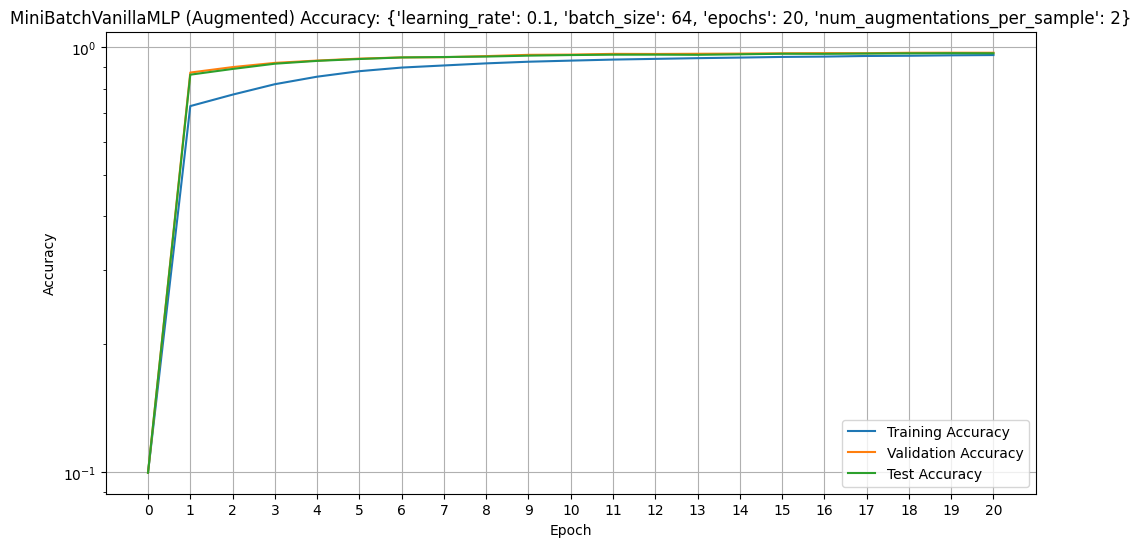

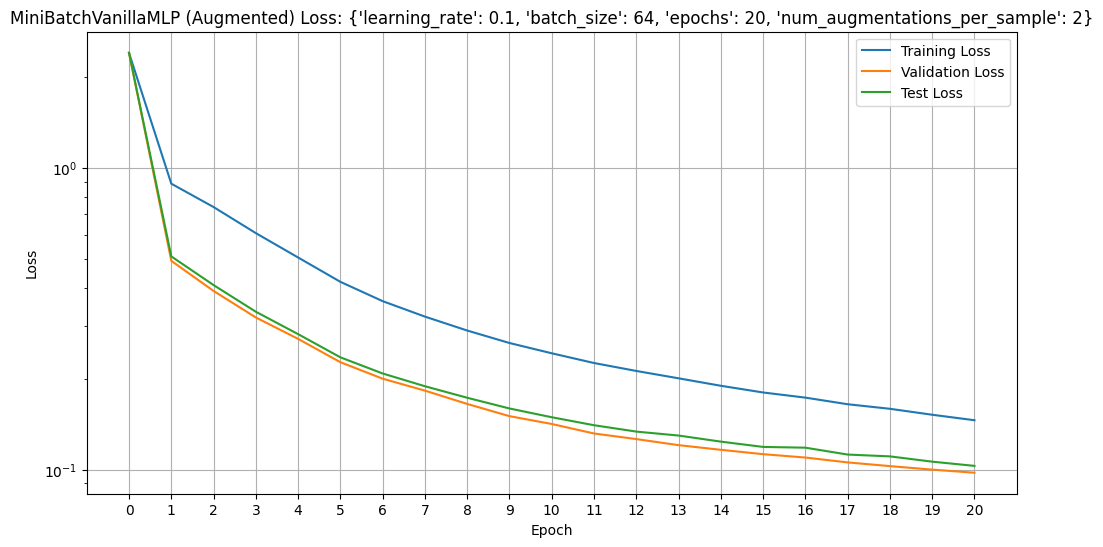

In [55]:
epochs_range_preaug = range(len(best_preaug_results['train_acc_hist']))
plt.figure(figsize=(12, 6))
plt.plot(epochs_range_preaug, best_preaug_results['train_acc_hist'], label='Training Accuracy')
plt.plot(epochs_range_preaug, best_preaug_results['val_acc_hist'], label='Validation Accuracy')
plt.plot(epochs_range_preaug, best_preaug_results['test_acc_hist'], label='Test Accuracy')
plt.title(f"MiniBatchVanillaMLP (Augmented) Accuracy: {best_preaug_results['params']}")
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.yscale('log')
if len(epochs_range_preaug) > 0:
    plt.xticks(np.arange(0, max(epochs_range_preaug) + 1, 1))
plt.show()


plt.figure(figsize=(12, 6))
plt.plot(epochs_range_preaug, best_preaug_results['train_loss_hist'], label='Training Loss')
plt.plot(epochs_range_preaug, best_preaug_results['val_loss_hist'], label='Validation Loss')
plt.plot(epochs_range_preaug, best_preaug_results['test_loss_hist'], label='Test Loss')
plt.title(f"MiniBatchVanillaMLP (Augmented) Loss: {best_preaug_results['params']}")
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.yscale('log')
if len(epochs_range_preaug) > 0:
    plt.xticks(np.arange(0, max(epochs_range_preaug) + 1, 1))
plt.show()

Analyzing MiniBatchVanillaMLP (Augmented) Model with parameters: {'learning_rate': 0.1, 'batch_size': 64, 'epochs': 20, 'num_augmentations_per_sample': 2}


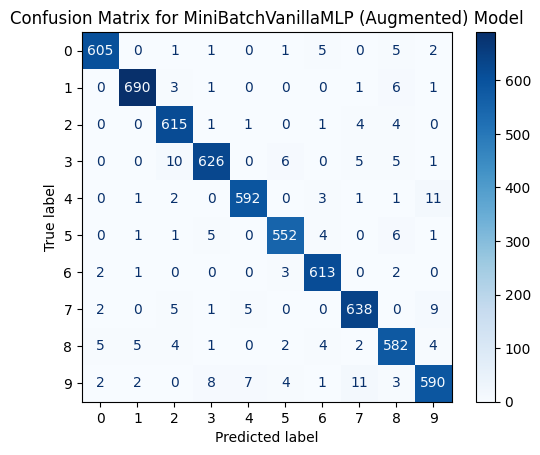

Number of misclassified images by MiniBatchVanillaMLP (Augmented): 197


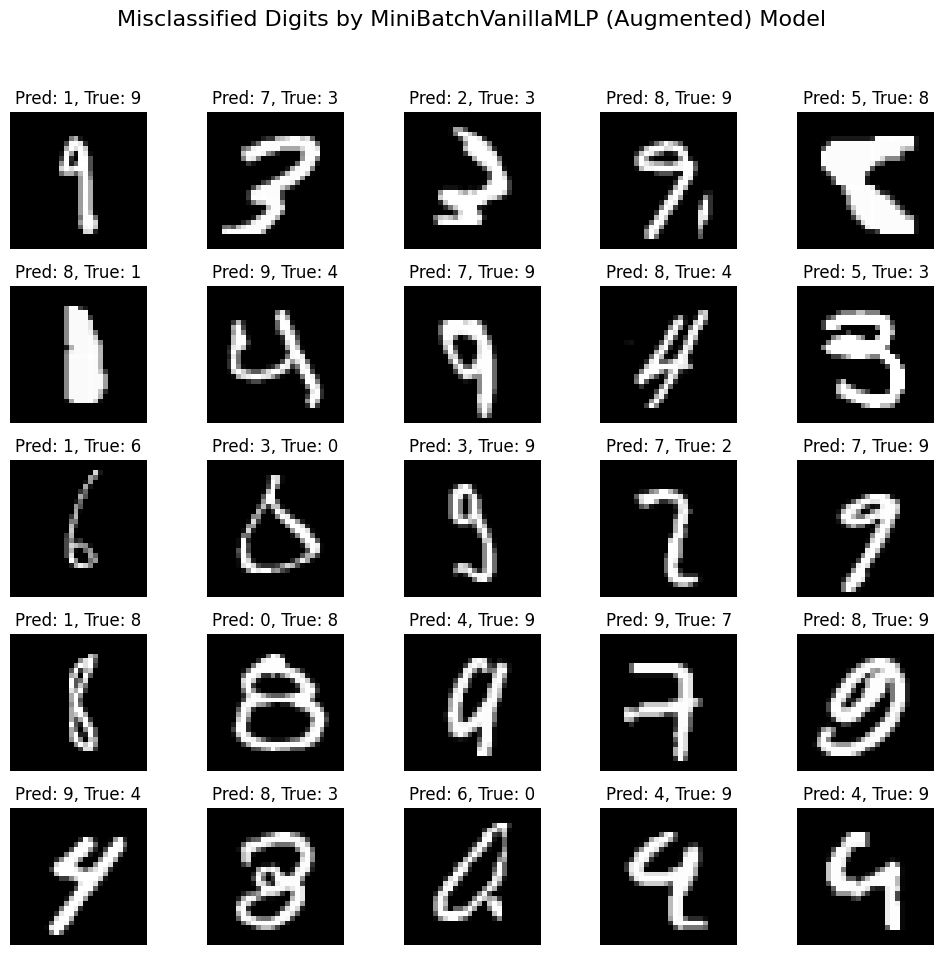

In [56]:
print(f"Analyzing MiniBatchVanillaMLP (Augmented) Model with parameters: {best_preaug_results['params']}")
preaug_predictions = preaug_mlp.predict(x_test)

cm_preaug = confusion_matrix(y_test_labels, preaug_predictions)
disp_preaug = ConfusionMatrixDisplay(confusion_matrix=cm_preaug)
disp_preaug.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix for MiniBatchVanillaMLP (Augmented) Model')
plt.show()

misclassified_indices_preaug = np.where(preaug_predictions != y_test_labels)[0]
print(f"Number of misclassified images by MiniBatchVanillaMLP (Augmented): {len(misclassified_indices_preaug)}")

plt.figure(figsize=(10, 10))
for i, bad_index in enumerate(misclassified_indices_preaug[:25]): # Display first 25 misclassified
    plt.subplot(5, 5, i + 1)
    plt.imshow(x_test[bad_index].reshape(28, 28), cmap='gray')
    plt.title(f"Pred: {preaug_predictions[bad_index]}, True: {y_test_labels[bad_index]}")
    plt.axis('off')
plt.suptitle('Misclassified Digits by MiniBatchVanillaMLP (Augmented) Model', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [57]:
class MiniBatchComprehensiveMLP(MiniBatchVanillaMLP):
    def __init__(self, input_size, hidden_size, output_size, learning_rate, batch_size,
                 l2_lambda=0.01, dropout_rate=0.5, momentum_beta=0.9, decay_rate=0.9, epsilon=1e-8, augmentation_config=None):
        super().__init__(input_size, hidden_size, output_size, learning_rate, batch_size)

        self.l2_lambda = l2_lambda
        self.dropout_rate = dropout_rate
        self.momentum_beta = momentum_beta
        self.decay_rate = decay_rate
        self.epsilon = epsilon

        # Initialize augmentation settings
        self.augmentation_config = augmentation_config if augmentation_config is not None else {
            'apply_random_eraser': False,
            'apply_random_cutout': False,
            'edge_detector_type': 'none',
            'blur_type': 'none',
            'rotation_range': 0,
            'width_shift_range': 0.0,
            'height_shift_range': 0.0,
            'zoom_range': 0.0,
            'horizontal_flip': False,
            'vertical_flip': False,
            'fill_mode': 'nearest'
        }

        # Initialize ImageDataGenerator with custom preprocessing
        self.datagen = ImageDataGenerator(
            rotation_range=self.augmentation_config.get('rotation_range', 0),
            width_shift_range=self.augmentation_config.get('width_shift_range', 0.0),
            height_shift_range=self.augmentation_config.get('height_shift_range', 0.0),
            zoom_range=self.augmentation_config.get('zoom_range', 0.0),
            horizontal_flip=self.augmentation_config.get('horizontal_flip', False),
            vertical_flip=self.augmentation_config.get('vertical_flip', False),
            fill_mode=self.augmentation_config.get('fill_mode', 'nearest'),
            preprocessing_function=self._preprocessing_wrapper # Our custom augmentations go here
        )

        # initialize velocities for Momentum
        self.v_W1 = np.zeros_like(self.W1)
        self.v_b1 = np.zeros_like(self.b1)
        self.v_W2 = np.zeros_like(self.W2)
        self.v_b2 = np.zeros_like(self.b2)

        # initialize squared gradient accumulators for RMSprop
        self.s_W1 = np.zeros_like(self.W1)
        self.s_b1 = np.zeros_like(self.b1)
        self.s_W2 = np.zeros_like(self.W2)
        self.s_b2 = np.zeros_like(self.b2)

    def _preprocessing_wrapper(self, image_array):
        """
        Wrapper for custom_augmentation_pipeline to fit ImageDataGenerator's API.
        ImageDataGenerator passes a 3D image array (H, W, C).
        Our custom pipeline expects (784,) and returns (784,).
        """
        # Convert (H, W, C) to (H, W), apply custom augmentations, then reshape back to (H, W, C)
        # Note: self.datagen performs other augmentations AFTER this preprocessing_function
        processed_flat = custom_augmentation_pipeline(image_array.flatten(), self.augmentation_config)
        return processed_flat.reshape(28, 28, 1)

    def forward(self, X, training=True):
        Z1 = np.dot(X, self.W1) + self.b1
        A1 = sigmoid(Z1)

        D1 = None
        if training:
            D1 = (np.random.rand(*A1.shape) > self.dropout_rate).astype(float)
            A1 *= D1
            A1 /= (1 - self.dropout_rate)

        Z2 = np.dot(A1, self.W2) + self.b2
        A2 = softmax(Z2)

        cache = {
            "Z1": Z1,
            "A1": A1,
            "Z2": Z2,
            "A2": A2,
            "D1": D1
        }
        return A2, cache

    def predict(self, X):
        A2, _ = self.forward(X, training=False)
        predictions = np.argmax(A2, axis=1)
        return predictions

    def calculate_regularized_loss(self, predicted, actual_labels):
        m = actual_labels.shape[0]
        ce_loss = cross_entropy(predicted, actual_labels)
        l2_reg_term = (np.sum(np.square(self.W1)) + np.sum(np.square(self.W2))) * (self.l2_lambda / (2 * m))
        return ce_loss + l2_reg_term

    def backward(self, X, y_true, cache):
        m = X.shape[0]
        A1 = cache["A1"]
        D1 = cache["D1"]
        A2 = cache["A2"]

        dZ2 = A2 - y_true
        dW2 = np.dot(A1.T, dZ2) / m + (self.l2_lambda / m) * self.W2 # L2 gradient
        db2 = np.sum(dZ2, axis=0, keepdims=True) / m


        dA1 = np.dot(dZ2, self.W2.T)
        if D1 is not None:
            dA1 *= D1
            dA1 /= (1 - self.dropout_rate)

        dZ1 = (dA1 * sigmoid_derivative(cache["Z1"]))
        dW1 = np.dot(X.T, dZ1) / m + (self.l2_lambda / m) * self.W1 # L2 gradient
        db1 = np.sum(dZ1, axis=0, keepdims=True) / m

        gradients = {
            "dW1": dW1,
            "db1": db1,
            "dW2": dW2,
            "db2": db2
        }
        return gradients

    def update_parameters(self, gradients):
        # RMSprop updates combined with implicit L2 (from gradients)
        # update squared gradient accumulators
        self.s_W1 = self.decay_rate * self.s_W1 + (1 - self.decay_rate) * (gradients["dW1"] ** 2)
        self.s_b1 = self.decay_rate * self.s_b1 + (1 - self.decay_rate) * (gradients["db1"] ** 2)
        self.s_W2 = self.decay_rate * self.s_W2 + (1 - self.decay_rate) * (gradients["dW2"] ** 2)
        self.s_b2 = self.decay_rate * self.s_b2 + (1 - self.decay_rate) * (gradients["db2"] ** 2)

        # update velocities for Momentum
        self.v_W1 = self.momentum_beta * self.v_W1 + (1 - self.momentum_beta) * gradients["dW1"]
        self.v_b1 = self.momentum_beta * self.v_b1 + (1 - self.momentum_beta) * gradients["db1"]
        self.v_W2 = self.momentum_beta * self.v_W2 + (1 - self.momentum_beta) * gradients["dW2"]
        self.v_b2 = self.momentum_beta * self.v_b2 + (1 - self.momentum_beta) * gradients["db2"]


        # use the RMSprop update on the momentum-adjusted gradients/velocities.
        self.W1 -= self.learning_rate * self.v_W1 / (np.sqrt(self.s_W1) + self.epsilon)
        self.b1 -= self.learning_rate * self.v_b1 / (np.sqrt(self.s_b1) + self.epsilon)
        self.W2 -= self.learning_rate * self.v_W2 / (np.sqrt(self.s_W2) + self.epsilon)
        self.b2 -= self.learning_rate * self.v_b2 / (np.sqrt(self.s_b2) + self.epsilon)

    def train(self, X, y):
        # Reshape X for ImageDataGenerator: (num_samples, height, width, channels)
        X_reshaped = X.reshape(-1, 28, 28, 1)

        num_batches = X.shape[0] // self.batch_size
        data_generator = self.datagen.flow(
            X_reshaped,
            y,
            batch_size=self.batch_size,
            shuffle=True
        )

        for i, (batch_X_reshaped, batch_y_one_hot) in enumerate(data_generator):
            if i >= num_batches:
                break

            # Flatten the augmented images from the generator back to (batch_size, 784)
            batch_X = batch_X_reshaped.reshape(batch_X_reshaped.shape[0], -1)

            A2, cache = self.forward(batch_X, training=True)
            gradients = self.backward(batch_X, batch_y_one_hot, cache)
            self.update_parameters(gradients)

    def train_with_history(self, X_train, y_train_one_hot, y_train_labels, X_val, y_val_one_hot, y_val_labels, X_test, y_test_one_hot, y_test_labels, epochs, patience=10, min_delta=0.0001):
        train_acc_history = []
        val_acc_history = []
        test_acc_history = []

        train_loss_history = []
        val_loss_history = []
        test_loss_history = []

        best_val_loss = float('inf')
        patience_counter = 0

        # Initial evaluation (Epoch 0)
        train_acc_0 = self.evaluate(X_train, y_train_labels)
        val_acc_0 = self.evaluate(X_val, y_val_labels)
        test_acc_0 = self.evaluate(X_test, y_test_labels)

        A2_train_0, _ = self.forward(X_train, training=False)
        A2_val_0, _ = self.forward(X_val, training=False)
        A2_test_0, _ = self.forward(X_test, training=False)

        # Use calculate_regularized_loss for all loss metrics
        train_loss_0 = self.calculate_regularized_loss(A2_train_0, y_train_labels)
        val_loss_0 = self.calculate_regularized_loss(A2_val_0, y_val_labels)
        test_loss_0 = self.calculate_regularized_loss(A2_test_0, y_test_labels)

        train_acc_history.append(train_acc_0)
        val_acc_history.append(val_acc_0)
        test_acc_history.append(test_acc_0)
        train_loss_history.append(train_loss_0)
        val_loss_history.append(val_loss_0)
        test_loss_history.append(test_loss_0)

        print(
            f"Initial (Epoch 0) Acc: {train_acc_0*100:.2f}% | "
            f"Val Acc: {val_acc_0*100:.2f}% | "
            f"Test Acc: {test_acc_0*100:.2f}% | "
            f"Train Loss: {train_loss_0:.4f} | "
            f"Val Loss: {val_loss_0:.4f} | "
            f"Test Loss: {test_loss_0:.4f}"
        )

        for epoch in range(epochs):
            print(f"\nEpoch {epoch+1}/{epochs}")
            self.train(X_train, y_train_one_hot) # y_train_one_hot is passed for training

            train_acc = self.evaluate(X_train, y_train_labels)
            val_acc = self.evaluate(X_val, y_val_labels)
            test_acc = self.evaluate(X_test, y_test_labels)

            # evaluate loss without dropout (training=False)
            A2_train, _ = self.forward(X_train, training=False)
            A2_val, _ = self.forward(X_val, training=False)
            A2_test, _ = self.forward(X_test, training=False)

            # use calculate_regularized_loss for all loss metrics
            train_loss = self.calculate_regularized_loss(A2_train, y_train_labels)
            val_loss = self.calculate_regularized_loss(A2_val, y_val_labels)
            test_loss = self.calculate_regularized_loss(A2_test, y_test_labels)

            train_acc_history.append(train_acc)
            val_acc_history.append(val_acc)
            test_acc_history.append(test_acc)

            train_loss_history.append(train_loss)
            val_loss_history.append(val_loss)
            test_loss_history.append(test_loss)

            print(
                 f"Train Acc: {train_acc*100:.2f}% | "
                 f"Val Acc: {val_acc*100:.2f}% | "
                 f"Test Acc: {test_acc*100:.2f}% | "
                 f"Train Loss: {train_loss:.4f} | "
                 f"Val Loss: {val_loss:.4f} | "
                 f"Test Loss: {test_loss:.4f}"
            )

            if val_loss < best_val_loss - min_delta:
                best_val_loss = val_loss
                patience_counter = 0
            else:
                patience_counter += 1
                if patience_counter >= patience:
                    print(f"Early stopping at epoch {epoch+1} as validation loss did not improve for {patience} epochs.")
                    break

        return (train_acc_history, val_acc_history, test_acc_history, train_loss_history, val_loss_history, test_loss_history)


In [58]:
learning_rate_comp = 0.01 
batch_size_comp = 64
epochs_comp = 20
l2_lambda_comp = 0.001
dropout_rate_comp = 0.2
momentum_beta_comp = 0.9
decay_rate_comp = 0.99
epsilon_comp = 1e-7

comprehensive_mlp = MiniBatchComprehensiveMLP(
    input_size=x_train_aug.shape[1], hidden_size=100, output_size=10,
    learning_rate=learning_rate_comp, batch_size=batch_size_comp,
    l2_lambda=l2_lambda_comp, dropout_rate=dropout_rate_comp,
    momentum_beta=momentum_beta_comp, decay_rate=decay_rate_comp, epsilon=epsilon_comp
)

print(f"--- Training MiniBatchComprehensiveMLP with params: "
      f"learning_rate={learning_rate_comp}, batch_size={batch_size_comp}, epochs={epochs_comp}, "
      f"l2_lambda={l2_lambda_comp}, dropout_rate={dropout_rate_comp}, "
      f"momentum_beta={momentum_beta_comp}, decay_rate={decay_rate_comp} ---")

comprehensive_train_acc_history, comprehensive_val_acc_history, comprehensive_test_acc_history, \
comprehensive_train_loss_history, comprehensive_val_loss_history, comprehensive_test_loss_history = comprehensive_mlp.train_with_history(
    x_train_aug, y_train_one_hot_aug, y_train_labels_aug, # augmented training data
    x_val, y_val_one_hot, y_val_labels, # val data original
    x_test, y_test_one_hot, y_test_labels, # test data original
    epochs=epochs_comp, patience=5, min_delta=0.0001
)

best_comprehensive_results = {
    'model': comprehensive_mlp, 
    'params': {
        'learning_rate': learning_rate_comp, 'batch_size': batch_size_comp, 'epochs': epochs_comp,
        'l2_lambda': l2_lambda_comp, 'dropout_rate': dropout_rate_comp, 
        'momentum_beta': momentum_beta_comp, 'decay_rate': decay_rate_comp
    },
    'train_acc_hist': comprehensive_train_acc_history,
    'val_acc_hist': comprehensive_val_acc_history,
    'test_acc_hist': comprehensive_test_acc_history,
    'train_loss_hist': comprehensive_train_loss_history,
    'val_loss_hist': comprehensive_val_loss_history,
    'test_loss_hist': comprehensive_test_loss_history
}

--- Training MiniBatchComprehensiveMLP with params: learning_rate=0.01, batch_size=64, epochs=20, l2_lambda=0.001, dropout_rate=0.2, momentum_beta=0.9, decay_rate=0.99 ---
Initial (Epoch 0) Acc: 9.98% | Val Acc: 9.97% | Test Acc: 9.97% | Train Loss: 2.4002 | Val Loss: 2.4042 | Test Loss: 2.4033

Epoch 1/20


NameError: name 'custom_augmentation_pipeline' is not defined

In [ ]:
epochs_range_comprehensive = range(len(best_comprehensive_results['train_acc_hist']))
plt.figure(figsize=(12, 6))
plt.plot(epochs_range_comprehensive, best_comprehensive_results['train_acc_hist'], label='Training Accuracy')
plt.plot(epochs_range_comprehensive, best_comprehensive_results['val_acc_hist'], label='Validation Accuracy')
plt.plot(epochs_range_comprehensive, best_comprehensive_results['test_acc_hist'], label='Test Accuracy')
plt.title(f"MiniBatchComprehensiveMLP Accuracy: {best_comprehensive_results['params']}")
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.yscale('log')
if len(epochs_range_comprehensive) > 0:
    plt.xticks(np.arange(0, max(epochs_range_comprehensive) + 1, 1))
plt.show()


plt.figure(figsize=(12, 6))
plt.plot(epochs_range_comprehensive, best_comprehensive_results['train_loss_hist'], label='Training Loss')
plt.plot(epochs_range_comprehensive, best_comprehensive_results['val_loss_hist'], label='Validation Loss')
plt.plot(epochs_range_comprehensive, best_comprehensive_results['test_loss_hist'], label='Test Loss')
plt.title(f"MiniBatchComprehensiveMLP Loss: {best_comprehensive_results['params']}")
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.yscale('log')
if len(epochs_range_comprehensive) > 0:
    plt.xticks(np.arange(0, max(epochs_range_comprehensive) + 1, 1))
plt.show()

In [ ]:
print(f"Analizăm modelul MiniBatchComprehensiveMLP cu parametri: {best_comprehensive_results['params']}")
comprehensive_predictions = comprehensive_mlp.predict(x_test)

cm_comprehensive = confusion_matrix(y_test_labels, comprehensive_predictions)
disp_comprehensive = ConfusionMatrixDisplay(confusion_matrix=cm_comprehensive)
disp_comprehensive.plot(cmap=plt.cm.Blues)
plt.title('Matricea de confuzie pentru MiniBatchComprehensiveMLP Model')
plt.show()

misclassified_indices_comprehensive = np.where(comprehensive_predictions != y_test_labels)[0]
print(f"Numărul de imagini greșit clasificate de MiniBatchComprehensiveMLP: {len(misclassified_indices_comprehensive)}")

plt.figure(figsize=(10, 10))
for i, bad_index in enumerate(misclassified_indices_comprehensive[:25]): # Afișează primele 25 de imagini greșit clasificate
    plt.subplot(5, 5, i + 1)
    plt.imshow(x_test[bad_index].reshape(28, 28), cmap='gray')
    plt.title(f"Pred: {comprehensive_predictions[bad_index]}, Adevărat: {y_test_labels[bad_index]}")
    plt.axis('off')
plt.suptitle('Cifre greșit clasificate de MiniBatchComprehensiveMLP Model', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [ ]:
all_models_results['MiniBatchComprehensiveMLP'] = best_comprehensive_results
all_models_results['MiniBatchVanillaMLP (Augmented)'] = best_preaug_results

plt.figure(figsize=(15, 8))
for model_name, results in all_models_results.items():
    epochs_range = range(len(results['val_acc_hist']))
    plt.plot(epochs_range, results['val_acc_hist'], label=f'{model_name} Val Acc')
plt.title('validation accuracy comparison between models')
plt.xlabel('Epoch')
plt.ylabel('Acc')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
if common_epochs > 0:
    plt.xticks(np.arange(0, common_epochs + 1, 1))
plt.tight_layout()
plt.show()

plt.figure(figsize=(15, 8))
for model_name, results in all_models_results.items():
    epochs_range = range(len(results['test_acc_hist']))
    plt.plot(epochs_range, results['test_acc_hist'], label=f'{model_name} Test Acc')
plt.title('test accuracy comparison between models')
plt.xlabel('Epoch')
plt.ylabel('Acc')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
if common_epochs > 0:
    plt.xticks(np.arange(0, common_epochs + 1, 1))
plt.tight_layout()
plt.show()

plt.figure(figsize=(15, 8))
for model_name, results in all_models_results.items():
    epochs_range = range(len(results['train_acc_hist']))
    plt.plot(epochs_range, results['train_acc_hist'], label=f'{model_name} Train Acc')
plt.title('traim accuracy comparison between models')
plt.xlabel('Epoch')
plt.ylabel('Acc')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
if common_epochs > 0:
    plt.xticks(np.arange(0, common_epochs + 1, 1))
plt.tight_layout()
plt.show()


plt.figure(figsize=(15, 8))
for model_name, results in all_models_results.items():
    epochs_range = range(len(results['train_loss_hist']))
    plt.plot(epochs_range, results['train_loss_hist'], label=f'{model_name} Train Loss')
plt.title('Training Loss Comparison Across Models')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.yscale('log')
if common_epochs > 0:
    plt.xticks(np.arange(0, common_epochs + 1, 1))
plt.tight_layout()
plt.show()

plt.figure(figsize=(15, 8))
for model_name, results in all_models_results.items():
    epochs_range = range(len(results['val_loss_hist']))
    plt.plot(epochs_range, results['val_loss_hist'], label=f'{model_name} Val Loss')
plt.title('Validation Loss Comparison Across Models')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.yscale('log')
if common_epochs > 0:
    plt.xticks(np.arange(0, common_epochs + 1, 1))
plt.tight_layout()
plt.show()

In [ ]:
pip install optuna

In [ ]:
def objective_minibatch_vanilla_mlp(trial):
    learning_rate = trial.suggest_loguniform('learning_rate', 1e-3, 1e0)
    batch_size = trial.suggest_categorical('batch_size', [32, 64, 128])
    epochs = trial.suggest_int('epochs', 20, 100, step=10)
    patience = 5
    min_delta = 0.0001 
    hidden_size = 100

    model = MiniBatchVanillaMLP(input_size=x_train.shape[1], hidden_size=hidden_size, output_size=10, learning_rate=learning_rate, batch_size=batch_size)
    
    _, _, _, _, val_loss_history, _ = model.train_with_history(
        x_train, y_train_one_hot, y_train_labels,
        x_val, y_val_one_hot, y_val_labels,
        x_test, y_test_one_hot, y_test_labels,
        epochs=epochs, patience=patience, min_delta=min_delta
    )

    return val_loss_history[-1]

In [ ]:
study_minibatch_vanilla_mlp = optuna.create_study(direction='minimize')
study_minibatch_vanilla_mlp.optimize(objective_minibatch_vanilla_mlp, n_trials=10) # Adjust n_trials as needed

print('\nBest try MiniBatchVanillaMLP:')
print(f'  Val loss: {study_minibatch_vanilla_mlp.best_value:.4f}')
print(f'  Parm: {study_minibatch_vanilla_mlp.best_params}')

In [ ]:
def objective_minibatch_l2_mlp(trial):
    learning_rate = trial.suggest_loguniform('learning_rate', 1e-4,  1e0)
    batch_size = trial.suggest_categorical('batch_size', [32, 64, 128])
    epochs = trial.suggest_int('epochs', 20, 100, step=10)
    l2_lambda = trial.suggest_loguniform('l2_lambda', 1e-5, 1e-1)
    patience = 5 
    min_delta = 0.0001
    hidden_size = 100
    
    model = MiniBatchL2RegularizedMLP(input_size=x_train.shape[1], hidden_size=hidden_size, output_size=10, learning_rate=learning_rate, batch_size=batch_size, l2_lambda=l2_lambda)

    _, _, _, _, val_loss_history, _ = model.train_with_history(
        x_train, y_train_one_hot, y_train_labels,
        x_val, y_val_one_hot, y_val_labels,
        x_test, y_test_one_hot, y_test_labels,
        epochs=epochs, patience=patience, min_delta=min_delta
    )

    return min(val_loss_history)

In [ ]:
study_minibatch_l2_mlp = optuna.create_study(direction='minimize')
study_minibatch_l2_mlp.optimize(objective_minibatch_l2_mlp, n_trials=10) # Adjust n_trials as needed

print('Cea mai bună încercare pentru MiniBatchL2RegularizedMLP:')
print(f'  Valoare: {study_minibatch_l2_mlp.best_value:.4f}')
print(f'  Parametri: {study_minibatch_l2_mlp.best_params}')

In [ ]:
def objective_minibatch_dropout_mlp(trial):
    learning_rate = trial.suggest_loguniform('learning_rate', 1e-4,  1e0)
    batch_size = trial.suggest_categorical('batch_size', [32, 64, 128])
    epochs = trial.suggest_int('epochs', 20, 100, step=10)
    dropout_rate = trial.suggest_uniform('dropout_rate', 0.1, 0.5)
    patience = 5
    min_delta = 0.0001 

    hidden_size = 100

    model = MiniBatchDropoutMLP(input_size=x_train.shape[1], hidden_size=hidden_size, output_size=10, learning_rate=learning_rate, batch_size=batch_size, dropout_rate=dropout_rate)

    _, _, _, _, val_loss_history, _ = model.train_with_history(
        x_train, y_train_one_hot, y_train_labels,
        x_val, y_val_one_hot, y_val_labels,
        x_test, y_test_one_hot, y_test_labels,
        epochs=epochs, patience=patience, min_delta=min_delta
    )

    return min(val_loss_history)

In [ ]:
study_minibatch_dropout_mlp = optuna.create_study(direction='minimize')
study_minibatch_dropout_mlp.optimize(objective_minibatch_dropout_mlp, n_trials=10) # Adjust n_trials as needed

print('Cea mai bună încercare pentru MiniBatchDropoutMLP:')
print(f'  Valoare: {study_minibatch_dropout_mlp.best_value:.4f}')
print(f'  Parametri: {study_minibatch_dropout_mlp.best_params}')

In [ ]:
def objective_minibatch_rmsprop_mlp(trial):
    learning_rate = trial.suggest_loguniform('learning_rate', 1e-4, 1e0)
    batch_size = trial.suggest_categorical('batch_size', [32, 64, 128])
    epochs = trial.suggest_int('epochs', 20, 100, step=10)
    decay_rate = trial.suggest_uniform('decay_rate', 0.8, 0.99)
    epsilon = trial.suggest_loguniform('epsilon', 1e-9, 1e-5)
    patience = 5 
    min_delta = 0.0001  
    hidden_size = 100

    model = MiniBatchRMSpropMLP(input_size=x_train.shape[1], hidden_size=hidden_size, output_size=10,
                                 learning_rate=learning_rate, batch_size=batch_size,
                                 decay_rate=decay_rate, epsilon=epsilon)

    _, _, _, _, val_loss_history, _ = model.train_with_history(
        x_train, y_train_one_hot, y_train_labels,
        x_val, y_val_one_hot, y_val_labels,
        x_test, y_test_one_hot, y_test_labels,
        epochs=epochs, patience=patience, min_delta=min_delta
    )

    return min(val_loss_history)

In [ ]:
study_minibatch_rmsprop_mlp = optuna.create_study(direction='minimize')
study_minibatch_rmsprop_mlp.optimize(objective_minibatch_rmsprop_mlp, n_trials=10)  # Adjust n_trials as needed

print('Cea mai bună încercare pentru MiniBatchRMSpropMLP:')
print(f'  Valoare: {study_minibatch_rmsprop_mlp.best_value:.4f}')
print(f'  Parametri: {study_minibatch_rmsprop_mlp.best_params}')

In [ ]:
optuna_best_models_final_results = {}

# --- MiniBatchVanillaMLP ---
print("\n--- Evaluare MiniBatchVanillaMLP cu parametri optimi Optuna ---")
best_vanilla_params = study_minibatch_vanilla_mlp.best_params

vanilla_mlp_optuna = MiniBatchVanillaMLP(
    input_size=x_train.shape[1],
    hidden_size=100,
    output_size=10,
    learning_rate=best_vanilla_params['learning_rate'],
    batch_size=best_vanilla_params['batch_size']
)

vanilla_hist = vanilla_mlp_optuna.train_with_history(
    x_train, y_train_one_hot, y_train_labels,
    x_val, y_val_one_hot, y_val_labels,
    x_test, y_test_one_hot, y_test_labels,
    epochs=best_vanilla_params['epochs'], patience=5, min_delta=0.0001
)

optuna_best_models_final_results['MiniBatchVanillaMLP_Optuna'] = {
    'params': best_vanilla_params,
    'train_acc': vanilla_hist[0][-1],
    'val_acc': vanilla_hist[1][-1],
    'test_acc': vanilla_hist[2][-1],
    'train_loss': vanilla_hist[3][-1],
    'val_loss': vanilla_hist[4][-1],
    'test_loss': vanilla_hist[5][-1]
}

# --- MiniBatchL2RegularizedMLP ---
print("\n--- Evaluare MiniBatchL2RegularizedMLP cu parametri optimi Optuna ---")
best_l2_params = study_minibatch_l2_mlp.best_params

l2_mlp_optuna = MiniBatchL2RegularizedMLP(
    input_size=x_train.shape[1],
    hidden_size=100,
    output_size=10,
    learning_rate=best_l2_params['learning_rate'],
    batch_size=best_l2_params['batch_size'],
    l2_lambda=best_l2_params['l2_lambda']
)

l2_hist = l2_mlp_optuna.train_with_history(
    x_train, y_train_one_hot, y_train_labels,
    x_val, y_val_one_hot, y_val_labels,
    x_test, y_test_one_hot, y_test_labels,
    epochs=best_l2_params['epochs'], patience=5, min_delta=0.0001
)

optuna_best_models_final_results['MiniBatchL2RegularizedMLP_Optuna'] = {
    'params': best_l2_params,
    'train_acc': l2_hist[0][-1],
    'val_acc': l2_hist[1][-1],
    'test_acc': l2_hist[2][-1],
    'train_loss': l2_hist[3][-1],
    'val_loss': l2_hist[4][-1],
    'test_loss': l2_hist[5][-1]
}

# --- MiniBatchDropoutMLP ---
print("\n--- Evaluare MiniBatchDropoutMLP cu parametri optimi Optuna ---")
best_dropout_params = study_minibatch_dropout_mlp.best_params

dropout_mlp_optuna = MiniBatchDropoutMLP(
    input_size=x_train.shape[1],
    hidden_size=100,
    output_size=10,
    learning_rate=best_dropout_params['learning_rate'],
    batch_size=best_dropout_params['batch_size'],
    dropout_rate=best_dropout_params['dropout_rate']
)

dropout_hist = dropout_mlp_optuna.train_with_history(
    x_train, y_train_one_hot, y_train_labels,
    x_val, y_val_one_hot, y_val_labels,
    x_test, y_test_one_hot, y_test_labels,
    epochs=best_dropout_params['epochs'], patience=5, min_delta=0.0001
)

optuna_best_models_final_results['MiniBatchDropoutMLP_Optuna'] = {
    'params': best_dropout_params,
    'train_acc': dropout_hist[0][-1],
    'val_acc': dropout_hist[1][-1],
    'test_acc': dropout_hist[2][-1],
    'train_loss': dropout_hist[3][-1],
    'val_loss': dropout_hist[4][-1],
    'test_loss': dropout_hist[5][-1]
}

# --- MiniBatchRMSpropMLP ---
print("\n--- Evaluare MiniBatchRMSpropMLP cu parametri optimi Optuna ---")
best_rmsprop_params = study_minibatch_rmsprop_mlp.best_params

rmsprop_mlp_optuna = MiniBatchRMSpropMLP(
    input_size=x_train.shape[1],
    hidden_size=100,
    output_size=10,
    learning_rate=best_rmsprop_params['learning_rate'],
    batch_size=best_rmsprop_params['batch_size'],
    decay_rate=best_rmsprop_params['decay_rate'],
    epsilon=best_rmsprop_params['epsilon']
)

rmsprop_hist = rmsprop_mlp_optuna.train_with_history(
    x_train, y_train_one_hot, y_train_labels,
    x_val, y_val_one_hot, y_val_labels,
    x_test, y_test_one_hot, y_test_labels,
    epochs=best_rmsprop_params['epochs'], patience=5, min_delta=0.0001
)

optuna_best_models_final_results['MiniBatchRMSpropMLP_Optuna'] = {
    'params': best_rmsprop_params,
    'train_acc': rmsprop_hist[0][-1],
    'val_acc': rmsprop_hist[1][-1],
    'test_acc': rmsprop_hist[2][-1],
    'train_loss': rmsprop_hist[3][-1],
    'val_loss': rmsprop_hist[4][-1],
    'test_loss': rmsprop_hist[5][-1]
}

print("\n--- Rezumatul performanțelor finale ale modelelor Optuna optimizate ---")
for model_name, results in optuna_best_models_final_results.items():
    print(f"\n--- {model_name} ---")
    print(f"Cei mai buni parametri: {results['params']}")
    print(f"Acuratețea finală de antrenament: {results['train_acc']*100:.2f}%")
    print(f"Acuratețea finală de validare: {results['val_acc']*100:.2f}%")
    print(f"Acuratețea finală de test: {results['test_acc']*100:.2f}%")
    print(f"Pierderea finală de antrenament: {results['train_loss']:.4f}")
    print(f"Pierderea finală de validare: {results['val_loss']:.4f}")
    print(f"Pierderea finală de test: {results['test_loss']:.4f}")

In [ ]:
def apply_random_eraser(image, p=0.5, s_l=0.02, s_h=0.4, r_1=0.3, r_2=1/0.3, v_l=0, v_h=1, pixel_level=False):
  
    if np.random.rand() > p:
        return image.copy()

    img_h, img_w = image.shape
    img_area = img_h * img_w

    # randomly choose erase area
    erase_area = np.random.uniform(s_l, s_h) * img_area
    aspect_ratio = np.random.uniform(r_1, r_2)

    h = int(np.sqrt(erase_area * aspect_ratio))
    w = int(np.sqrt(erase_area / aspect_ratio))

    if h >= img_h or w >= img_w:
        return image.copy()

    # randomly choose top-left corner of the erasing region
    x1 = np.random.randint(0, img_h - h)
    y1 = np.random.randint(0, img_w - w)
    x2 = x1 + h
    y2 = y1 + w

    erased_image = image.copy()
    if pixel_level:
        erased_image[x1:x2, y1:y2] = np.random.uniform(v_l, v_h, size=(h, w))
    else:
        erased_image[x1:x2, y1:y2] = np.random.uniform(v_l, v_h)

    return erased_image

def apply_random_cutout(image, p=0.5, length_ratio=0.2, fill_value=0):

    if np.random.rand() > p:
        return image.copy()

    img_h, img_w = image.shape
    length = int(length_ratio * min(img_h, img_w))

    x = np.random.randint(0, img_h)
    y = np.random.randint(0, img_w)

    x1 = np.clip(x - length // 2, 0, img_h)
    y1 = np.clip(y - length // 2, 0, img_w)
    x2 = np.clip(x + length // 2, 0, img_h)
    y2 = np.clip(y + length // 2, 0, img_w)

    cutout_image = image.copy()
    cutout_image[x1:x2, y1:y2] = fill_value

    return cutout_image

def apply_canny_edge_detection(image, threshold1, threshold2, aperture_size=3, L2gradient=False):
    img_uint8 = (image * 255).astype(np.uint8)
    edges = cv2.Canny(img_uint8, threshold1, threshold2, apertureSize=aperture_size, L2gradient=L2gradient)
    return edges.astype(np.float32) / 255.0

def apply_sobel_edge_detection(image, ksize=3):
    img_uint8 = (image * 255).astype(np.uint8)
    grad_x = cv2.Sobel(img_uint8, cv2.CV_32F, 1, 0, ksize=ksize)
    grad_y = cv2.Sobel(img_uint8, cv2.CV_32F, 0, 1, ksize=ksize)
    magnitude = cv2.magnitude(grad_x, grad_y)
    magnitude = cv2.normalize(magnitude, None, 0, 1, cv2.NORM_MINMAX)
    return magnitude

def apply_laplacian_edge_detection(image, ksize=3):
    img_uint8 = (image * 255).astype(np.uint8)
    laplacian = cv2.Laplacian(img_uint8, cv2.CV_32F, ksize=ksize)
    laplacian = cv2.normalize(laplacian, None, 0, 1, cv2.NORM_MINMAX)
    return laplacian

def apply_gaussian_blur(image, ksize_x, ksize_y, sigma_x):
    ksize_x = ksize_x if ksize_x % 2 != 0 else ksize_x + 1
    ksize_y = ksize_y if ksize_y % 2 != 0 else ksize_y + 1
    return cv2.GaussianBlur(image, (ksize_x, ksize_y), sigma_x)

def apply_median_blur(image, ksize=3):
    ksize = ksize if ksize % 2 != 0 else ksize + 1
    return cv2.medianBlur((image * 255).astype(np.uint8), ksize).astype(np.float32) / 255.0


In [ ]:
def custom_augmentation_pipeline(image_array, config):

    image = image_array.reshape(28, 28)
    if config.get('apply_random_eraser', False):
        image = apply_random_eraser(
            image,
            p=1.0, 
            s_l=config.get('eraser_ratio_min', 0.02),
            s_h=config.get('eraser_ratio_max', 0.4),
            v_l=config.get('eraser_value', 0)
        )

    if config.get('apply_random_cutout', False):
        image = apply_random_cutout(
            image,
            p=1.0, 
            length_ratio=config.get('cutout_length_ratio', 0.2),
            fill_value=config.get('cutout_fill_value', 0)
        )

    edge_detector_type = config.get('edge_detector_type', 'none')
    if edge_detector_type == 'canny':
        image = apply_canny_edge_detection(
            image,
            config.get('canny_threshold1', 50),
            config.get('canny_threshold2', 150)
        )
    elif edge_detector_type == 'sobel':
        image = apply_sobel_edge_detection(
            image,
            config.get('sobel_ksize', 3)
        )
    elif edge_detector_type == 'laplacian':
        image = apply_laplacian_edge_detection(
            image,
            config.get('laplacian_ksize', 3)
        )

    blur_type = config.get('blur_type', 'none')
    if blur_type == 'gaussian':
        image = apply_gaussian_blur(
            image,
            config.get('gaussian_ksize_x', 5),
            config.get('gaussian_ksize_y', 5),
            config.get('gaussian_sigma_x', 0)
        )
    elif blur_type == 'median':
        image = apply_median_blur(
            image,
            config.get('median_ksize', 3)
        )

    return image.flatten()


In [ ]:
class MiniBatchOptunaAugmentationMLP(MiniBatchVanillaMLP):
    def __init__(self, input_size, hidden_size, output_size, learning_rate, batch_size, augmentation_config=None):
        super().__init__(input_size, hidden_size, output_size, learning_rate, batch_size)
        self.augmentation_config = augmentation_config if augmentation_config is not None else {}

        self.datagen = ImageDataGenerator(
            rotation_range=self.augmentation_config.get('rotation_range', 0),
            width_shift_range=self.augmentation_config.get('width_shift_range', 0.0),
            height_shift_range=self.augmentation_config.get('height_shift_range', 0.0),
            zoom_range=self.augmentation_config.get('zoom_range', 0.0),
            horizontal_flip=self.augmentation_config.get('horizontal_flip', False),
            vertical_flip=self.augmentation_config.get('vertical_flip', False),
            fill_mode=self.augmentation_config.get('fill_mode', 'nearest'),
            preprocessing_function=self._preprocessing_wrapper
        )

    def _preprocessing_wrapper(self, image_array):
        processed_flat = custom_augmentation_pipeline(image_array.flatten(), self.augmentation_config)
        return processed_flat.reshape(28, 28, 1)


    def train(self, X, y):
        X_reshaped = X.reshape(-1, 28, 28, 1)
        num_batches = X.shape[0] // self.batch_size
        data_generator = self.datagen.flow(
            X_reshaped,
            y,
            batch_size=self.batch_size,
            shuffle=True
        )

        for i, (batch_X_reshaped, batch_y_one_hot) in enumerate(data_generator):
            if i >= num_batches:
                break

            batch_X = batch_X_reshaped.reshape(batch_X_reshaped.shape[0], -1)

            A2, cache = self.forward(batch_X)
            gradients = self.backward(batch_X, batch_y_one_hot, cache)
            self.update_parameters(gradients)


In [ ]:


def objective_optuna_augmentation_mlp(trial):
    # MLP Hyperparameters (these will be optimized for the chosen augmentation strategy)
    learning_rate = trial.suggest_loguniform('learning_rate', 1e-4, 1e-1)
    batch_size = trial.suggest_categorical('batch_size', [32, 64, 128])
    hidden_size = trial.suggest_int('hidden_size', 50, 200, step=10)
    epochs = 15 # Fixed for faster comparison of augmentation types
    patience = 5
    min_delta = 0.0001

    # Define the primary augmentation type to test in this trial
    # This will ensure only one type of augmentation is active at a time
    primary_augmentation_type = trial.suggest_categorical(
        'primary_augmentation_type',
        [
            'none',
            'random_eraser',
            'random_cutout',
            'canny_edge',
            'sobel_edge',
            'laplacian_edge',
            'gaussian_blur',
            'median_blur',
            'rotation_range',
            'width_shift_range',
            'height_shift_range',
            'zoom_range',
            'horizontal_flip'
        ]
    )

    # Initialize all augmentation parameters to their 'off' state
    augmentation_config = {
        'apply_random_eraser': False, 'eraser_ratio_min': 0.0, 'eraser_ratio_max': 0.0, 'eraser_value': 0.0, 'pixel_level_eraser': False,
        'apply_random_cutout': False, 'cutout_length_ratio': 0.0, 'cutout_fill_value': 0.0,
        'edge_detector_type': 'none', 'canny_threshold1': 0, 'canny_threshold2': 0,
        'sobel_ksize': 0, 'laplacian_ksize': 0,
        'blur_type': 'none', 'gaussian_ksize_x': 0, 'gaussian_ksize_y': 0, 'gaussian_sigma_x': 0.0, 'median_ksize': 0,
        'rotation_range': 0, 'width_shift_range': 0.0, 'height_shift_range': 0.0, 'zoom_range': 0.0,
        'horizontal_flip': False, 'vertical_flip': False, # vertical_flip typically kept False for digits
        'fill_mode': 'nearest'
    }

    # Conditionally enable and suggest parameters for the chosen primary augmentation type
    if primary_augmentation_type == 'random_eraser':
        augmentation_config['apply_random_eraser'] = True
        augmentation_config['eraser_ratio_min'] = trial.suggest_uniform('eraser_ratio_min', 0.01, 0.1)
        augmentation_config['eraser_ratio_max'] = trial.suggest_uniform('eraser_ratio_max', 0.1, 0.4)
        augmentation_config['eraser_value'] = trial.suggest_uniform('eraser_value', 0.0, 1.0)
        augmentation_config['pixel_level_eraser'] = trial.suggest_categorical('pixel_level_eraser', [True, False])
    elif primary_augmentation_type == 'random_cutout':
        augmentation_config['apply_random_cutout'] = True
        augmentation_config['cutout_length_ratio'] = trial.suggest_uniform('cutout_length_ratio', 0.05, 0.3)
        augmentation_config['cutout_fill_value'] = trial.suggest_uniform('cutout_fill_value', 0.0, 1.0)
    elif primary_augmentation_type == 'canny_edge':
        augmentation_config['edge_detector_type'] = 'canny'
        augmentation_config['canny_threshold1'] = trial.suggest_int('canny_threshold1', 10, 100)
        augmentation_config['canny_threshold2'] = trial.suggest_int('canny_threshold2', 50, 200)
    elif primary_augmentation_type == 'sobel_edge':
        augmentation_config['edge_detector_type'] = 'sobel'
        augmentation_config['sobel_ksize'] = trial.suggest_categorical('sobel_ksize', [3, 5, 7])
    elif primary_augmentation_type == 'laplacian_edge':
        augmentation_config['edge_detector_type'] = 'laplacian'
        augmentation_config['laplacian_ksize'] = trial.suggest_categorical('laplacian_ksize', [3, 5, 7])
    elif primary_augmentation_type == 'gaussian_blur':
        augmentation_config['blur_type'] = 'gaussian'
        augmentation_config['gaussian_ksize_x'] = trial.suggest_categorical('gaussian_ksize_x', [3, 5])
        augmentation_config['gaussian_ksize_y'] = trial.suggest_categorical('gaussian_ksize_y', [3, 5])
        augmentation_config['gaussian_sigma_x'] = trial.suggest_uniform('gaussian_sigma_x', 0, 2)
    elif primary_augmentation_type == 'median_blur':
        augmentation_config['blur_type'] = 'median'
        augmentation_config['median_ksize'] = trial.suggest_categorical('median_ksize', [3, 5])
    elif primary_augmentation_type == 'rotation_range':
        augmentation_config['rotation_range'] = trial.suggest_int('rotation_range', 0, 30)
    elif primary_augmentation_type == 'width_shift_range':
        augmentation_config['width_shift_range'] = trial.suggest_uniform('width_shift_range', 0.0, 0.2)
    elif primary_augmentation_type == 'height_shift_range':
        augmentation_config['height_shift_range'] = trial.suggest_uniform('height_shift_range', 0.0, 0.2)
    elif primary_augmentation_type == 'zoom_range':
        augmentation_config['zoom_range'] = trial.suggest_uniform('zoom_range', 0.0, 0.2)
    elif primary_augmentation_type == 'horizontal_flip':
        augmentation_config['horizontal_flip'] = trial.suggest_categorical('horizontal_flip', [True, False])

    # Create and train the model
    model = MiniBatchOptunaAugmentationMLP(
        input_size=x_train.shape[1],
        hidden_size=hidden_size,
        output_size=10,
        learning_rate=learning_rate,
        batch_size=batch_size,
        augmentation_config=augmentation_config
    )

    _, val_acc_history, _, _, _, _ = model.train_with_history(
        x_train, y_train_one_hot, y_train_labels,
        x_val, y_val_one_hot, y_val_labels,
        x_test, y_test_one_hot, y_test_labels,
        epochs=epochs, patience=patience, min_delta=min_delta
    )

    # Optuna aims to minimize, so return negative validation accuracy for maximization
    return 1.0 - val_acc_history[-1]

In [ ]:
optuna_best_models_final_results = {}

# --- MiniBatchVanillaMLP ---
print("\n--- Evaluare MiniBatchVanillaMLP cu parametri optimi Optuna ---")
best_vanilla_params = study_minibatch_vanilla_mlp.best_params

vanilla_mlp_optuna = MiniBatchVanillaMLP(
    input_size=x_train.shape[1],
    hidden_size=100,
    output_size=10,
    learning_rate=best_vanilla_params['learning_rate'],
    batch_size=best_vanilla_params['batch_size']
)

vanilla_hist = vanilla_mlp_optuna.train_with_history(
    x_train, y_train_one_hot, y_train_labels,
    x_val, y_val_one_hot, y_val_labels,
    x_test, y_test_one_hot, y_test_labels,
    epochs=best_vanilla_params['epochs'], patience=5, min_delta=0.0001
)

optuna_best_models_final_results['MiniBatchVanillaMLP_Optuna'] = {
    'params': best_vanilla_params,
    'train_acc': vanilla_hist[0],
    'val_acc': vanilla_hist[1],
    'test_acc': vanilla_hist[2],
    'train_loss': vanilla_hist[3],
    'val_loss': vanilla_hist[4],
    'test_loss': vanilla_hist[5]
}

# --- MiniBatchL2RegularizedMLP ---
print("\n--- Evaluare MiniBatchL2RegularizedMLP cu parametri optimi Optuna ---")
best_l2_params = study_minibatch_l2_mlp.best_params

l2_mlp_optuna = MiniBatchL2RegularizedMLP(
    input_size=x_train.shape[1],
    hidden_size=100,
    output_size=10,
    learning_rate=best_l2_params['learning_rate'],
    batch_size=best_l2_params['batch_size'],
    l2_lambda=best_l2_params['l2_lambda']
)

l2_hist = l2_mlp_optuna.train_with_history(
    x_train, y_train_one_hot, y_train_labels,
    x_val, y_val_one_hot, y_val_labels,
    x_test, y_test_one_hot, y_test_labels,
    epochs=best_l2_params['epochs'], patience=5, min_delta=0.0001
)

optuna_best_models_final_results['MiniBatchL2RegularizedMLP_Optuna'] = {
    'params': best_l2_params,
    'train_acc': l2_hist[0],
    'val_acc': l2_hist[1],
    'test_acc': l2_hist[2],
    'train_loss': l2_hist[3],
    'val_loss': l2_hist[4],
    'test_loss': l2_hist[5]
}

# --- MiniBatchDropoutMLP ---
print("\n--- Evaluare MiniBatchDropoutMLP cu parametri optimi Optuna ---")
best_dropout_params = study_minibatch_dropout_mlp.best_params

dropout_mlp_optuna = MiniBatchDropoutMLP(
    input_size=x_train.shape[1],
    hidden_size=100,
    output_size=10,
    learning_rate=best_dropout_params['learning_rate'],
    batch_size=best_dropout_params['batch_size'],
    dropout_rate=best_dropout_params['dropout_rate']
)

dropout_hist = dropout_mlp_optuna.train_with_history(
    x_train, y_train_one_hot, y_train_labels,
    x_val, y_val_one_hot, y_val_labels,
    x_test, y_test_one_hot, y_test_labels,
    epochs=best_dropout_params['epochs'], patience=5, min_delta=0.0001
)

optuna_best_models_final_results['MiniBatchDropoutMLP_Optuna'] = {
    'params': best_dropout_params,
    'train_acc': dropout_hist[0],
    'val_acc': dropout_hist[1],
    'test_acc': dropout_hist[2],
    'train_loss': dropout_hist[3],
    'val_loss': dropout_hist[4],
    'test_loss': dropout_hist[5]
}

# --- MiniBatchRMSpropMLP ---
print("\n--- Evaluare MiniBatchRMSpropMLP cu parametri optimi Optuna ---")
best_rmsprop_params = study_minibatch_rmsprop_mlp.best_params

rmsprop_mlp_optuna = MiniBatchRMSpropMLP(
    input_size=x_train.shape[1],
    hidden_size=100,
    output_size=10,
    learning_rate=best_rmsprop_params['learning_rate'],
    batch_size=best_rmsprop_params['batch_size'],
    decay_rate=best_rmsprop_params['decay_rate'],
    epsilon=best_rmsprop_params['epsilon']
)

rmsprop_hist = rmsprop_mlp_optuna.train_with_history(
    x_train, y_train_one_hot, y_train_labels,
    x_val, y_val_one_hot, y_val_labels,
    x_test, y_test_one_hot, y_test_labels,
    epochs=best_rmsprop_params['epochs'], patience=5, min_delta=0.0001
)

optuna_best_models_final_results['MiniBatchRMSpropMLP_Optuna'] = {
    'params': best_rmsprop_params,
    'train_acc': rmsprop_hist[0],
    'val_acc': rmsprop_hist[1],
    'test_acc': rmsprop_hist[2],
    'train_loss': rmsprop_hist[3],
    'val_loss': rmsprop_hist[4],
    'test_loss': rmsprop_hist[5]
}

print("\n--- Rezumatul performanțelor finale ale modelelor Optuna optimizate ---")
for model_name, results in optuna_best_models_final_results.items():
    print(f"\n--- {model_name} ---")
    print(f"Cei mai buni parametri: {results['params']}")
    print(f"Acuratețea finală de antrenament: {results['train_acc'][-1]*100:.2f}%")
    print(f"Acuratețea finală de validare: {results['val_acc'][-1]*100:.2f}%")
    print(f"Acuratețea finală de test: {results['test_acc'][-1]*100:.2f}%")
    print(f"Pierderea finală de antrenament: {results['train_loss'][-1]:.4f}")
    print(f"Pierderea finală de validare: {results['val_loss'][-1]:.4f}")
    print(f"Pierderea finală de test: {results['test_loss'][-1]:.4f}")

In [ ]:
plt.figure(figsize=(15, 8))
for model_name, results in optuna_best_models_final_results.items():
    # The history list often includes the initial epoch (epoch 0) which is 1 element longer than actual epochs trained.
    # Adjusting the range to match the actual number of training steps (epochs).
    epochs_range = range(len(results['train_acc']))
    plt.plot(epochs_range, results['train_acc'], label=f'{model_name} Acuratețe Antrenament')
plt.title('Comparația acurateței de antrenament între modelele Optuna optimizate')
plt.xlabel('Epocă')
plt.ylabel('Acuratețe')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(15, 8))
for model_name, results in optuna_best_models_final_results.items():
    epochs_range = range(len(results['val_acc']))
    plt.plot(epochs_range, results['val_acc'], label=f'{model_name} Acuratețe Validare')
plt.title('Comparația acurateței de validare între modelele Optuna optimizate')
plt.xlabel('Epocă')
plt.ylabel('Acuratețe')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(15, 8))
for model_name, results in optuna_best_models_final_results.items():
    epochs_range = range(len(results['test_acc']))
    plt.plot(epochs_range, results['test_acc'], label=f'{model_name} Acuratețe Test')
plt.title('Comparația acurateței de test între modelele Optuna optimizate')
plt.xlabel('Epocă')
plt.ylabel('Acuratețe')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()


plt.figure(figsize=(15, 8))
for model_name, results in optuna_best_models_final_results.items():
    epochs_range = range(len(results['train_loss']))
    plt.plot(epochs_range, results['train_loss'], label=f'{model_name} Pierdere Antrenament')
plt.title('Comparația pierderii de antrenament între modelele Optuna optimizate')
plt.xlabel('Epocă')
plt.ylabel('Pierdere')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.yscale('log')
plt.tight_layout()
plt.show()

plt.figure(figsize=(15, 8))
for model_name, results in optuna_best_models_final_results.items():
    epochs_range = range(len(results['val_loss']))
    plt.plot(epochs_range, results['val_loss'], label=f'{model_name} Pierdere Validare')
plt.title('Comparația pierderii de validare între modelele Optuna optimizate')
plt.xlabel('Epocă')
plt.ylabel('Pierdere')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.yscale('log')
plt.tight_layout()
plt.show()

plt.figure(figsize=(15, 8))
for model_name, results in optuna_best_models_final_results.items():
    epochs_range = range(len(results['test_loss']))
    plt.plot(epochs_range, results['test_loss'], label=f'{model_name} Pierdere Test')
plt.title('Comparația pierderii de test între modelele Optuna optimizate')
plt.xlabel('Epocă')
plt.ylabel('Pierdere')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.yscale('log')
plt.tight_layout()
plt.show()

In [ ]:
print("Starting Optuna study for data augmentation...")
study_augmentation = optuna.create_study(direction='minimize')
study_augmentation.optimize(objective_optuna_augmentation_mlp, n_trials=10)

print('\nBest Data Augmentation Parameters (Optuna):')
print(f'  Validation Accuracy: {(1.0 - study_augmentation.best_value)*100:.2f}%')
print(f'  Parameters: {study_augmentation.best_params}')


In [ ]:
best_augmentation_params = study_augmentation.best_params.copy()

# Separate MLP hyperparameters from augmentation hyperparameters
mlp_hparams = {
    'learning_rate': best_augmentation_params.pop('learning_rate'),
    'batch_size': best_augmentation_params.pop('batch_size'),
    'hidden_size': best_augmentation_params.pop('hidden_size')
}
epochs_final = 15 # Fixed value from the augmentation study

print(f"\nRetraining MLP with best Optuna augmentation and MLP parameters:")
print(f"MLP HPs: {mlp_hparams}")
print(f"Augmentation HPs: {best_augmentation_params}")

final_augmented_mlp = MiniBatchOptunaAugmentationMLP(
    input_size=x_train.shape[1],
    hidden_size=mlp_hparams['hidden_size'],
    output_size=10,
    learning_rate=mlp_hparams['learning_rate'],
    batch_size=mlp_hparams['batch_size'],
    augmentation_config=best_augmentation_params
)

final_train_acc_history, final_val_acc_history, final_test_acc_history, \
final_train_loss_history, final_val_loss_history, final_test_loss_history = final_augmented_mlp.train_with_history(
    x_train, y_train_one_hot, y_train_labels,
    x_val, y_val_one_hot, y_val_labels,
    x_test, y_test_one_hot, y_test_labels,
    epochs=epochs_final, patience=10, min_delta=0.0001
)

print(f"\nFinal Evaluation with best augmentation strategy:")
print(f"Train Accuracy: {final_train_acc_history[-1]*100:.2f}%")
print(f"Validation Accuracy: {final_val_acc_history[-1]*100:.2f}%")
print(f"Test Accuracy: {final_test_acc_history[-1]*100:.2f}%")

In [ ]:
plt.figure(figsize=(15, 6))
plt.plot(range(len(final_train_acc_history)), final_train_acc_history, label='Training Accuracy')
plt.plot(range(len(final_val_acc_history)), final_val_acc_history, label='Validation Accuracy')
plt.plot(range(len(final_test_acc_history)), final_test_acc_history, label='Test Accuracy')
plt.title('Final Model Accuracy with Optuna-Optimized Augmentations')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(15, 6))
plt.plot(range(len(final_train_loss_history)), final_train_loss_history, label='Training Loss')
plt.plot(range(len(final_val_loss_history)), final_val_loss_history, label='Validation Loss')
plt.plot(range(len(final_test_loss_history)), final_test_loss_history, label='Test Loss')
plt.title('Final Model Loss with Optuna-Optimized Augmentations')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.yscale('log')
plt.show()


In [ ]:
best_augmentation_hps = study_augmentation.best_params.copy()

# Filter out MLP hyperparameters that will be optimized in the comprehensive study
# These were temporarily in best_augmentation_params because objective_optuna_augmentation_mlp optimized them too.
# Now we fix the augmentation parameters and optimize MLP parameters in the comprehensive model.
mlp_hparams_from_aug_study = ['learning_rate', 'batch_size', 'hidden_size']
fixed_augmentation_config = {k: v for k, v in best_augmentation_hps.items() if k not in mlp_hparams_from_aug_study}

# The 'primary_augmentation_type' key is just for the augmentation study's logic, not needed in config.
if 'primary_augmentation_type' in fixed_augmentation_config:
    del fixed_augmentation_config['primary_augmentation_type']

print("Fixed Augmentation Configuration derived from previous study:")
print(fixed_augmentation_config)

In [ ]:
def objective_optuna_comprehensive_mlp(trial, augmentation_config):
    # Hyperparameters for MiniBatchComprehensiveMLP (excluding augmentation, which is fixed)
    learning_rate = trial.suggest_loguniform('learning_rate', 1e-4, 1e-1)
    batch_size = trial.suggest_categorical('batch_size', [32, 64, 128])
    hidden_size = trial.suggest_int('hidden_size', 50, 200, step=10)
    l2_lambda = trial.suggest_loguniform('l2_lambda', 1e-5, 1e-2)
    dropout_rate = trial.suggest_uniform('dropout_rate', 0.1, 0.5)
    momentum_beta = trial.suggest_uniform('momentum_beta', 0.8, 0.99)
    decay_rate = trial.suggest_uniform('decay_rate', 0.8, 0.99)
    epsilon = trial.suggest_loguniform('epsilon', 1e-9, 1e-6)

    epochs = 20 # Keep epochs moderate for optimization speed
    patience = 5
    min_delta = 0.0001

    model = MiniBatchComprehensiveMLP(
        input_size=x_train.shape[1],
        hidden_size=hidden_size,
        output_size=10,
        learning_rate=learning_rate,
        batch_size=batch_size,
        l2_lambda=l2_lambda,
        dropout_rate=dropout_rate,
        momentum_beta=momentum_beta,
        decay_rate=decay_rate,
        epsilon=epsilon,
        augmentation_config=augmentation_config
    )

    _, _, _, _, val_loss_history, _ = model.train_with_history(
        x_train, y_train_one_hot, y_train_labels,
        x_val, y_val_one_hot, y_val_labels,
        x_test, y_test_one_hot, y_test_labels,
        epochs=epochs, patience=patience, min_delta=min_delta
    )

    # Optuna aims to minimize, so return the final validation loss
    return val_loss_history[-1]

In [ ]:
print("Starting Optuna study for MiniBatchComprehensiveMLP with fixed augmentation...")
study_comprehensive_mlp = optuna.create_study(direction='minimize')
# Pass the fixed_augmentation_config to the objective function
study_comprehensive_mlp.optimize(lambda trial: objective_optuna_comprehensive_mlp(trial, fixed_augmentation_config), n_trials=10) # Adjust n_trials as needed

print('\nBest MiniBatchComprehensiveMLP Parameters (Optuna):')
print(f'  Validation Loss: {study_comprehensive_mlp.best_value:.4f}')
print(f'  Parameters: {study_comprehensive_mlp.best_params}')

In [ ]:
test_csv_filepath = '/kaggle/input/competitions/digit-recognizer/test.csv'
test_df = pd.read_csv(test_csv_filepath)

x_submission_test = test_df.values / 255.0

print(f"Shape of submission test data: {x_submission_test.shape}")

In [ ]:
submission_predictions = comprehensive_mlp.predict(x_submission_test)

submission_df = pd.DataFrame({
    'ImageId': range(1, len(submission_predictions) + 1),
    'Label': submission_predictions
})

submission_filename = 'submission.csv'
submission_df.to_csv(submission_filename, index=False)

print(f"Submission file '{submission_filename}' created successfully!")
display(submission_df.head())